# Analysis Notebook

# Setup

In [ ]:

packages <- c("MuMIn","lunar","glmmTMB","DHARMa","broom.mixed","emmeans","lmerTest","lme4","patchwork","tidyverse","writexl","readxl")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))
  }
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)
}

options(repos = c(CRAN = "https://cloud.r-project.org"))
invisible(lapply(packages, quiet_load))


Registered S3 methods overwritten by 'broom':
  method        from 
  nobs.fitdistr MuMIn
  nobs.multinom MuMIn

New names:
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`

New names:
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`

# Data ingestion and preparation

## Length–weight

systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfonts

(`geom_point()`).

(`geom_point()`).

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

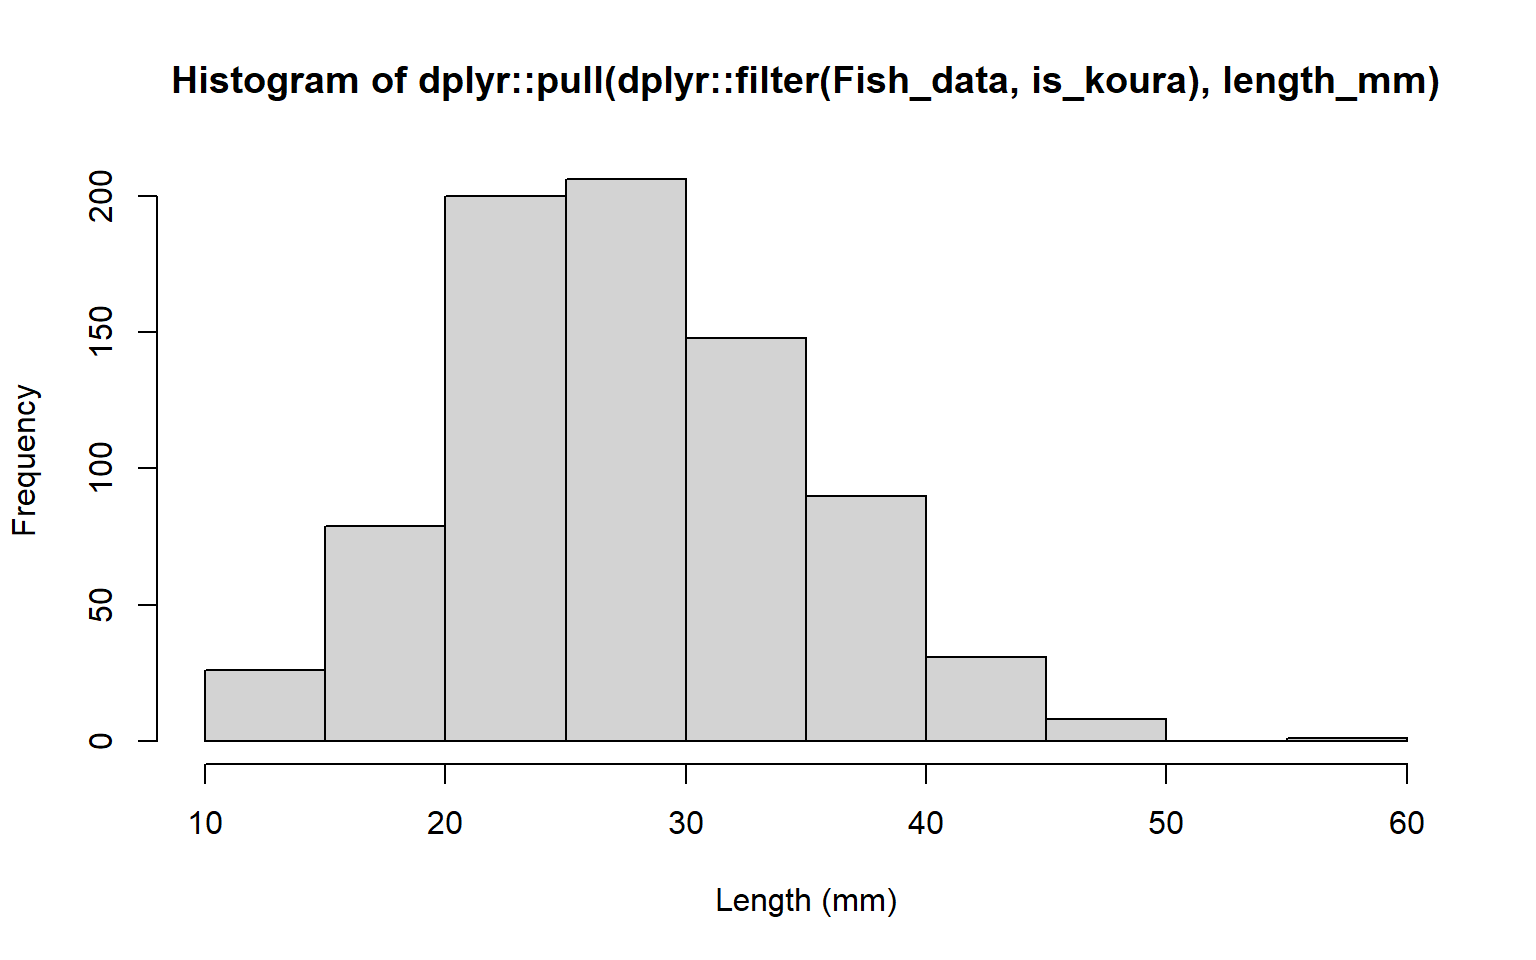

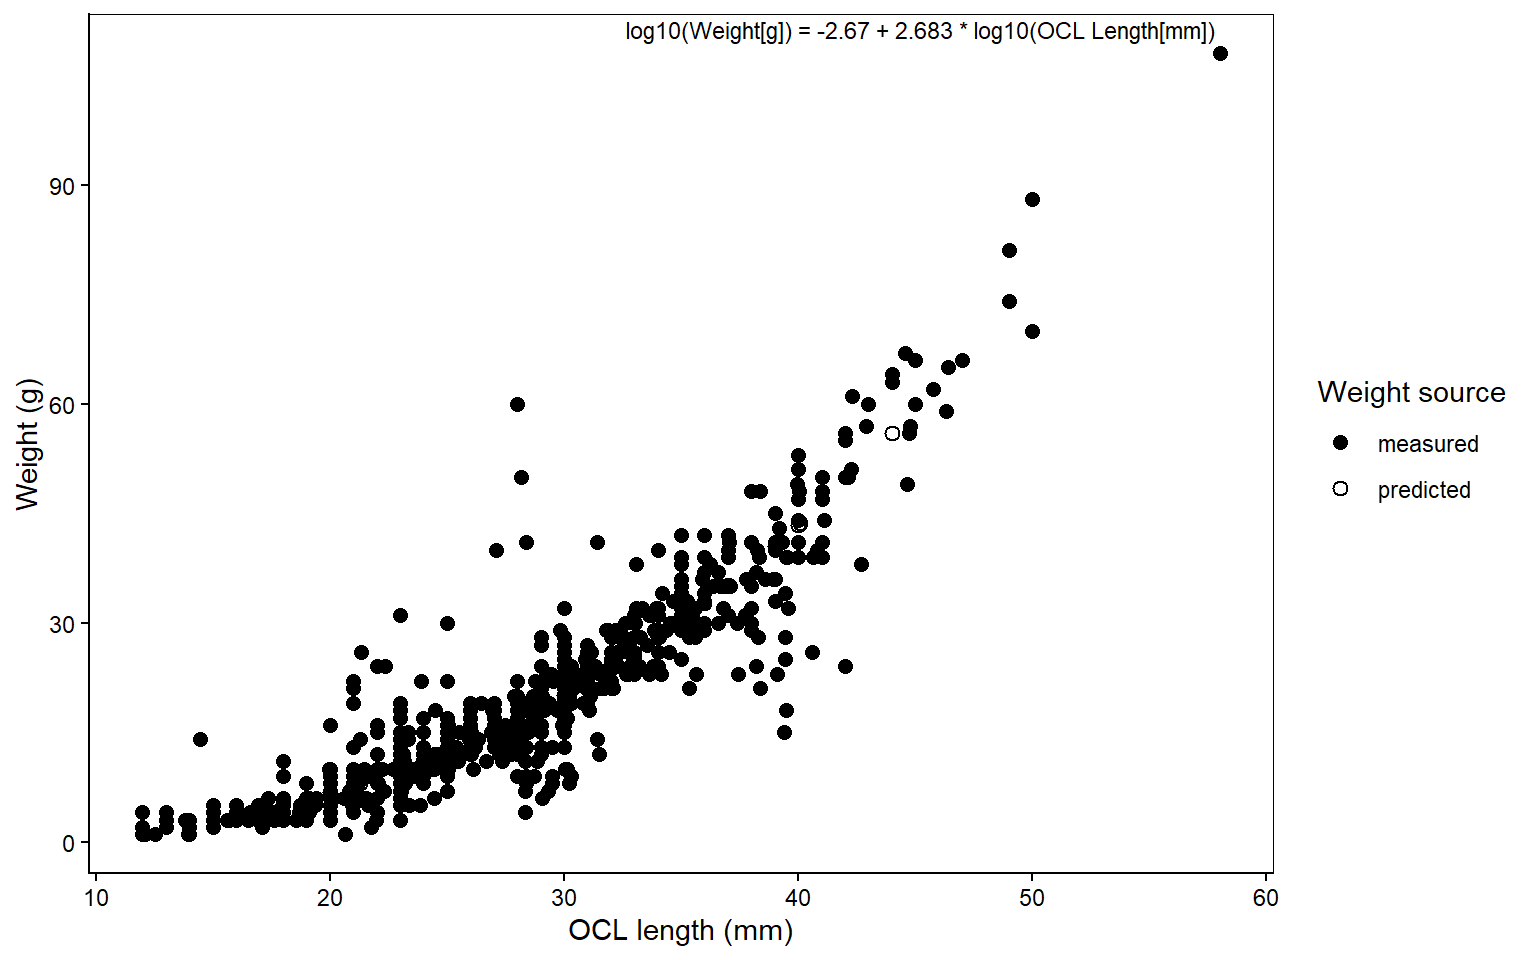

In [ ]:

# use size of koura to fill missing weights.
lw_model <- lm(log10(weight_g) ~ log10(length_mm), data = Fish_data, subset = species_name == "Freshwater_crayfish", na.action = na.exclude)

# extract the residual variance
sigma_log10 <- sigma(lw_model)
c <- 10^(0.5 * sigma_log10^2)

Fish_data <- Fish_data |>
  mutate(is_koura = species_name == "Freshwater_crayfish",
    Predicted_weight = case_when( !is.na(weight_g) ~ weight_g,
      is_koura ~ {pred_log <- predict(lw_model, newdata = pick(everything()))
        10^(pred_log) * c}, TRUE ~ NA_real_ ),
    Weight_source = case_when(is_koura & !is.na(weight_g) ~ "measured",
      is_koura & is.na(weight_g) ~ "predicted",TRUE ~ NA_character_))

count_df <- Fish_data |>
  dplyr::filter(is_koura, !is.na(Weight_source)) |>
  dplyr::count(Weight_source, name = "n")

measured_n  <- count_df$n[count_df$Weight_source == "measured"]
predicted_n <- count_df$n[count_df$Weight_source == "predicted"]

total_koura <- Fish_data |>
  dplyr::filter(is_koura) |>
  nrow()

hist(Fish_data |> dplyr::filter(is_koura) |> dplyr::pull(length_mm), xlab = "Length (mm)")

# Extract model coefficients
a <- coef(lw_model)[1]
b <- coef(lw_model)[2]

# Create formula text for the plot
formula_text <- paste0( "log10(Weight[g]) = ", round(a, 3), " + ", round(b, 3), " * log10(OCL Length[mm])")

# Plot with formula added
length_weight_plot <- ggplot(
Fish_data |> dplyr::filter(is_koura),
aes(x = length_mm, y = Predicted_weight, shape = Weight_source)) +
geom_point(size = 2.2, colour = "black", stroke = 0.6) +
scale_shape_manual(values = c("measured" = 16, "predicted" = 1)) +
labs(x = "OCL length (mm)", y = "Weight (g)", shape = "Weight source") +
annotate("text", x = Inf, y = Inf, label = formula_text, hjust = 1.1, vjust = 1.3, size = 3) 

ggsave(file.path(out_dir, "fig-length-weight.png"),length_weight_plot,width = 8, height = 5, dpi = 300)


## Build CPUE and BPUE

In [ ]:

CPUE_BPUE_legacy <- Fish_data %>%
  filter(!is.na(species)) %>%
  group_by(monitoring_id, species, net_type) %>%
  dplyr::reframe(
    Total_Individuals = sum(amount, na.rm = TRUE),
    Total_Weight      = sum(weight_g, na.rm = TRUE),
    Total_Effort      = dplyr::first(amount_nets),
    CPUE              = Total_Individuals / Total_Effort,
    BPUE              = Total_Weight      / Total_Effort,
    Mean_Length       = mean(length_mm, na.rm = TRUE),
    Min_Length        = ifelse(all(is.na(length_mm)), NA, min(length_mm, na.rm = TRUE)),
    Max_Length        = ifelse(all(is.na(length_mm)), NA, max(length_mm, na.rm = TRUE)),
    Mean_Weight       = mean(weight_g, na.rm = TRUE),
    Min_Weight        = ifelse(all(is.na(weight_g)), NA, min(weight_g, na.rm = TRUE)),
    Max_Weight        = ifelse(all(is.na(weight_g)), NA, max(weight_g, na.rm = TRUE))
  )

CPUE_BPUE_weighted <- CPUE_BPUE_legacy %>%
  group_by(monitoring_id, species) %>%
  summarise(
    Total_Individuals       = sum(Total_Individuals, na.rm = TRUE),
    Total_Weight            = sum(Total_Weight,      na.rm = TRUE),
    Weighted_CPUE_numerator = sum(CPUE * Total_Effort,  na.rm = TRUE),
    Weighted_BPUE_numerator = sum(BPUE * Total_Effort,  na.rm = TRUE),
    Total_Effort_sum        = sum(Total_Effort,         na.rm = TRUE),
    Mean_Length             = mean(Mean_Length, na.rm = TRUE),
    Min_Length              = ifelse(all(is.na(Min_Length)), NA, min(Min_Length, na.rm = TRUE)),
    Max_Length              = ifelse(all(is.na(Max_Length)), NA, max(Max_Length, na.rm = TRUE)),
    Mean_Weight             = mean(Mean_Weight, na.rm = TRUE),
    Min_Weight              = ifelse(all(is.na(Min_Weight)), NA, min(Min_Weight, na.rm = TRUE)),
    Max_Weight              = ifelse(all(is.na(Max_Weight)), NA, max(Max_Weight, na.rm = TRUE)),
    .groups = "drop") %>%
  ungroup() %>%
  mutate(Total_Effort_sum = ifelse(monitoring_id %in% c("16_0", "10_1", "3_2", "16_2"), 3, 4),
    Weighted_CPUE    = Weighted_CPUE_numerator / Total_Effort_sum,
    Weighted_BPUE    = Weighted_BPUE_numerator / Total_Effort_sum)

species_presence_absence <- Fish_data %>%
  filter(!is.na(species)) %>%
  distinct(monitoring_id, species) %>%
  mutate(presence = 1) %>%
  pivot_wider(
    names_from  = species,
    values_from = presence,
    values_fill = list(presence = 0),
    names_prefix = "Presence_") %>%
  mutate(Predator_Fish_Presence = pmax(Presence_Trout, Presence_Eel, Presence_Catfish))

CPUE_BPUE_weighted_summary <- CPUE_BPUE_weighted %>%
  pivot_wider(
    names_from  = species,
    values_from = c(
      Total_Individuals, Weighted_CPUE, Weighted_BPUE, Total_Weight,
      Mean_Length, Mean_Weight, Weighted_CPUE_numerator, Weighted_BPUE_numerator,
      Total_Effort_sum, Min_Length, Max_Length, Min_Weight, Max_Weight),
    names_sep   = "_", values_fill = list(Total_Individuals = 0, Weighted_CPUE = 0, Weighted_BPUE = 0)) %>%
  mutate(
    Richness  = rowSums(dplyr::select(., starts_with("Total_Individuals_")) > 0),
    Abundance = rowSums(dplyr::select(., starts_with("Total_Individuals_") & !ends_with(c("_Bullies", "_Common_smelt")))))


## Combined dataset construction

In [ ]:

unit_metadata <- dplyr::bind_rows(Monitoring_data %>%
    dplyr::select(parameter, unit), Chemical_data %>%
    dplyr::select(parameter, unit)) %>%
  dplyr::distinct() %>%
  dplyr::rename(Variable = parameter, Unit = unit)

Monitoring_summary <- Monitoring_data %>%
  dplyr::select(-group, -notes, -unit, -monitoring_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Riparian_vegetation, Vegetation_nearby, Overhanging_trees, Erosion, Structure, Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter, Wood_cover ), ~ as.numeric(.)))

Chemical_summary <- Chemical_data %>%
  dplyr::select(-group, -notes, -unit, -site_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), ~ as.numeric(.)))

Weed_summary <- Weed_data %>%
  group_by(monitoring_id, weed_type, native_status) %>%
  summarise(Total_Cover = sum(percentage_cover, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from  = c(weed_type, native_status), values_from = Total_Cover, values_fill = 0) %>% 
  dplyr::select(monitoring_id, Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Turf_Native)

Stone_pile_summary <- Stone_pile_data %>%
  select(-unit, -notes, -site_id)%>%
  pivot_wider(names_from = c(parameter, stone_pile_id), values_from = value, names_sep = ".")

Macroinvertebrates_sum <- Macroinvertebrates %>%
  group_by(monitoring_id, species) %>%
  summarise(Total_amount = sum(amount, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = c(species), values_from = Total_amount, values_fill = 0) %>%
  mutate(Invertebrates_Richness  = rowSums(dplyr::select(., -monitoring_id) > 0),
    Invertebrates_Abundance = rowSums(dplyr::select(., -monitoring_id)))

Combined_data <- Site_info %>%
  left_join(Monitoring_summary, by = "site_id") %>%
  left_join(Chemical_summary, by = c("monitoring_id")) %>%
  left_join(Weed_summary, by = c("monitoring_id")) %>%
  left_join(Stone_pile_summary, by = c("monitoring_id")) %>%
  left_join(CPUE_BPUE_weighted_summary, by = "monitoring_id") %>%
  left_join(species_presence_absence, by = "monitoring_id") %>%
  left_join(Macroinvertebrates_sum, by = "monitoring_id")


## Derived variables

In [ ]:

Combined_data <- Combined_data %>%
  dplyr::mutate(date_time = as.POSIXct(date_time, tz = "Pacific/Auckland"),
    Presence_rocks = dplyr::if_else(Cobble > 1 | Boulders > 1, 1, 0),
    Period = factor(dplyr::if_else(monitoring == 0, "Before", "After"),levels = c("Before", "After")),
    Date  = as.Date(date_time),
    Time  = format(date_time, "%H:%M:%S"),
    Year  = lubridate::year(date_time),
    Month = lubridate::month(date_time, label = TRUE),
    Day   = lubridate::day(date_time),
    Season = dplyr::case_when(
      Month %in% c("Dec", "Jan", "Feb") ~ "Summer",
      Month %in% c("Mar", "Apr", "May") ~ "Autumn",
      Month %in% c("Jun", "Jul", "Aug") ~ "Winter",
      Month %in% c("Sep", "Oct", "Nov") ~ "Spring",
      TRUE ~ NA_character_),
    Date_Time_Numeric = as.numeric(date_time),
    Monitoring_label = dplyr::case_when(
      monitoring == 0 ~ "0 Pre/Summer",
      monitoring == 1 ~ "1 Autumn",
      monitoring == 2 ~ "2 Winter",
      monitoring == 3 ~ "3 Spring",
      monitoring == 4 ~ "4 Summer",
      monitoring == 5 ~ "5 Autumn",
      monitoring == 6 ~ "6 Winter",
      TRUE ~ as.character(monitoring)
    ) %>% as.factor(), site_id = as.factor(site_id)) %>%
  dplyr::mutate(
  Depth_5m    = suppressWarnings(as.numeric(Distance_5m)),
  Depth_20m   = suppressWarnings(as.numeric(Distance_20m)),
  Slope_0_5m  = 5  / Depth_5m,    # 5m rise / horizontal distance in m
  Slope_0_20m = 20 / Depth_20m)   # 20m rise / horizontal distance in m
        

habitat_classification <- Combined_data %>%
  filter(monitoring == 0) %>%
  dplyr::select(site_id, DHT, lake,
                Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover) %>%
  pivot_longer(cols = c(Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                  Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover),
    names_to  = "Type", values_to = "Percentage") %>%
  group_by(site_id) %>%
  summarise(Rocky_Percentage  = sum(Percentage[Type %in% c("Bedrock", "Boulders", "Cobble")], na.rm = TRUE),
    Sand_Percentage     = sum(Percentage[Type == "Sand"], na.rm = TRUE),
    Mud_Percentage      = sum(Percentage[Type %in% c("Mud", "Organic_matter")], na.rm = TRUE),
    Emergent_Percentage = sum(Percentage[Type %in% c("Emergent_Native")], na.rm = TRUE),
    Substrate_index_before = sum(
      0.08 * Percentage[Type == "Bedrock"] +
      0.07 * Percentage[Type == "Boulders"] +
      0.06 * Percentage[Type == "Cobble"] +
      0.04 * Percentage[Type == "Gravel"] +
      0.03 * Percentage[Type == "Sand"] +
      0.02 * Percentage[Type == "Organic_matter"] +
      0.01 * Percentage[Type == "Mud"],
      na.rm = TRUE),.groups = "drop") %>%
  mutate(Habitat_Type = case_when(
      Rocky_Percentage    > 25 ~ "Rocky",
      Emergent_Percentage > 25 ~ "Emergent Macrophyte",
      Sand_Percentage   >= Mud_Percentage ~ "Sandy",
      TRUE ~ "Muddy")) %>%
  dplyr::select(site_id, Habitat_Type, Substrate_index_before)

Combined_data <- Combined_data %>%
  left_join(habitat_classification, by = c("site_id"))%>%
  dplyr::mutate(monitoring_int = as.integer(monitoring),
    pair_id = factor(ceiling(as.numeric(as.character(site_id)) / 2)),
    koura_present = as.integer(`Total_Individuals_Kōura` > 0))

# Substrate_index_before above is fixed at the baseline (pre-construction) substrate
# survey and never updated, even though the stone piles physically added new
# rocky structure at Stone_pile sites. Rather than assume a flat added-cover
# percentage for every site, use each site's own measured pile footprint:
# total footprint area of the ~3 piles at that site, as a percentage of the
# 10 m x 15 m (150 m^2) site survey area, classified 80% Cobble / 20%
# Boulders (most stones were below boulder size) and displacing an equal
# area of Sand (the pre-existing substrate at all 5 stone-pile sites).
# Substrate_index_after equals the original Substrate_index_before
# everywhere except Stone_pile sites at monitoring_int >= 1 (post-
# construction), where it reflects this site-specific addition.
site_area_m2 <- 10 * 15

pile_footprint_pct <- Stone_pile_data %>%
  dplyr::filter(stringr::str_detect(monitoring_id, "_0"), parameter == "Area") %>%
  dplyr::mutate(value_num = suppressWarnings(as.numeric(value)),
                site_id   = as.character(site_id)) %>%
  dplyr::group_by(site_id) %>%
  dplyr::summarise(footprint_pct = sum(value_num, na.rm = TRUE) / site_area_m2 * 100, .groups = "drop")

substrate_updated <- Combined_data %>%
  dplyr::filter(monitoring_int == 0) %>%
  dplyr::distinct(site_id, Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter) %>%
  dplyr::mutate(site_id = as.character(site_id)) %>%
  dplyr::left_join(pile_footprint_pct, by = "site_id") %>%
  tidyr::replace_na(list(footprint_pct = 0)) %>%
  dplyr::mutate(
    Boulders_new = Boulders + footprint_pct * 0.20,
    Cobble_new   = Cobble   + footprint_pct * 0.80,
    Sand_new     = Sand     - footprint_pct,
    Substrate_index_after = 0.08 * Bedrock + 0.07 * Boulders_new + 0.06 * Cobble_new +
      0.04 * Gravel + 0.03 * Sand_new + 0.02 * Organic_matter + 0.01 * Mud) %>%
  dplyr::select(site_id, Substrate_index_after)

Combined_data <- Combined_data %>%
  dplyr::mutate(site_id = as.character(site_id)) %>%
  dplyr::left_join(substrate_updated, by = "site_id") %>%
  dplyr::mutate(
    # as.factor() alone would sort "1","10","11",...,"2","20",...
    # alphabetically — sort numerically first so site_id reads 1-20.
    site_id = factor(site_id, levels = as.character(sort(as.numeric(unique(site_id))))),
    Substrate_index_after = dplyr::if_else(
      site == "Stone_pile" & monitoring_int >= 1,
      Substrate_index_after,
      Substrate_index_before))

Combined_data <- Combined_data %>%
  mutate(lunar_phase = lunar.phase(Date, name = FALSE),  # 0-2π radians
    lunar_illumination = (1 - cos(lunar.phase(Date))) / 2,  # 0=new, 1=full
    lunar_name = lunar.phase(Date, name = TRUE))     # "New", "Waxing", "Full", "Waning"

# Monitoring quality flag — based on known compromised events
compromised_ids <- c("6_1", "13_1", "14_1", "1_2", "2_2", "19_2", "20_2", "1_3", "2_3", "6_5")

Combined_data <- Combined_data %>%
  mutate(monitoring_quality = case_when(monitoring_id %in% compromised_ids ~ "compromised", is.na(`Total_Individuals_Kōura`) ~ "missing", TRUE  ~ "complete"))

writexl::write_xlsx(Combined_data, file.path(der_data_dir, "Combined_data.xlsx"))
write.csv(Combined_data, file.path(der_data_dir, "Combined_data.csv"), row.names = FALSE)
write.csv(habitat_classification, file.path(der_data_dir, "habitat_classification.csv"), row.names = FALSE)

all_data <- Combined_data


## Missing data summary

``` r

# Missing data summary
missing_table <- all_data %>%
  filter(monitoring_quality != "complete") %>%
  select(site_id, site, Monitoring_label, monitoring_id, monitoring_quality) %>%
  arrange(site_id, Monitoring_label)

missing_table
```

       site_id       site Monitoring_label monitoring_id monitoring_quality
    1        1 Stone_pile         2 Winter           1_2        compromised
    2        1 Stone_pile         3 Spring           1_3        compromised
    3        2    Control         2 Winter           2_2        compromised
    4        2    Control         3 Spring           2_3        compromised
    5        6    Control         1 Autumn           6_1        compromised
    6        6    Control         5 Autumn           6_5        compromised
    7       13  Reference         1 Autumn          13_1        compromised
    8       14  Reference         1 Autumn          14_1        compromised
    9       19  Reference         2 Winter          19_2        compromised
    10      20  Reference         2 Winter          20_2        compromised

# Site overview

## Site overview table

In [ ]:

# Site-level info from all_data — baseline monitoring only
site_info_summary <- all_data %>%
  filter(monitoring == 0) %>%
  distinct(site_id, site, lat, lon, DHT, 
           Habitat_Type, Substrate_index_before,
           Slope_0_20m) %>%
  mutate(site_id = as.factor(site_id))

# Stone pile summary — mean across 3 piles per modified site at baseline
stone_pile_site_summary <- Stone_pile_data %>%
  filter(str_detect(monitoring_id, "_0")) %>%
  filter(parameter %in% c("Weight", "Volume", "Height_above", 
                           "Distance_to_shore", "Depth_on_R", 
                           "Depth_on_L", "Depth_after", "Area")) %>%
  mutate(value_num = suppressWarnings(as.numeric(value))) %>%
  group_by(site_id, parameter) %>%
  summarise(
    value_num = mean(value_num, na.rm = TRUE),
    n_piles   = n_distinct(stone_pile_id),
    .groups   = "drop") %>%
  pivot_wider(names_from = parameter, values_from = value_num) %>%
  mutate(
    # Cast to character (not factor) so the join below inherits
    # site_info_summary's (already correctly numeric-ordered) factor
    # instead of re-sorting this subset alphabetically on its own —
    # left_join() coerces factor-vs-character but errors on factor-vs-integer.
    site_id          = as.character(site_id),
    Depth_m          = round((Depth_on_R + Depth_on_L) / 2 / 1000, 2),
    Depth_after_m    = round(Depth_after       / 1000, 2),
    Height_above_m   = round(Height_above       / 1000, 2),
    Distance_shore_m = round(Distance_to_shore / 1000, 2),
    Area_m2          = round(Area,   2),
    Weight_kg        = round(Weight, 0),
    Volume_m3        = round(Volume, 2)) %>%
  select(site_id, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3)

# Join and finalise
site_data <- site_info_summary %>%
  left_join(stone_pile_site_summary, by = "site_id") %>%
  arrange(as.numeric(as.character(site_id))) %>%
  mutate(across(where(is.numeric), ~ round(.x, 2))) %>%
  select(site_id, site, DHT, Substrate_index_before, Slope_0_20m, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3)

# Display table drops the stone-pile build dimensions (Distance_shore_m,
# Depth_m, Height_above_m, Area_m2, Volume_m3) — they only exist for
# Stone_pile sites, so they don't fit a per-site comparison table. site_data
# itself keeps them, since stone_pile_data2/mean_dist_shore/mean_depth/
# mean_area below still depend on them.
site_overview_display <- site_data %>%
  dplyr::select(site_id, site, DHT, Substrate_index_before, Slope_0_20m)

write.csv(site_overview_display, file = file.path(out_dir, "tbl-site-overview.csv"), row.names = FALSE)

knitr::kable(site_overview_display, digits = 2)


  site_id   site         DHT       Substrate_index_before   Slope_0_20m
  --------- ------------ ------- ------------------------ -------------
  1         Stone_pile   Rocky                       5.20          0.12
  2         Control      Rocky                       4.40          0.11
  3         Stone_pile   Sandy                       3.00          0.01
  4         Control      Sandy                       3.00          0.01
  5         Stone_pile   Sandy                       2.40          0.01
  6         Control      Sandy                       3.00          0.01
  7         Stone_pile   Sandy                       3.00          0.06
  8         Control      Sandy                       3.00          0.05
  9         Stone_pile   Sandy                       3.35          0.08
  10        Control      Rocky                       5.00          0.09
  11        Reference    Rocky                       6.60          0.16
  12        Reference    Rocky                       6.20          0.12
  13        Reference    Sandy                       3.60          0.09
  14        Reference    Sandy                       3.50          0.11
  15        Reference    Rocky                       5.20          0.03
  16        Reference    Rocky                       5.20          0.04
  17        Reference    Rocky                       5.00          0.05
  18        Reference    Rocky                       6.20          0.05
  19        Reference    Rocky                       5.70          0.11
  20        Reference    Rocky                       5.70          0.13


# Descriptive results

## Descriptive context plots

Background/methods-supporting plots — combined into a single figure below rather than shown individually, since none are primary results.

### Habitat characteristics

In [ ]:

Habitat_data <- all_data %>%
  dplyr::select(site_id, site, monitoring_int, Habitat_Type,Slope_0_5m, Slope_0_20m, Substrate_index_before, Substrate_index_after, Riparian_vegetation, Overhanging_trees, Wood_cover) %>%
  tidyr::pivot_longer(cols = c(Slope_0_5m, Slope_0_20m, Substrate_index_before, Substrate_index_after, Riparian_vegetation, Overhanging_trees, Wood_cover), names_to  = "Variable", values_to = "Value") %>%
  dplyr::group_by(site_id, site, Variable) %>%
  # Most of these are static baseline-only measurements (constant across all
  # rounds), so first/last makes no difference. Substrate_index_after is
  # the exception — it only changes from round 1 onward for Stone_pile sites
  # — so take the latest round to show the current (post-construction) state
  # rather than the frozen baseline.
  dplyr::slice_max(monitoring_int, n = 1, with_ties = FALSE) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

# Mean ± SE by site type rather than one bar per site_id — individual-site
# detail is already in the site overview table; at combined-figure scale,
# 20 site labels per facet aren't legible and aren't the point here.
Habitat_summary <- Habitat_data %>%
  dplyr::group_by(site, Variable) %>%
  dplyr::summarise(
    mean_v = mean(Value, na.rm = TRUE),
    se     = sd(Value, na.rm = TRUE) / sqrt(sum(!is.na(Value))),
    .groups = "drop")

habitat_var_labels <- c(
  Slope_0_5m             = "Slope (0-5m)",
  Slope_0_20m            = "Slope (0-20m)",
  Substrate_index_before = "Substrate index\n(before)",
  Substrate_index_after  = "Substrate index\n(after)",
  Riparian_vegetation    = "Riparian\nvegetation",
  Overhanging_trees      = "Overhanging\ntrees",
  Wood_cover             = "Wood cover")

Habitat_plot <- ggplot(Habitat_summary, aes(site, mean_v, fill = site)) +
  geom_col(colour = "black") +
  geom_errorbar(aes(ymin = mean_v - se, ymax = mean_v + se), width = 0.25) +
  facet_wrap(~ Variable, scales = "free_y", nrow = 2, labeller = as_labeller(habitat_var_labels)) +
  scale_fill_manual(values = site_fill, labels = site_labels) +
  labs(y = "Mean value (± SE)", x = NULL) +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), legend.position = "none")

ggsave(file.path(out_dir, "fig-habitat-plot.png"), Habitat_plot, width = 10, height = 6, dpi = 300)


### Stone pile structure

In [ ]:

stone_pile_data2 <- site_data %>%
  dplyr::select(site_id, site, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3) %>%
  tidyr::pivot_longer(
    cols      = c(Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3),
    names_to  = "Parameter",
    values_to = "Value") %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

parameter_labels <- c(
  Distance_shore_m = "Distance to shore (m)",
  Depth_m          = "Depth (m)",
  Height_above_m   = "Height above lakebed (m)",
  Area_m2          = "Area (m²)",
  Volume_m3        = "Volume (m³)")

# Only Stone_pile sites have real values here (Control/Reference are NA
# from the left_join in site_data) — filter the NAs out before plotting so
# the unused factor levels actually drop, instead of leaving 15 empty tick
# positions squeezed in next to the 5 real bars. No fill/legend needed
# either, since every remaining bar is the same site type.
stone_pile_structure_plot <- stone_pile_data2 %>%
  dplyr::filter(!is.na(Value)) %>%
  ggplot(aes(site_id, Value)) +
  geom_col(colour = "black", fill = site_fill[["Stone_pile"]]) +
  facet_wrap(~ Parameter, scales = "free_y", nrow = 2, labeller = as_labeller(parameter_labels)) +
  labs(y = "Value", x = "Stone pile site")

ggsave(file.path(out_dir, "fig-stone-pile-structure.png"), stone_pile_structure_plot, width = 8, height = 6, dpi = 300)



# Overall means across sites, used inline in the Methods text
mean_dist_shore <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Distance_shore_m"], na.rm = TRUE)
mean_depth      <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Depth_m"], na.rm = TRUE)
mean_area       <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Area_m2"], na.rm = TRUE)


### Chemical conditions over time

In [ ]:

Chemical_data2 <- all_data %>%
  dplyr::select(monitoring_id, monitoring_int, site_id, site, Monitoring_label, Habitat_Type, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH, Temperature) %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference"))) %>%
  tidyr::pivot_longer(cols = c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), names_to = "Variable", values_to = "Values")

chemical_var_labels <- c(
  Temperature           = "Temperature (°C)",
  DO_mgl                = "Dissolved oxygen\n(mg/L)",
  DO_percent            = "Dissolved oxygen\n(%)",
  Conductivity          = "Conductivity\n(µS/cm)",
  Specific_conductivity = "Specific conductivity\n(µS/cm)",
  pH                    = "pH")

# Coloured by site type (not individual site_id) for consistency with every
# other panel — a 20-line/colour legend was competing with the data itself.
# x-axis uses monitoring_int + monitor_labels, same as the species-trends
# panel, so both panels read the same round labels.
Chemical_plot <- ggplot(Chemical_data2, aes(monitoring_int, Values, colour = site)) +
  geom_point(alpha = 0.5, position = position_jitter(width = 0.1)) +
  geom_smooth(aes(group = site), se = FALSE) +
  facet_wrap(~ Variable, scales = "free", nrow = 2, labeller = as_labeller(chemical_var_labels)) +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels) +
  labs(y = "Value", x = "Monitoring", colour = "Site type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")

ggsave(file.path(out_dir, "fig-chemical-plot.png"), Chemical_plot, width = 8, height = 6,  dpi = 300)


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

### All species trends

In [ ]:

# Species to plot and their display names
species_vec_trends <- c("Catfish", "Kōaro", "Goldfish")

species_labels <- c("Kōura" = "Kōura", "Catfish" = "Catfish", "Kōaro" = "Kōaro", "Goldfish" = "Goldfish")

# Function to build one trend plot per species
make_trend_plot <- function(sp) {

  col_name <- paste0("Weighted_CPUE_", sp)
  if (!col_name %in% names(all_data)) return(NULL)

  summary_df <- all_data %>%
    group_by(monitoring_int, site) %>%
    summarise(
      mean_n = mean(.data[[col_name]], na.rm = TRUE),
      se     = sd(.data[[col_name]], na.rm = TRUE) /
               sqrt(sum(!is.na(.data[[col_name]]))),
      n      = sum(!is.na(.data[[col_name]])),
      ci95   = qt(0.975, df = pmax(n - 1, 1)) * se,
      .groups = "drop") %>%
    mutate(
      site   = factor(site, levels = c("Stone_pile", "Control", "Reference")),
      ci_low  = pmax(mean_n - ci95, 0),
      ci_high = mean_n + ci95)

  ggplot(summary_df,
      aes(monitoring_int, mean_n, colour = site, shape = site, fill = site)) +
    geom_errorbar(aes(ymin = ci_low, ymax = ci_high), position = position_dodge(width = 0.4), width = 0.25, linewidth = 0.4, colour = "grey40") +
    geom_line(aes(group = site), position = position_dodge(width = 0.4), linewidth = 0.6) +
    geom_point(colour = "black", size = 2.5, stroke = 0.4, position = position_dodge(width = 0.4)) +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(values = site_fill, labels = site_labels) +
    scale_shape_manual(values = site_shapes, labels = site_labels) +
    scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
    labs(title  = species_labels[[sp]], x = NULL, y = "Mean CPUE (± 95% CI)", colour = "Site type", shape = "Site type", fill = "Site type") +
    theme(axis.text.x     = element_text(size = 7,
        colour = c(rep("black", 6), "grey50")),
      axis.text.y     = element_text(size = 8),
      axis.title.y    = element_text(size = 9),
      plot.title      = element_text(size = 10, face = "bold"),
      legend.position = "none")   # collect legend from patchwork
}

# Generate all plots, drop NULLs
trend_plots <- purrr::map(species_vec_trends, make_trend_plot) %>%
  purrr::set_names(species_vec_trends) %>%
  purrr::compact()


ℹ Results may be unexpected or may change in future versions of ggplot2.
Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.
Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.

### Combined figure

In [ ]:

# Left column stacks the 3 site-characteristic panels; right column is the
# species-trends panel (already a 3-row stack of its own), so both sides
# end up with matching internal proportions instead of a forced 2x2 grid
# that would otherwise squash the taller species-trends panel.
left_column <- Habitat_plot / stone_pile_structure_plot / Chemical_plot

descriptive_context_plot <- (left_column | combined_trends) +
  patchwork::plot_layout(widths = c(1.3, 1)) +
  patchwork::plot_annotation(tag_levels = "A")

ggsave(file.path(out_dir, "fig-descriptive-context.png"), descriptive_context_plot, width = 14, height = 12, dpi = 300)


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

### Kōura trend plot

ℹ Results may be unexpected or may change in future versions of ggplot2.

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

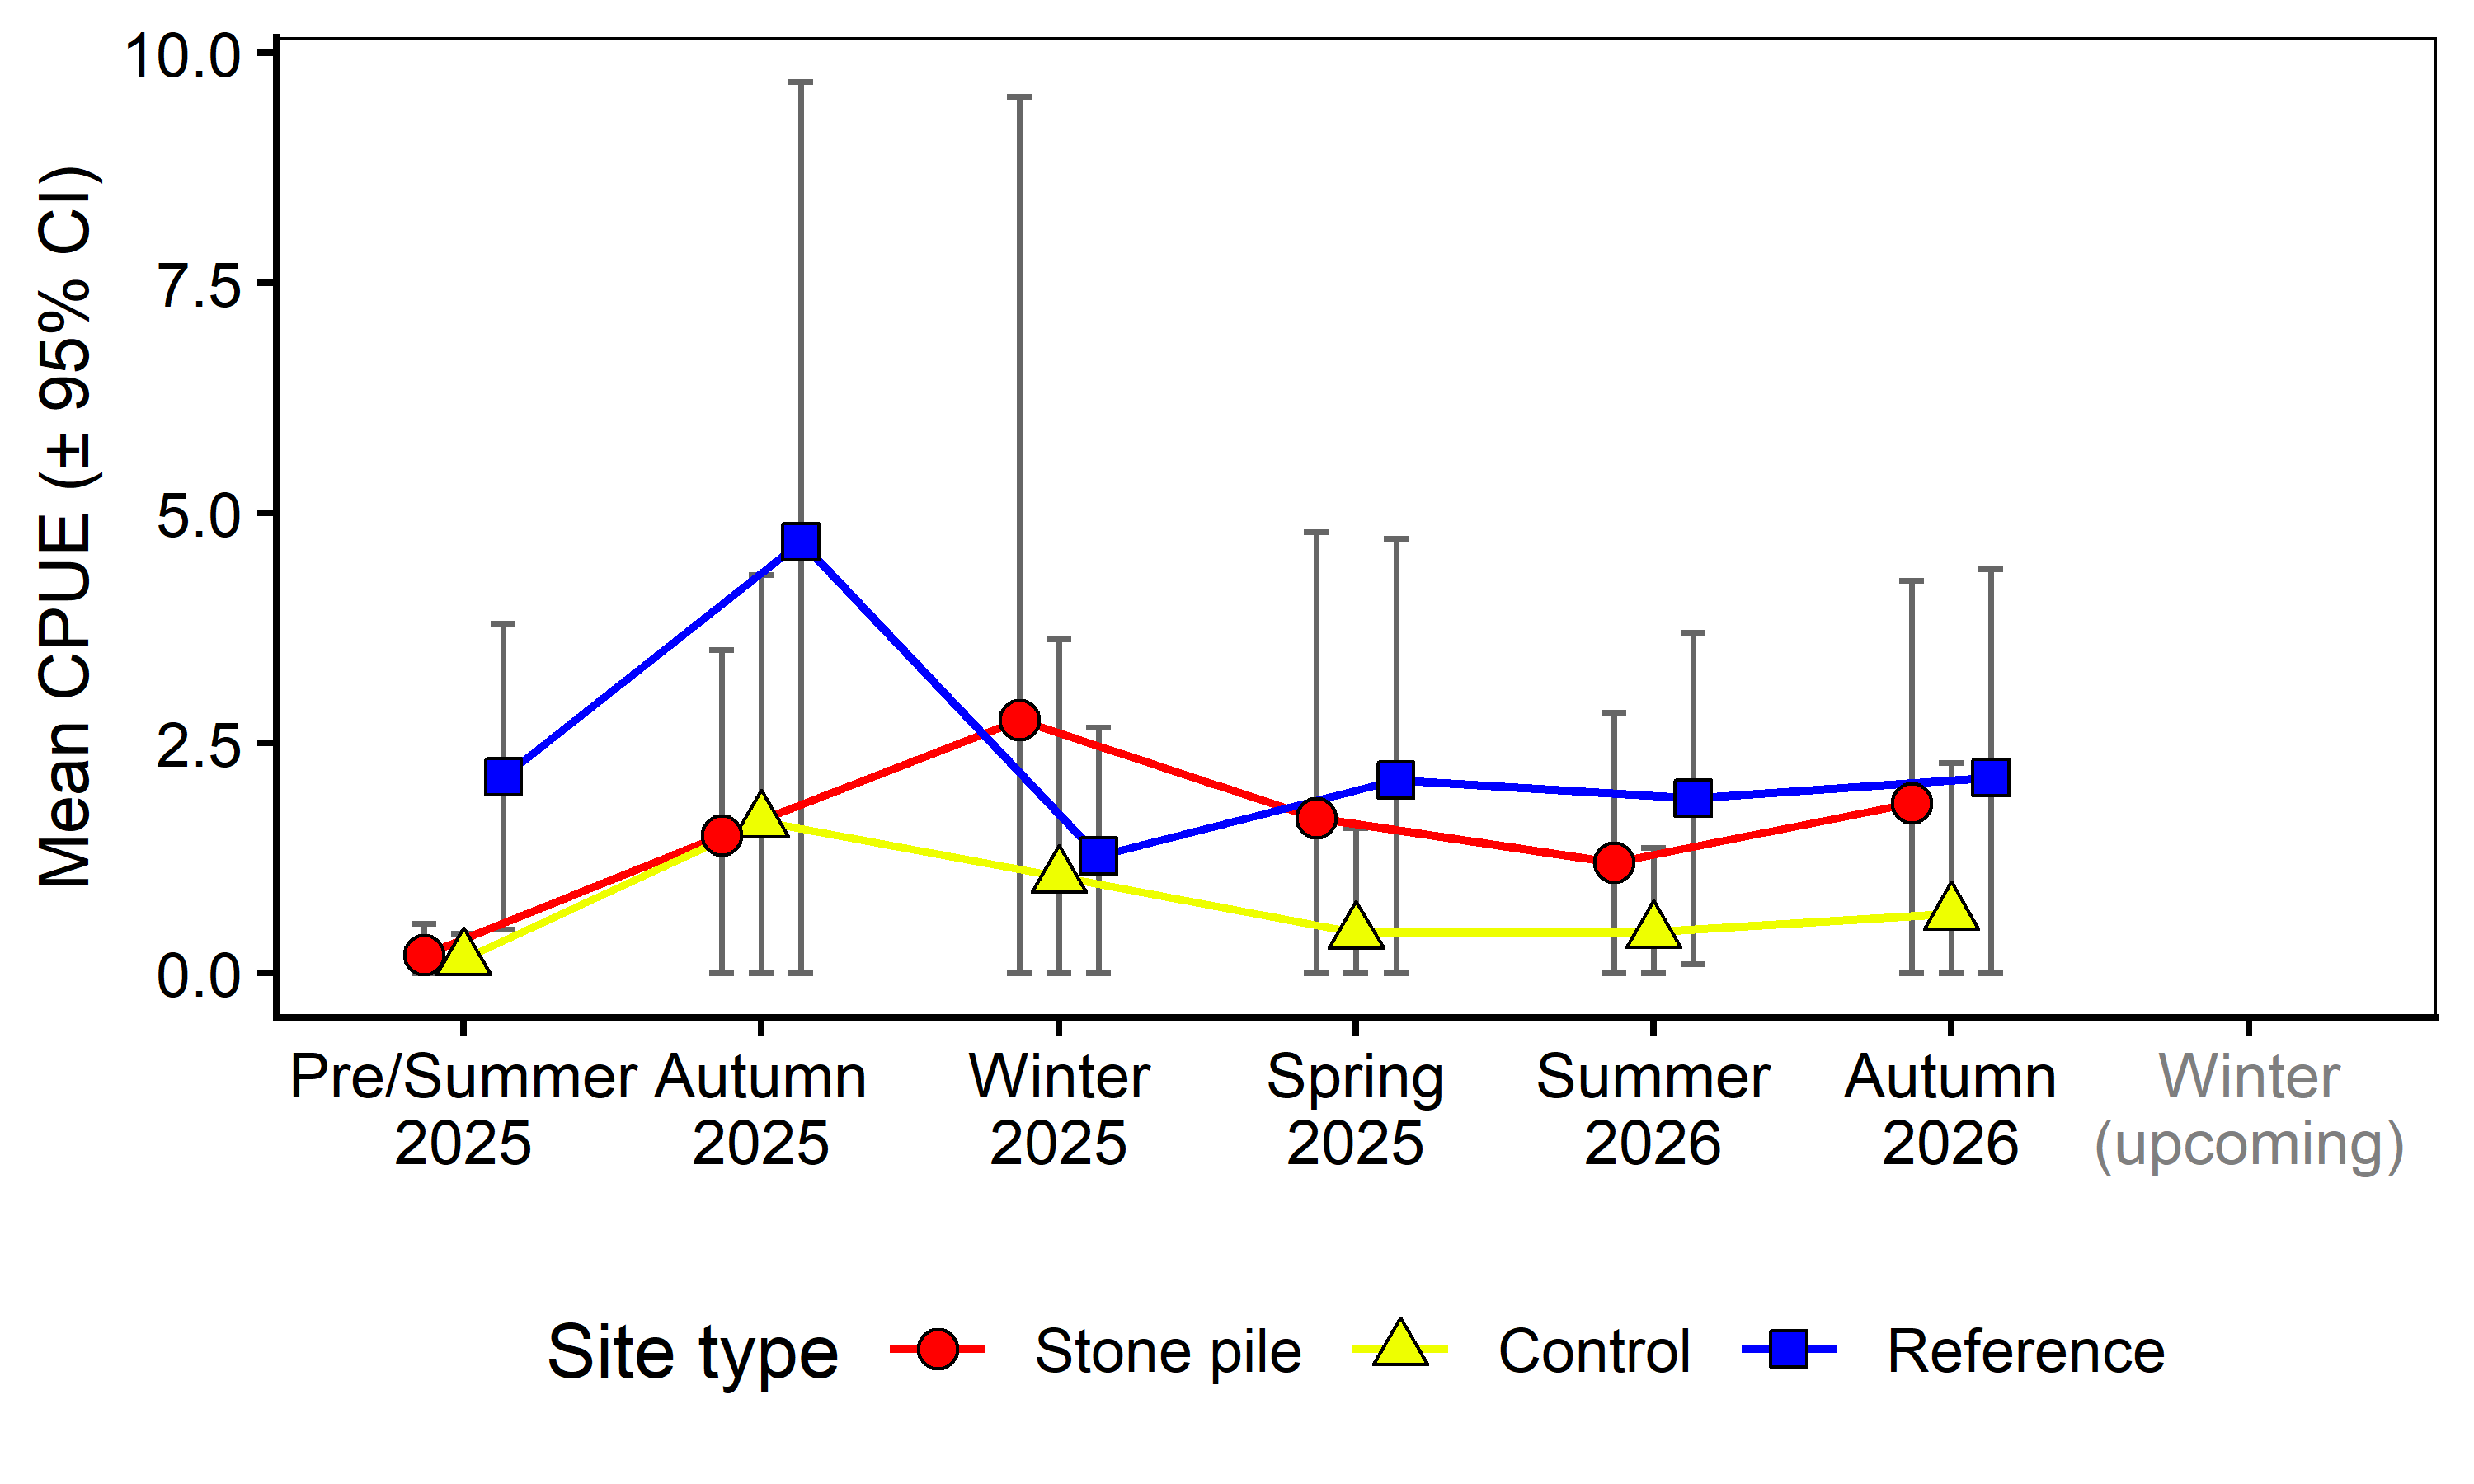

In [ ]:

# kōura trend plot — more detail than combined figure
koura_trend <- make_trend_plot("Kōura") +
  labs(title = NULL) +   # remove title since it's obvious
  theme(
    axis.text.x     = element_text(size = 9),
    axis.text.y     = element_text(size = 9),
    axis.title.y    = element_text(size = 10),
    legend.position = "bottom")


### Kōura CPUE plot per site

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

(`stat_smooth()`).

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at -0.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 9.1506

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at -0.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 9.1506

(`geom_point()`).

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

(`stat_smooth()`).

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at -0.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 3.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 4.1006

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at -0.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 3.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 4.1006

(`geom_point()`).

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

(`stat_smooth()`).

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at -0.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 9.1506

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at -0.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 9.1506

(`geom_point()`).

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

(`stat_smooth()`).

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at -0.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 3.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 4.1006

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: span too small.  fewer data values than degrees of freedom.

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at -0.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 3.025

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 4.1006

(`geom_point()`).

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

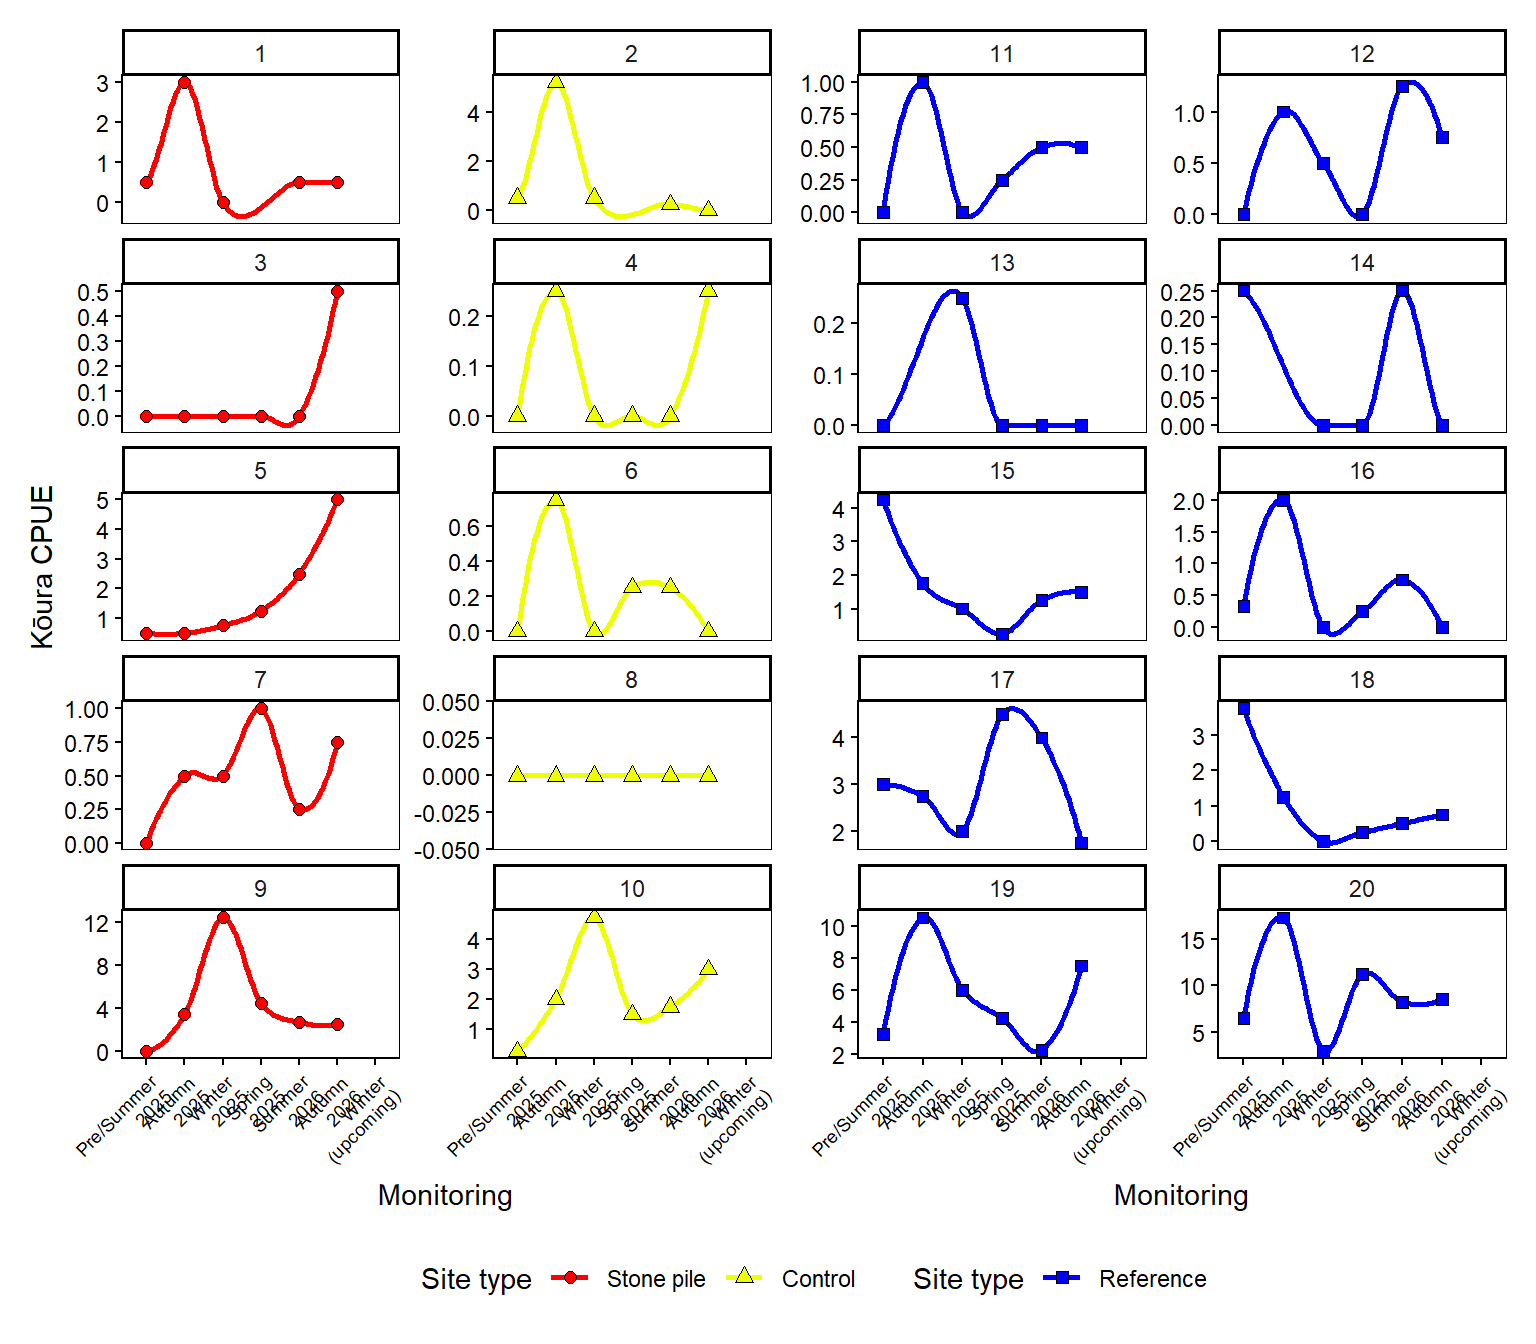

In [ ]:

koura_cpue_sites <- all_data %>%
  dplyr::filter(site != "Reference") %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference"))) %>%
  ggplot(aes(monitoring_int, `Weighted_CPUE_Kōura`,  shape = site, fill = site)) +
  geom_smooth(se = FALSE, aes(group = site, col = site)) +
  geom_point(size = 2, col = "black") +
  facet_wrap(~site_id, ncol = 2, scales = "free_y") +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_fill_manual(  values = site_fill,    labels = site_labels) +
  scale_shape_manual( values = site_shapes,  labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(y = "Kōura CPUE", x = "Monitoring",
       col = "Site type", shape = "Site type", fill = "Site type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7))

koura_cpue_reference <- all_data %>%
  dplyr::filter(site == "Reference") %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference"))) %>%
  ggplot(aes(monitoring_int, `Weighted_CPUE_Kōura`, shape = site, fill = site)) +
  geom_smooth(se = FALSE, aes(group = site, col = site)) +
  geom_point(size = 2, col = "black") +
  facet_wrap(~site_id, ncol = 2, scales = "free_y") +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_fill_manual(  values = site_fill,    labels = site_labels) +
  scale_shape_manual( values = site_shapes,  labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(y = "Kōura CPUE", x = "Monitoring",
       col = "Site type", shape = "Site type", fill = "Site type") +
  theme(axis.title.y = element_blank(),
        axis.text.x  = element_text(angle = 45, hjust = 1, size = 7))

koura_cpue_plot <- koura_cpue_sites + koura_cpue_reference + plot_layout(guides = "collect") & theme(legend.position = "bottom")

ggsave(file.path(out_dir, "fig-koura-cpue.png"),  koura_cpue_plot, width = 8, height = 7, dpi = 300)


## Combined environmental and fish summary table

In [ ]:

group_var <- "site_id" 
var_order_exact <- c("Substrate index","Riparian vegetation","Overhanging trees","Wood cover","Emergent vegetation","Submerged vegetation", "Temperature","Dissolved oxygen","Specific conductivity","pH","Presence Kōura", "Presence Catfish","Presence Eel","Presence Goldfish","Presence Common smelt", "Presence Kōaro","Presence Trout")

ci95 <- function(x) {
  x <- x[!is.na(x)]
  n <- length(x)
  if (n < 2) return(c(NA_real_, NA_real_))
  se <- stats::sd(x) / sqrt(n)
  tcrit <- stats::qt(0.975, df = n - 1)
  m <- mean(x)
  c(m - tcrit * se, m + tcrit * se)
}

site_lookup <- all_data %>%
  dplyr::select(site_id, site) %>%
  dplyr::distinct() %>%
  dplyr::mutate(site_id   = as.character(site_id), site = as.character(site))

unit_map <- dplyr::tibble(Variable = c("Substrate_index_before","Riparian_vegetation","Overhanging_trees","Wood_cover", "Temperature","DO_mgl","Specific_conductivity","pH"))

Env_data <- all_data %>%
  dplyr::mutate(
    Emergent_vegetation  = Emergent_Native + Emergent_Non_Native,
    Submerged_vegetation = Submerged_Non_Native) %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Substrate_index_before, Riparian_vegetation, Overhanging_trees, Wood_cover,
    Emergent_vegetation, Submerged_vegetation,
    Temperature, DO_mgl, Specific_conductivity, pH ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Value")

Env_summary_by_group <- Env_data %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_all <- Env_data %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_table <- dplyr::bind_rows(Env_summary_by_group, Env_summary_all)

# ---- Fish presence data (long) ----
Fish_data_long <- all_data %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Presence_Kōura, Presence_Catfish, Presence_Eel, Presence_Goldfish, Presence_Common_smelt, Presence_Kōaro, Presence_Trout ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Presence")

Fish_summary_by_group <- Fish_data_long %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_all <- Fish_data_long %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_table <- dplyr::bind_rows(Fish_summary_by_group, Fish_summary_all)

# ---- Combine + attach units + pretty variable names + exact ordering ----
EnvBio_summary_table <- dplyr::bind_rows(Env_summary_table, Fish_summary_table) %>%
  dplyr::mutate(Group = as.character(Group)) %>%
  dplyr::left_join(
    site_lookup,
    by = c("Group" = "site_id")) %>%
  dplyr::left_join(unit_metadata, by = "Variable") %>%
  dplyr::mutate(
    Variable = dplyr::recode(
      Variable,
      Substrate_index_before       = "Substrate index",
      Riparian_vegetation   = "Riparian vegetation",
      Overhanging_trees     = "Overhanging trees",
      Wood_cover            = "Wood cover",
      Emergent_vegetation   = "Emergent vegetation",
      Submerged_vegetation  = "Submerged vegetation",
      Temperature           = "Temperature",
      DO_mgl                = "Dissolved oxygen",
      Specific_conductivity = "Specific conductivity",
      pH                    = "pH",
      Presence_Kōura        = "Presence Kōura",
      Presence_Catfish      = "Presence Catfish",
      Presence_Eel          = "Presence Eel",
      Presence_Goldfish     = "Presence Goldfish",
      Presence_Common_smelt = "Presence Common smelt",
      Presence_Kōaro        = "Presence Kōaro",
      Presence_Trout        = "Presence Trout" ),
    Unit = dplyr::coalesce(Unit, "")) %>%
  dplyr::mutate(
    Variable = factor(as.character(Variable), levels = var_order_exact),
    Group    = as.character(Group)) %>%
  dplyr::select(Group, Variable, Unit, n, Mean, Median, Min, Max, CI_low, CI_high) %>%
  dplyr::arrange(Variable, dplyr::desc(Group == "All sites"), Group)

# Optional: if you want Group sorted numerically when Group is ID
if (group_var == "site_id") {
  EnvBio_summary_table <- EnvBio_summary_table %>%
    dplyr::mutate(
      Group_num = suppressWarnings(as.numeric(Group))
    ) %>%
    dplyr::arrange(
      Variable,
      dplyr::desc(Group == "All sites"),
      Group_num,
      Group
    ) %>%
    dplyr::select(-Group_num)
}

write.csv(EnvBio_summary_table, file = file.path(out_dir, "EnvBio_summary_table.csv"), row.names = FALSE)

knitr::kable(EnvBio_summary_table, digits = 2, align = c("l","l","l","r","r","r","r","r","r","r"))


  ------------------------------------------------------------------------------------------------
  Group    Variable          Unit         n     Mean   Median      Min      Max   CI_low   CI_high
  -------- ----------------- -------- ----- -------- -------- -------- -------- -------- ---------
  All      Substrate index              120     4.41     4.70     2.40     6.60     4.18      4.65
  sites                                                                                  

  1        Substrate index                6     5.20     5.20     5.20     5.20     5.20      5.20

  2        Substrate index                6     4.40     4.40     4.40     4.40     4.40      4.40

  3        Substrate index                6     3.00     3.00     3.00     3.00     3.00      3.00

  4        Substrate index                6     3.00     3.00     3.00     3.00     3.00      3.00

  5        Substrate index                6     2.40     2.40     2.40     2.40     2.40      2.40

  6        Substrate index                6     3.00     3.00     3.00     3.00     3.00      3.00

  7        Substrate index                6     3.00     3.00     3.00     3.00     3.00      3.00

  8        Substrate index                6     3.00     3.00     3.00     3.00     3.00      3.00

  9        Substrate index                6     3.35     3.35     3.35     3.35     3.35      3.35

  10       Substrate index                6     5.00     5.00     5.00     5.00     5.00      5.00

  11       Substrate index                6     6.60     6.60     6.60     6.60     6.60      6.60

  12       Substrate index                6     6.20     6.20     6.20     6.20     6.20      6.20

  13       Substrate index                6     3.60     3.60     3.60     3.60     3.60      3.60

  14       Substrate index                6     3.50     3.50     3.50     3.50     3.50      3.50

  15       Substrate index                6     5.20     5.20     5.20     5.20     5.20      5.20

  16       Substrate index                6     5.20     5.20     5.20     5.20     5.20      5.20

  17       Substrate index                6     5.00     5.00     5.00     5.00     5.00      5.00

  18       Substrate index                6     6.20     6.20     6.20     6.20     6.20      6.20

  19       Substrate index                6     5.70     5.70     5.70     5.70     5.70      5.70

  20       Substrate index                6     5.70     5.70     5.70     5.70     5.70      5.70

  All      Riparian          \%         120    65.50   100.00     0.00   100.00    57.70     73.30
  sites    vegetation                                                                    

  1        Riparian          \%           6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  2        Riparian          \%           6    70.00    70.00    70.00    70.00    70.00     70.00
           vegetation                                                                    

  3        Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  4        Riparian          \%           6    80.00    80.00    80.00    80.00    80.00     80.00
           vegetation                                                                    

  5        Riparian          \%           6    10.00    10.00    10.00    10.00    10.00     10.00
           vegetation                                                                    

  6        Riparian          \%           6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  7        Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  8        Riparian          \%           6    30.00    30.00    30.00    30.00    30.00     30.00
           vegetation                                                                    

  9        Riparian          \%           6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  10       Riparian          \%           6    20.00    20.00    20.00    20.00    20.00     20.00
           vegetation                                                                    

  11       Riparian          \%           6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  12       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  13       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  14       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  15       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  16       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  17       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  18       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  19       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  20       Riparian          \%           6   100.00   100.00   100.00   100.00   100.00    100.00
           vegetation                                                                    

  All      Overhanging trees \%         120    45.75     7.50     0.00   100.00    36.83     54.67
  sites                                                                                  

  1        Overhanging trees \%           6    10.00    10.00    10.00    10.00    10.00     10.00

  2        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  3        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  4        Overhanging trees \%           6     5.00     5.00     5.00     5.00     5.00      5.00

  5        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  6        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  7        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  8        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  10       Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  11       Overhanging trees \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  12       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  13       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  14       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  15       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  16       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  17       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  18       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  19       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  20       Overhanging trees \%           6   100.00   100.00   100.00   100.00   100.00    100.00

  All      Wood cover        \%         120     2.60     0.00     0.00    30.00     1.40      3.80
  sites                                                                                  

  1        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  2        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  3        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  4        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  5        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  6        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  7        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  8        Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Wood cover        \%           6     3.00     3.00     3.00     3.00     3.00      3.00

  10       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  11       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  12       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  13       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  14       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  15       Wood cover        \%           6     6.00     6.00     6.00     6.00     6.00      6.00

  16       Wood cover        \%           6     2.00     2.00     2.00     2.00     2.00      2.00

  17       Wood cover        \%           6    30.00    30.00    30.00    30.00    30.00     30.00

  18       Wood cover        \%           6     7.00     7.00     7.00     7.00     7.00      7.00

  19       Wood cover        \%           6     4.00     4.00     4.00     4.00     4.00      4.00

  20       Wood cover        \%           6     0.00     0.00     0.00     0.00     0.00      0.00

  All      Emergent                     120     1.08     0.00     0.00    40.00     0.18      1.98
  sites    vegetation                                                                    

  1        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  2        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  3        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  4        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  5        Emergent                       6    11.67     0.00     0.00    40.00    -7.59     30.92
           vegetation                                                                    

  6        Emergent                       6    10.00    10.00    10.00    10.00    10.00     10.00
           vegetation                                                                    

  7        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  8        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  9        Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  10       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  11       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  12       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  13       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  14       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  15       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  16       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  17       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  18       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  19       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  20       Emergent                       6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  All      Submerged                    120     4.17     0.00     0.00    90.00     1.36      6.98
  sites    vegetation                                                                    

  1        Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  2        Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  3        Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  4        Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  5        Submerged                      6    40.00    50.00     0.00    80.00     8.87     71.13
           vegetation                                                                    

  6        Submerged                      6    30.00     0.00     0.00    90.00   -18.77     78.77
           vegetation                                                                    

  7        Submerged                      6     5.00     5.00     5.00     5.00     5.00      5.00
           vegetation                                                                    

  8        Submerged                      6     8.33    10.00     0.00    10.00     4.05     12.62
           vegetation                                                                    

  9        Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  10       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  11       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  12       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  13       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  14       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  15       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  16       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  17       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  18       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  19       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  20       Submerged                      6     0.00     0.00     0.00     0.00     0.00      0.00
           vegetation                                                                    

  All      Temperature       Degree C   120    18.59    17.90    11.20    26.60    17.85     19.33
  sites                                                                                  

  1        Temperature       Degree C     6    18.73    17.75    12.80    26.00    13.75     23.71

  2        Temperature       Degree C     6    18.65    17.60    12.90    25.80    13.73     23.57

  3        Temperature       Degree C     6    18.37    17.50    13.00    25.20    13.81     22.92

  4        Temperature       Degree C     6    18.43    17.45    13.00    25.60    13.76     23.11

  5        Temperature       Degree C     6    17.55    16.65    11.20    24.20    12.24     22.86

  6        Temperature       Degree C     6    17.33    16.05    11.20    24.10    12.00     22.67

  7        Temperature       Degree C     6    19.20    18.10    13.00    26.60    14.33     24.07

  8        Temperature       Degree C     6    19.20    18.10    14.60    25.90    14.96     23.44

  9        Temperature       Degree C     6    17.38    16.90    11.90    22.10    13.20     21.56

  10       Temperature       Degree C     6    17.55    17.00    11.90    22.50    13.17     21.93

  11       Temperature       Degree C     6    19.05    19.10    12.10    24.40    14.51     23.59

  12       Temperature       Degree C     6    19.22    19.10    12.10    25.40    14.41     24.03

  13       Temperature       Degree C     6    19.10    19.70    11.90    24.30    14.60     23.60

  14       Temperature       Degree C     6    19.10    19.70    11.90    24.30    14.60     23.60

  15       Temperature       Degree C     6    18.58    19.15    11.60    23.20    14.33     22.84

  16       Temperature       Degree C     6    18.65    19.15    11.80    23.40    14.42     22.88

  17       Temperature       Degree C     6    19.02    18.65    12.30    25.30    14.41     23.62

  18       Temperature       Degree C     6    19.03    18.65    12.30    25.40    14.40     23.67

  19       Temperature       Degree C     6    18.80    18.70    12.20    24.20    14.50     23.10

  20       Temperature       Degree C     6    18.92    18.70    12.20    24.90    14.41     23.42

  All      Dissolved oxygen  mg/l       120     9.81     9.87     3.21    11.89     9.62     10.00
  sites                                                                                  

  1        Dissolved oxygen  mg/l         6    10.66    10.87     9.03    11.89     9.63     11.68

  2        Dissolved oxygen  mg/l         6    10.63    11.00     9.03    11.54     9.65     11.61

  3        Dissolved oxygen  mg/l         6    10.47    10.58     9.50    10.95     9.91     11.04

  4        Dissolved oxygen  mg/l         6    10.32    10.29     9.50    10.89     9.80     10.85

  5        Dissolved oxygen  mg/l         6     9.06     9.61     5.75    10.77     7.12     11.01

  6        Dissolved oxygen  mg/l         6     8.01     9.12     3.21    10.46     4.94     11.08

  7        Dissolved oxygen  mg/l         6     9.77     9.56     8.37    11.45     8.69     10.84

  8        Dissolved oxygen  mg/l         6     9.57     9.52     8.38    10.32     8.81     10.32

  9        Dissolved oxygen  mg/l         6     9.44     9.50     8.84    10.25     8.88     10.00

  10       Dissolved oxygen  mg/l         6     9.62     9.50     9.19    10.25     9.20     10.04

  11       Dissolved oxygen  mg/l         6    10.11     9.89     9.66    11.18     9.52     10.70

  12       Dissolved oxygen  mg/l         6    10.06     9.89     9.66    10.88     9.59     10.53

  13       Dissolved oxygen  mg/l         6    10.08    10.25     9.39    10.42     9.64     10.51

  14       Dissolved oxygen  mg/l         6    10.08    10.25     9.39    10.42     9.64     10.51

  15       Dissolved oxygen  mg/l         6     9.51     9.46     8.99    10.20     9.03     10.00

  16       Dissolved oxygen  mg/l         6     9.56     9.53     9.08    10.26     9.09     10.03

  17       Dissolved oxygen  mg/l         6     9.66     9.64     8.76    10.31     9.11     10.21

  18       Dissolved oxygen  mg/l         6     9.69     9.75     8.76    10.31     9.14     10.25

  19       Dissolved oxygen  mg/l         6     9.99     9.91     9.41    10.95     9.45     10.53

  20       Dissolved oxygen  mg/l         6     9.98     9.91     9.41    10.90     9.46     10.50

  All      Specific          µS/cm      120   164.10   157.85    45.25   339.58   157.92    170.27
  sites    conductivity                                                                  

  1        Specific          µS/cm        6   150.77   150.90   142.20   157.70   144.67    156.87
           conductivity                                                                  

  2        Specific          µS/cm        6   151.00   151.17   143.90   157.70   145.13    156.87
           conductivity                                                                  

  3        Specific          µS/cm        6   163.16   162.64   155.90   170.90   155.93    170.39
           conductivity                                                                  

  4        Specific          µS/cm        6   163.90   164.01   157.30   170.90   157.60    170.20
           conductivity                                                                  

  5        Specific          µS/cm        6   170.14   170.20   158.80   179.20   162.85    177.42
           conductivity                                                                  

  6        Specific          µS/cm        6   150.33   171.20    45.25   179.20    95.86    204.79
           conductivity                                                                  

  7        Specific          µS/cm        6   216.12   180.55   157.10   319.85   137.76    294.49
           conductivity                                                                  

  8        Specific          µS/cm        6   239.45   236.70   159.80   339.58   158.58    320.33
           conductivity                                                                  

  9        Specific          µS/cm        6   151.70   151.60   146.20   156.37   147.34    156.05
           conductivity                                                                  

  10       Specific          µS/cm        6   153.05   152.05   148.30   158.73   148.88    157.22
           conductivity                                                                  

  11       Specific          µS/cm        6   155.55   154.70   151.70   161.00   151.59    159.51
           conductivity                                                                  

  12       Specific          µS/cm        6   155.69   154.70   151.70   161.00   151.56    159.82
           conductivity                                                                  

  13       Specific          µS/cm        6   165.64   165.05   153.90   180.55   154.59    176.69
           conductivity                                                                  

  14       Specific          µS/cm        6   165.64   165.05   153.90   180.55   154.59    176.69
           conductivity                                                                  

  15       Specific          µS/cm        6   152.55   161.80   104.00   167.22   127.14    177.97
           conductivity                                                                  

  16       Specific          µS/cm        6   152.46   161.85   104.00   166.20   127.17    177.76
           conductivity                                                                  

  17       Specific          µS/cm        6   156.17   155.65   152.30   160.40   152.92    159.41
           conductivity                                                                  

  18       Specific          µS/cm        6   156.34   155.65   152.30   160.40   152.88    159.80
           conductivity                                                                  

  19       Specific          µS/cm        6   156.42   154.25   152.30   163.24   151.33    161.52
           conductivity                                                                  

  20       Specific          µS/cm        6   155.81   154.25   152.30   161.90   151.64    159.97
           conductivity                                                                  

  All      pH                           120     7.63     7.79     3.69     9.48     7.43      7.83
  sites                                                                                  

  1        pH                             6     7.29     7.32     6.38     8.12     6.50      8.08

  2        pH                             6     7.55     7.53     6.38     9.08     6.51      8.58

  3        pH                             6     7.83     7.58     7.45     8.82     7.27      8.39

  4        pH                             6     7.84     7.65     7.54     8.51     7.44      8.24

  5        pH                             6     7.67     7.82     6.82     8.12     7.18      8.16

  6        pH                             6     7.72     7.89     6.50     8.15     7.08      8.37

  7        pH                             6     5.59     5.42     3.69     7.66     3.81      7.36

  8        pH                             6     5.54     5.05     3.72     8.09     3.48      7.59

  9        pH                             6     8.19     8.23     7.24     8.85     7.56      8.81

  10       pH                             6     8.17     8.12     7.46     8.85     7.62      8.72

  11       pH                             6     7.94     8.05     6.52     9.18     6.97      8.92

  12       pH                             6     7.94     8.05     6.52     9.14     6.97      8.90

  13       pH                             6     7.69     7.76     6.45     8.58     6.84      8.54

  14       pH                             6     7.68     7.73     6.45     8.58     6.83      8.53

  15       pH                             6     8.34     8.35     7.12     9.48     7.54      9.13

  16       pH                             6     8.26     8.13     7.60     9.48     7.53      8.99

  17       pH                             6     7.72     7.80     6.39     8.52     6.90      8.54

  18       pH                             6     7.75     7.80     6.39     8.67     6.90      8.60

  19       pH                             6     7.95     7.98     6.59     9.34     6.94      8.96

  20       pH                             6     7.90     7.98     6.59     9.07     6.97      8.83

  All      Presence Kōura               116     0.69     1.00     0.00     1.00     0.60      0.78
  sites                                                                                  

  1        Presence Kōura                 5     0.80     1.00     0.00     1.00     0.24      1.36

  2        Presence Kōura                 5     0.80     1.00     0.00     1.00     0.24      1.36

  3        Presence Kōura                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  4        Presence Kōura                 6     0.33     0.00     0.00     1.00    -0.21      0.88

  5        Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  6        Presence Kōura                 6     0.50     0.50     0.00     1.00    -0.07      1.07

  7        Presence Kōura                 6     0.83     1.00     0.00     1.00     0.40      1.26

  8        Presence Kōura                 6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Presence Kōura                 6     0.83     1.00     0.00     1.00     0.40      1.26

  10       Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  11       Presence Kōura                 6     0.67     1.00     0.00     1.00     0.12      1.21

  12       Presence Kōura                 6     0.67     1.00     0.00     1.00     0.12      1.21

  13       Presence Kōura                 5     0.20     0.00     0.00     1.00    -0.36      0.76

  14       Presence Kōura                 5     0.40     0.00     0.00     1.00    -0.28      1.08

  15       Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  16       Presence Kōura                 6     0.67     1.00     0.00     1.00     0.12      1.21

  17       Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  18       Presence Kōura                 6     0.83     1.00     0.00     1.00     0.40      1.26

  19       Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  20       Presence Kōura                 6     1.00     1.00     1.00     1.00     1.00      1.00

  All      Presence Catfish             116     0.30     0.00     0.00     1.00     0.22      0.39
  sites                                                                                  

  1        Presence Catfish               5     0.00     0.00     0.00     0.00     0.00      0.00

  2        Presence Catfish               5     0.00     0.00     0.00     0.00     0.00      0.00

  3        Presence Catfish               6     0.00     0.00     0.00     0.00     0.00      0.00

  4        Presence Catfish               6     0.00     0.00     0.00     0.00     0.00      0.00

  5        Presence Catfish               6     0.67     1.00     0.00     1.00     0.12      1.21

  6        Presence Catfish               6     0.67     1.00     0.00     1.00     0.12      1.21

  7        Presence Catfish               6     0.17     0.00     0.00     1.00    -0.26      0.60

  8        Presence Catfish               6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Presence Catfish               6     0.17     0.00     0.00     1.00    -0.26      0.60

  10       Presence Catfish               6     0.17     0.00     0.00     1.00    -0.26      0.60

  11       Presence Catfish               6     0.83     1.00     0.00     1.00     0.40      1.26

  12       Presence Catfish               6     0.83     1.00     0.00     1.00     0.40      1.26

  13       Presence Catfish               5     0.20     0.00     0.00     1.00    -0.36      0.76

  14       Presence Catfish               5     0.00     0.00     0.00     0.00     0.00      0.00

  15       Presence Catfish               6     0.00     0.00     0.00     0.00     0.00      0.00

  16       Presence Catfish               6     0.33     0.00     0.00     1.00    -0.21      0.88

  17       Presence Catfish               6     0.83     1.00     0.00     1.00     0.40      1.26

  18       Presence Catfish               6     0.83     1.00     0.00     1.00     0.40      1.26

  19       Presence Catfish               6     0.17     0.00     0.00     1.00    -0.26      0.60

  20       Presence Catfish               6     0.00     0.00     0.00     0.00     0.00      0.00

  All      Presence Eel                 116     0.03     0.00     0.00     1.00     0.00      0.07
  sites                                                                                  

  1        Presence Eel                   5     0.20     0.00     0.00     1.00    -0.36      0.76

  2        Presence Eel                   5     0.00     0.00     0.00     0.00     0.00      0.00

  3        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  4        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  5        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  6        Presence Eel                   6     0.17     0.00     0.00     1.00    -0.26      0.60

  7        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  8        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  10       Presence Eel                   6     0.17     0.00     0.00     1.00    -0.26      0.60

  11       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  12       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  13       Presence Eel                   5     0.00     0.00     0.00     0.00     0.00      0.00

  14       Presence Eel                   5     0.00     0.00     0.00     0.00     0.00      0.00

  15       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  16       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  17       Presence Eel                   6     0.17     0.00     0.00     1.00    -0.26      0.60

  18       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  19       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  20       Presence Eel                   6     0.00     0.00     0.00     0.00     0.00      0.00

  All      Presence Goldfish            116     0.67     1.00     0.00     1.00     0.59      0.76
  sites                                                                                  

  1        Presence Goldfish              5     0.60     1.00     0.00     1.00    -0.08      1.28

  2        Presence Goldfish              5     0.40     0.00     0.00     1.00    -0.28      1.08

  3        Presence Goldfish              6     0.67     1.00     0.00     1.00     0.12      1.21

  4        Presence Goldfish              6     0.50     0.50     0.00     1.00    -0.07      1.07

  5        Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  6        Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  7        Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  8        Presence Goldfish              6     0.33     0.00     0.00     1.00    -0.21      0.88

  9        Presence Goldfish              6     0.67     1.00     0.00     1.00     0.12      1.21

  10       Presence Goldfish              6     0.50     0.50     0.00     1.00    -0.07      1.07

  11       Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  12       Presence Goldfish              6     1.00     1.00     1.00     1.00     1.00      1.00

  13       Presence Goldfish              5     0.80     1.00     0.00     1.00     0.24      1.36

  14       Presence Goldfish              5     0.80     1.00     0.00     1.00     0.24      1.36

  15       Presence Goldfish              6     0.67     1.00     0.00     1.00     0.12      1.21

  16       Presence Goldfish              6     0.67     1.00     0.00     1.00     0.12      1.21

  17       Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  18       Presence Goldfish              6     0.83     1.00     0.00     1.00     0.40      1.26

  19       Presence Goldfish              6     0.67     1.00     0.00     1.00     0.12      1.21

  20       Presence Goldfish              6     0.17     0.00     0.00     1.00    -0.26      0.60

  All      Presence Common              116     0.78     1.00     0.00     1.00     0.71      0.86
  sites    smelt                                                                         

  1        Presence Common                5     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  2        Presence Common                5     0.60     1.00     0.00     1.00    -0.08      1.28
           smelt                                                                         

  3        Presence Common                6     0.33     0.00     0.00     1.00    -0.21      0.88
           smelt                                                                         

  4        Presence Common                6     0.83     1.00     0.00     1.00     0.40      1.26
           smelt                                                                         

  5        Presence Common                6     0.83     1.00     0.00     1.00     0.40      1.26
           smelt                                                                         

  6        Presence Common                6     0.17     0.00     0.00     1.00    -0.26      0.60
           smelt                                                                         

  7        Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  8        Presence Common                6     0.83     1.00     0.00     1.00     0.40      1.26
           smelt                                                                         

  9        Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  10       Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  11       Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  12       Presence Common                6     0.83     1.00     0.00     1.00     0.40      1.26
           smelt                                                                         

  13       Presence Common                5     0.60     1.00     0.00     1.00    -0.08      1.28
           smelt                                                                         

  14       Presence Common                5     0.40     0.00     0.00     1.00    -0.28      1.08
           smelt                                                                         

  15       Presence Common                6     0.83     1.00     0.00     1.00     0.40      1.26
           smelt                                                                         

  16       Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  17       Presence Common                6     0.67     1.00     0.00     1.00     0.12      1.21
           smelt                                                                         

  18       Presence Common                6     0.67     1.00     0.00     1.00     0.12      1.21
           smelt                                                                         

  19       Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  20       Presence Common                6     1.00     1.00     1.00     1.00     1.00      1.00
           smelt                                                                         

  All      Presence Kōaro               116     0.59     1.00     0.00     1.00     0.50      0.68
  sites                                                                                  

  1        Presence Kōaro                 5     0.80     1.00     0.00     1.00     0.24      1.36

  2        Presence Kōaro                 5     1.00     1.00     1.00     1.00     1.00      1.00

  3        Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  4        Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  5        Presence Kōaro                 6     0.00     0.00     0.00     0.00     0.00      0.00

  6        Presence Kōaro                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  7        Presence Kōaro                 6     0.83     1.00     0.00     1.00     0.40      1.26

  8        Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  9        Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  10       Presence Kōaro                 6     0.33     0.00     0.00     1.00    -0.21      0.88

  11       Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  12       Presence Kōaro                 6     0.83     1.00     0.00     1.00     0.40      1.26

  13       Presence Kōaro                 5     0.40     0.00     0.00     1.00    -0.28      1.08

  14       Presence Kōaro                 5     0.40     0.00     0.00     1.00    -0.28      1.08

  15       Presence Kōaro                 6     0.83     1.00     0.00     1.00     0.40      1.26

  16       Presence Kōaro                 6     0.33     0.00     0.00     1.00    -0.21      0.88

  17       Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  18       Presence Kōaro                 6     0.33     0.00     0.00     1.00    -0.21      0.88

  19       Presence Kōaro                 6     0.67     1.00     0.00     1.00     0.12      1.21

  20       Presence Kōaro                 6     0.83     1.00     0.00     1.00     0.40      1.26

  All      Presence Trout               116     0.05     0.00     0.00     1.00     0.01      0.09
  sites                                                                                  

  1        Presence Trout                 5     0.00     0.00     0.00     0.00     0.00      0.00

  2        Presence Trout                 5     0.00     0.00     0.00     0.00     0.00      0.00

  3        Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  4        Presence Trout                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  5        Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  6        Presence Trout                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  7        Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  8        Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  9        Presence Trout                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  10       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  11       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  12       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  13       Presence Trout                 5     0.00     0.00     0.00     0.00     0.00      0.00

  14       Presence Trout                 5     0.00     0.00     0.00     0.00     0.00      0.00

  15       Presence Trout                 6     0.17     0.00     0.00     1.00    -0.26      0.60

  16       Presence Trout                 6     0.33     0.00     0.00     1.00    -0.21      0.88

  17       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  18       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  19       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00

  20       Presence Trout                 6     0.00     0.00     0.00     0.00     0.00      0.00
  ------------------------------------------------------------------------------------------------


## Baseline equivalence — Were sites comparable before construction?

In [ ]:

# Baseline-only data (monitoring round 0), all three site types
baseline_data <- all_data %>%
  filter(monitoring_int == 0) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

# Display order and nicer names for the paper 
var_labels <- c(
  Weighted_CPUE_Kōura    = "Kōura CPUE",
  Weighted_CPUE_Catfish  = "Catfish CPUE",
  Weighted_BPUE_Kōura    = "Kōura BPUE",
  Weighted_BPUE_Catfish  = "Catfish BPUE",
  Substrate_index_before = "Substrate index (before)",
  Substrate_index_after  = "Substrate index (after)",
  Slope_0_20m            = "Slope (0–20 m)",
  Temperature            = "Temperature (°C)",
  DO_mgl                 = "Dissolved oxygen (mg/L)",
  Specific_conductivity  = "Specific conductivity (µS/cm)",
  pH                     = "pH")

baseline_vars <- setdiff(names(var_labels), "Substrate_index_after")

# Stone pile vs Control — paired by pair_id (BACI design check).
paired_test <- function(var, data = baseline_data) {
  wide <- data %>%
    dplyr::filter(site %in% c("Stone_pile", "Control")) %>%
    dplyr::select(pair_id, site, value = dplyr::all_of(var)) %>%
    tidyr::pivot_wider(names_from = site, values_from = value)

  test <- suppressWarnings(wilcox.test(wide$Stone_pile, wide$Control, paired = TRUE, exact = FALSE))
  tibble::tibble(Comparison = "Stone pile vs Control (paired)", Variable = var,
                 n_pairs = nrow(wide), statistic = unname(test$statistic), p.value = test$p.value)
}

# Stone pile vs Reference — unpaired (documents the baseline gap for RQ2)
unpaired_test <- function(var, data = baseline_data) {
  d <- data %>%
    dplyr::filter(site %in% c("Stone_pile", "Reference")) %>%
    dplyr::select(site, value = dplyr::all_of(var)) %>%
    dplyr::filter(!is.na(value)) %>%
    dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

  test <- suppressWarnings(wilcox.test(value ~ site, data = d, exact = FALSE))
  tibble::tibble(Comparison = "Stone pile vs Reference (unpaired)", Variable = var,
                 n_pairs = NA_integer_, statistic = unname(test$statistic), p.value = test$p.value)
}

baseline_tests <- dplyr::bind_rows(
  purrr::map_dfr(baseline_vars, paired_test),
  purrr::map_dfr(baseline_vars, unpaired_test)) %>%
  dplyr::mutate(across(c(statistic, p.value), ~ round(.x, 3)))

#write.csv(baseline_tests, file.path(out_dir, "tbl-baseline-tests.csv"), row.names = FALSE)

# Combined view
baseline_group_summary <- baseline_data %>%
  dplyr::select(site, dplyr::all_of(baseline_vars)) %>%
  tidyr::pivot_longer(-site, names_to = "Variable", values_to = "Value") %>%
  dplyr::group_by(Variable, site) %>%
  dplyr::summarise(
    mean_sd = paste0(round(mean(Value, na.rm = TRUE), 2), " ± ", round(sd(Value, na.rm = TRUE), 2)),
    .groups = "drop") %>%
  tidyr::pivot_wider(names_from = site, values_from = mean_sd)

baseline_tests_wide <- baseline_tests %>%
  dplyr::mutate(Comparison = dplyr::if_else(
    stringr::str_detect(Comparison, "Control"), "p_vs_Control", "p_vs_Reference")) %>%
  dplyr::select(Variable, Comparison, p.value) %>%
  tidyr::pivot_wider(names_from = Comparison, values_from = p.value)

baseline_combined <- baseline_group_summary %>%
  dplyr::left_join(baseline_tests_wide, by = "Variable") %>%
  dplyr::select(Variable, Stone_pile, Control, Reference, p_vs_Control, p_vs_Reference)

after_data <- all_data %>%
  filter(monitoring_int >= 1) %>%
  distinct(site_id, pair_id, site, Substrate_index_after) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

after_tests <- dplyr::bind_rows(
  paired_test("Substrate_index_after", data = after_data),
  unpaired_test("Substrate_index_after", data = after_data)) %>%
  dplyr::mutate(across(c(statistic, p.value), ~ round(.x, 3)))

after_group_summary <- after_data %>%
  dplyr::select(site, Substrate_index_after) %>%
  tidyr::pivot_longer(-site, names_to = "Variable", values_to = "Value") %>%
  dplyr::group_by(Variable, site) %>%
  dplyr::summarise(
    mean_sd = paste0(round(mean(Value, na.rm = TRUE), 2), " ± ", round(sd(Value, na.rm = TRUE), 2)),
    .groups = "drop") %>%
  tidyr::pivot_wider(names_from = site, values_from = mean_sd)

after_tests_wide <- after_tests %>%
  dplyr::mutate(Comparison = dplyr::if_else(
    stringr::str_detect(Comparison, "Control"), "p_vs_Control", "p_vs_Reference")) %>%
  dplyr::select(Variable, Comparison, p.value) %>%
  tidyr::pivot_wider(names_from = Comparison, values_from = p.value)

after_combined <- after_group_summary %>%
  dplyr::left_join(after_tests_wide, by = "Variable") %>%
  dplyr::select(Variable, Stone_pile, Control, Reference, p_vs_Control, p_vs_Reference)

baseline_combined <- dplyr::bind_rows(baseline_combined, after_combined) %>%
  dplyr::mutate(Variable = factor(Variable, levels = names(var_labels))) %>%
  dplyr::arrange(Variable) %>%
  dplyr::mutate(Variable = var_labels[as.character(Variable)])

write.csv(baseline_combined, file.path(out_dir, "tbl-baseline-combined.csv"), row.names = FALSE)

knitr::kable(baseline_combined, digits = 3)


  ---------------------------------------------------------------------------------------
  Variable             Stone_pile   Control   Reference     p_vs_Control   p_vs_Reference
  -------------------- ------------ --------- ----------- -------------- ----------------
  Kōura CPUE           0.2 ± 0.27   0.15 ±    2.13 ± 2.32          1.000            0.205
                                    0.22                                 

  Catfish CPUE         0.05 ± 0.11  0.1 ±     0.3 ± 0.52           1.000            0.420
                                    0.22                                 

  Kōura BPUE           7.95 ± 12.15 2.8 ±     36.69 ±              0.789            0.206
                                    3.84      36.82                      

  Catfish BPUE         0.15 ± 0.34  24.6 ±    97.28 ±              1.000            0.343
                                    55.01     232.15                     

  Substrate index      3.39 ± 1.07  3.68 ±    5.29 ± 1.05          0.789            0.012
  (before)                          0.95                                 

  Substrate index      3.65 ± 1.12  3.68 ±    5.29 ± 1.05          1.000            0.032
  (after)                           0.95                                 

  Slope (0--20 m)      0.06 ± 0.05  0.06 ±    0.09 ± 0.05          0.590            0.245
                                    0.04                                 

  Temperature (°C)     24.74 ± 1.92 24.78 ±   24.48 ±              1.000            0.623
                                    1.47      0.78                       

  Dissolved oxygen     9.85 ± 1.48  9.63 ±    10.03 ±              0.418            0.426
  (mg/L)                            1.29      0.86                       

  Specific             195.44 ±     199.8 ±   165.45 ±             0.281            0.951
  conductivity (µS/cm) 70.05        78.52     8.5                        

  pH                   7.5 ± 2.15   7.61 ±    8.53 ± 0.66          1.000            0.426
                                    2.2                                  
  ---------------------------------------------------------------------------------------


# Statistical analysis

*BACI model* RQ1 - Did stone pile construction increase species occupancy/abundance/biomass relative to control sites? M1ok - Occupancy, Koura, Stone_pile vs Control, full timeline, Binomial M1oc - Occupancy, Catfish, Stone_pile vs Control, full timeline, Binomial M1ak - Abundance, Koura, Stone_pile vs Control, full timeline, Tweedie M1ac - Abundance, Catfish, Stone_pile vs Control, full timeline, Tweedie M1bk - Biomass, Koura, Stone_pile vs Control, full timeline, Tweedie M1bc - Biomass, Catfish, Stone_pile vs Control, full timeline, Tweedie

*Post-construction trend* RQ2 - Did stone pile construction increase species abundance/biomass relative to control sites after construction? M2ak - Abundance, Koura, Stone_pile vs Control, round 1-5, Tweedie M2ac - Abundance, Catfish, Stone_pile vs Control, round 1-5, Tweedie M2bk - Biomass, Koura, Stone_pile vs Control, round 1-5, Tweedie M2bc - Biomass, Catfish, Stone_pile vs Control, round 1-5, Tweedie

*Convergence to reference* RQ3 - Did species abundance/biomass at stone pile sites converge toward reference sites conditions over time? M3ak - Abundance, Koura, Stone_pile vs Reference, full timeline, Tweedie M3ac - Abundance, Catfish, Stone_pile vs Reference, full timeline, Tweedie M3bk - Biomass, Koura, Stone_pile vs Reference, full timeline, Tweedie M3bc - Biomass, Catfish, Stone_pile vs Reference, full timeline, Tweedie

## Model data subsets

In [ ]:

# RQ1 Dataset
baci_data <- all_data %>%
  filter(site %in% c("Stone_pile", "Control")) %>%
  mutate(
    Period  = factor(Period, levels = c("Before", "After")),
    site    = factor(site,   levels = c("Control", "Stone_pile")),
    site_id = factor(site_id))

# RQ2 Dataset
baci_data_after <- baci_data %>%
  dplyr::filter(monitoring_int >= 1)

# RQ3 Dataset
convergence_data <- all_data %>%
  filter(site %in% c("Stone_pile", "Reference")) %>%
  mutate(
    site    = factor(site, levels = c("Reference", "Stone_pile")),
    site_id = factor(site_id),
    log_cpue_catfish = log1p(Weighted_CPUE_Catfish),
    log_cpue_eel     = log1p(Weighted_CPUE_Eel),
    log_cpue_trout   = log1p(Weighted_CPUE_Trout))

all_species <- c("Kōura", "Catfish")

species_letter_map  <- c(Kōura = "k", Catfish = "c")

response_letter_map <- c(occupancy = "o", abundance = "a", biomass = "b")

repoint_call <- function(m, form, data_name, family_expr) {
  if (is.null(m)) return(NULL)
  m$call$formula <- as.formula(form)
  m$call$data    <- as.name(data_name)
  m$call$family  <- family_expr
  m
}

# Pulls one species/response-type's fitted model out of a results tibble
pull_model <- function(results, sp, resp) {
  results %>%
    dplyr::filter(species == sp, response_type == resp) %>%
    dplyr::pull(model) %>%
    purrr::pluck(1)
}


## Effect of construction (RQ1 — step change: occupancy, abundance, biomass)

In [ ]:

fit_rq1 <- function(species, response_type) {
  response_col <- dplyr::case_when(
    response_type == "occupancy" ~ paste0("Presence_", species),
    response_type == "abundance" ~ paste0("Weighted_CPUE_", species),
    response_type == "biomass"   ~ paste0("Weighted_BPUE_", species))
  if (!response_col %in% names(baci_data)) return(NULL)

  form    <- paste0("`", response_col, "` ~ Period * site + monitoring_int + Temperature + (1 | pair_id / site_id)")
  fam_obj <- if (response_type == "occupancy") binomial() else tweedie()
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = baci_data, REML = TRUE, family = fam_obj),
                error = function(e) NULL)
  repoint_call(m, form, "baci_data",
               if (response_type == "occupancy") quote(binomial()) else quote(tweedie()))
}

rq1_results <- tidyr::crossing(species = all_species, response_type = c("occupancy", "abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ1",
    comparison        = "vs_control",
    time_frame        = "full",
    term_of_interest  = "PeriodAfter:siteStone_pile",
    model_id          = paste0("M1", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq1)) %>%
  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))

rq1_full_tidy <- rq1_results %>%
  dplyr::mutate(tidy = purrr::map(model, ~ if (is.null(.x)) NULL else broom.mixed::tidy(.x, effects = "fixed", conf.int = TRUE))) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, species, response_type, term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(rq1_full_tidy)


  ------------------------------------------------------------------------------------------------------------------------------------------------
  model_id   species   response_type   term                           estimate   std.error   statistic   p.value   p_adj_BH   conf.low   conf.high
  ---------- --------- --------------- ---------------------------- ---------- ----------- ----------- --------- ---------- ---------- -----------
  M1ok       Kōura     occupancy       (Intercept)                      -8.033       4.736      -1.696     0.090         NA    -17.315       1.249

  M1ok       Kōura     occupancy       PeriodAfter                       4.171       2.500       1.669     0.095         NA     -0.728       9.071

  M1ok       Kōura     occupancy       siteStone_pile                    0.017       2.482       0.007     0.995         NA     -4.849       4.883

  M1ok       Kōura     occupancy       monitoring_int                   -0.218       0.333      -0.655     0.512         NA     -0.871       0.435

  M1ok       Kōura     occupancy       Temperature                       0.292       0.171       1.713     0.087         NA     -0.042       0.626

  M1ok       Kōura     occupancy       PeriodAfter:siteStone_pile        1.814       1.968       0.922     0.357      0.847     -2.043       5.671

  M1ak       Kōura     abundance       (Intercept)                      -1.521       1.553      -0.979     0.327         NA     -4.566       1.523

  M1ak       Kōura     abundance       PeriodAfter                       1.659       1.043       1.591     0.112         NA     -0.384       3.703

  M1ak       Kōura     abundance       siteStone_pile                    0.702       1.306       0.538     0.591         NA     -1.857       3.261

  M1ak       Kōura     abundance       monitoring_int                   -0.090       0.096      -0.937     0.349         NA     -0.279       0.099

  M1ak       Kōura     abundance       Temperature                      -0.050       0.042      -1.189     0.235         NA     -0.132       0.032

  M1ak       Kōura     abundance       PeriodAfter:siteStone_pile        0.283       1.214       0.233     0.816      0.853     -2.096       2.661

  M1bk       Kōura     biomass         (Intercept)                       0.883       1.951       0.452     0.651         NA     -2.941       4.706

  M1bk       Kōura     biomass         PeriodAfter                       1.786       1.374       1.300     0.194         NA     -0.907       4.479

  M1bk       Kōura     biomass         siteStone_pile                    1.370       1.550       0.884     0.377         NA     -1.667       4.407

  M1bk       Kōura     biomass         monitoring_int                   -0.042       0.133      -0.317     0.751         NA     -0.304       0.219

  M1bk       Kōura     biomass         Temperature                      -0.022       0.058      -0.374     0.708         NA     -0.135       0.091

  M1bk       Kōura     biomass         PeriodAfter:siteStone_pile       -0.426       1.487      -0.287     0.774      0.853     -3.341       2.488

  M1oc       Catfish   occupancy       (Intercept)                      -6.146       4.271      -1.439     0.150         NA    -14.517       2.225

  M1oc       Catfish   occupancy       PeriodAfter                       0.402       2.336       0.172     0.863         NA     -4.176       4.980

  M1oc       Catfish   occupancy       siteStone_pile                    0.005       2.095       0.002     0.998         NA     -4.101       4.110

  M1oc       Catfish   occupancy       monitoring_int                    0.112       0.343       0.325     0.745         NA     -0.561       0.784

  M1oc       Catfish   occupancy       Temperature                       0.160       0.147       1.091     0.275         NA     -0.128       0.449

  M1oc       Catfish   occupancy       PeriodAfter:siteStone_pile        0.426       2.302       0.185     0.853      0.853     -4.087       4.939

  M1ac       Catfish   abundance       (Intercept)                      -8.986       2.572      -3.494     0.000         NA    -14.027      -3.945

  M1ac       Catfish   abundance       PeriodAfter                       1.576       1.527       1.032     0.302         NA     -1.417       4.569

  M1ac       Catfish   abundance       siteStone_pile                   -0.714       1.653      -0.432     0.666         NA     -3.954       2.527

  M1ac       Catfish   abundance       monitoring_int                   -0.090       0.246      -0.364     0.716         NA     -0.573       0.393

  M1ac       Catfish   abundance       Temperature                       0.220       0.084       2.616     0.009         NA      0.055       0.385

  M1ac       Catfish   abundance       PeriodAfter:siteStone_pile        1.403       1.753       0.800     0.424      0.847     -2.033       4.840

  M1bc       Catfish   biomass         (Intercept)                       0.544       6.130       0.089     0.929         NA    -11.470      12.558

  M1bc       Catfish   biomass         PeriodAfter                      -0.414       3.271      -0.127     0.899         NA     -6.824       5.997

  M1bc       Catfish   biomass         siteStone_pile                   -5.230       5.616      -0.931     0.352         NA    -16.238       5.778

  M1bc       Catfish   biomass         monitoring_int                   -0.125       0.631      -0.199     0.842         NA     -1.362       1.111

  M1bc       Catfish   biomass         Temperature                       0.042       0.212       0.199     0.842         NA     -0.373       0.457

  M1bc       Catfish   biomass         PeriodAfter:siteStone_pile        4.954       5.473       0.905     0.365      0.847     -5.774      15.682
  ------------------------------------------------------------------------------------------------------------------------------------------------


## Post-construction trend (RQ2 — abundance and biomass, Stone_pile vs Control)

In [ ]:

fit_rq2 <- function(species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(baci_data_after)) return(NULL)

  form <- paste0("`", response_col, "` ~ site * monitoring_int + Temperature + Substrate_index_before + (1 | site_id)")
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = baci_data_after, REML = TRUE, family = tweedie()),
                error = function(e) NULL)
  repoint_call(m, form, "baci_data_after", quote(tweedie()))
}

rq2_results <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ2",
    comparison        = "vs_control",
    time_frame        = "post",
    term_of_interest  = "siteStone_pile:monitoring_int",
    model_id          = paste0("M2", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq2)) %>%
  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))

rq2_full_tidy <- rq2_results %>%
  dplyr::mutate(tidy = purrr::map(model, ~ if (is.null(.x)) NULL else broom.mixed::tidy(.x, effects = "fixed", conf.int = TRUE))) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, species, response_type, term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(rq2_full_tidy)


  ---------------------------------------------------------------------------------------------------------------------------------------------------
  model_id   species   response_type   term                              estimate   std.error   statistic   p.value   p_adj_BH   conf.low   conf.high
  ---------- --------- --------------- ------------------------------- ---------- ----------- ----------- --------- ---------- ---------- -----------
  M2ak       Kōura     abundance       (Intercept)                         -2.259       2.418      -0.934     0.350         NA     -6.998       2.480

  M2ak       Kōura     abundance       siteStone_pile                       0.457       1.196       0.382     0.702         NA     -1.886       2.800

  M2ak       Kōura     abundance       monitoring_int                      -0.294       0.164      -1.790     0.074         NA     -0.616       0.028

  M2ak       Kōura     abundance       Temperature                         -0.055       0.043      -1.267     0.205         NA     -0.140       0.030

  M2ak       Kōura     abundance       Substrate_index_before               0.785       0.563       1.395     0.163         NA     -0.318       1.888

  M2ak       Kōura     abundance       siteStone_pile:monitoring_int        0.322       0.202       1.593     0.111      0.148     -0.074       0.718

  M2bk       Kōura     biomass         (Intercept)                          1.128       2.305       0.489     0.625         NA     -3.389       5.645

  M2bk       Kōura     biomass         siteStone_pile                      -0.014       1.215      -0.012     0.991         NA     -2.396       2.367

  M2bk       Kōura     biomass         monitoring_int                      -0.323       0.228      -1.417     0.157         NA     -0.769       0.124

  M2bk       Kōura     biomass         Temperature                         -0.024       0.060      -0.405     0.685         NA     -0.142       0.093

  M2bk       Kōura     biomass         Substrate_index_before               0.607       0.494       1.230     0.219         NA     -0.361       1.576

  M2bk       Kōura     biomass         siteStone_pile:monitoring_int        0.448       0.280       1.601     0.109      0.148     -0.100       0.996

  M2ac       Catfish   abundance       (Intercept)                         -1.996       4.312      -0.463     0.643         NA    -10.448       6.456

  M2ac       Catfish   abundance       siteStone_pile                      -3.705       2.402      -1.542     0.123         NA     -8.413       1.003

  M2ac       Catfish   abundance       monitoring_int                      -0.843       0.385      -2.188     0.029         NA     -1.598      -0.088

  M2ac       Catfish   abundance       Temperature                          0.244       0.085       2.875     0.004         NA      0.078       0.410

  M2ac       Catfish   abundance       Substrate_index_before              -0.986       1.051      -0.938     0.348         NA     -3.046       1.074

  M2ac       Catfish   abundance       siteStone_pile:monitoring_int        1.298       0.525       2.471     0.013      0.054      0.269       2.328

  M2bc       Catfish   biomass         (Intercept)                          1.775       9.109       0.195     0.846         NA    -16.080      19.629

  M2bc       Catfish   biomass         siteStone_pile                      -8.521       8.189      -1.041     0.298         NA    -24.570       7.529

  M2bc       Catfish   biomass         monitoring_int                      -1.062       0.888      -1.196     0.232         NA     -2.802       0.678

  M2bc       Catfish   biomass         Temperature                          0.111       0.228       0.485     0.628         NA     -0.336       0.557

  M2bc       Catfish   biomass         Substrate_index_before              -0.183       2.053      -0.089     0.929         NA     -4.206       3.841

  M2bc       Catfish   biomass         siteStone_pile:monitoring_int        2.434       1.903       1.279     0.201      0.201     -1.295       6.164
  ---------------------------------------------------------------------------------------------------------------------------------------------------


## Convergence to reference conditions (RQ3 — abundance and biomass, Stone_pile vs Reference)

In [ ]:

fit_rq3 <- function(species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(convergence_data)) return(NULL)

  form <- paste0("`", response_col, "` ~ site * monitoring_int + Season + Substrate_index_after + (1 | site_id)")
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = convergence_data, REML = TRUE, family = tweedie()),
                error = function(e) NULL)
  repoint_call(m, form, "convergence_data", quote(tweedie()))
}

rq3_results <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ3",
    comparison        = "vs_reference",
    time_frame        = "full",
    term_of_interest  = "siteStone_pile:monitoring_int",
    model_id          = paste0("M3", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq3)) %>%
  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))

rq3_full_tidy <- rq3_results %>%
  dplyr::mutate(tidy = purrr::map(model, ~ if (is.null(.x)) NULL else broom.mixed::tidy(.x, effects = "fixed", conf.int = TRUE))) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, species, response_type, term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(rq3_full_tidy)


  ---------------------------------------------------------------------------------------------------------------------------------------------------
  model_id   species   response_type   term                              estimate   std.error   statistic   p.value   p_adj_BH   conf.low   conf.high
  ---------- --------- --------------- ------------------------------- ---------- ----------- ----------- --------- ---------- ---------- -----------
  M3ak       Kōura     abundance       (Intercept)                         -2.840       2.338      -1.215     0.224         NA     -7.421       1.742

  M3ak       Kōura     abundance       siteStone_pile                       0.393       1.175       0.335     0.738         NA     -1.909       2.695

  M3ak       Kōura     abundance       monitoring_int                      -0.101       0.060      -1.680     0.093         NA     -0.219       0.017

  M3ak       Kōura     abundance       SeasonSpring                        -0.328       0.262      -1.255     0.210         NA     -0.842       0.185

  M3ak       Kōura     abundance       SeasonSummer                        -0.463       0.214      -2.162     0.031         NA     -0.882      -0.043

  M3ak       Kōura     abundance       SeasonWinter                        -0.419       0.264      -1.587     0.113         NA     -0.937       0.099

  M3ak       Kōura     abundance       Substrate_index_after                0.626       0.420       1.489     0.137         NA     -0.198       1.449

  M3ak       Kōura     abundance       siteStone_pile:monitoring_int        0.203       0.115       1.761     0.078      0.114     -0.023       0.430

  M3bk       Kōura     biomass         (Intercept)                          1.427       2.125       0.671     0.502         NA     -2.738       5.592

  M3bk       Kōura     biomass         siteStone_pile                      -0.105       1.091      -0.096     0.923         NA     -2.243       2.033

  M3bk       Kōura     biomass         monitoring_int                      -0.087       0.075      -1.153     0.249         NA     -0.234       0.061

  M3bk       Kōura     biomass         SeasonSpring                        -0.522       0.342      -1.528     0.127         NA     -1.193       0.148

  M3bk       Kōura     biomass         SeasonSummer                        -0.420       0.262      -1.603     0.109         NA     -0.934       0.094

  M3bk       Kōura     biomass         SeasonWinter                        -0.477       0.334      -1.430     0.153         NA     -1.132       0.177

  M3bk       Kōura     biomass         Substrate_index_after                0.406       0.380       1.067     0.286         NA     -0.339       1.150

  M3bk       Kōura     biomass         siteStone_pile:monitoring_int        0.239       0.139       1.718     0.086      0.114     -0.034       0.512

  M3ac       Catfish   abundance       (Intercept)                         -5.696       3.698      -1.540     0.124         NA    -12.944       1.552

  M3ac       Catfish   abundance       siteStone_pile                      -1.067       2.125      -0.502     0.615         NA     -5.233       3.098

  M3ac       Catfish   abundance       monitoring_int                       0.159       0.091       1.747     0.081         NA     -0.019       0.338

  M3ac       Catfish   abundance       SeasonSpring                        -0.102       0.547      -0.187     0.852         NA     -1.174       0.970

  M3ac       Catfish   abundance       SeasonSummer                         1.321       0.359       3.685     0.000         NA      0.618       2.024

  M3ac       Catfish   abundance       SeasonWinter                        -0.404       0.649      -0.622     0.534         NA     -1.676       0.869

  M3ac       Catfish   abundance       Substrate_index_after                0.486       0.662       0.734     0.463         NA     -0.812       1.785

  M3ac       Catfish   abundance       siteStone_pile:monitoring_int        0.340       0.263       1.293     0.196      0.196     -0.175       0.854

  M3bc       Catfish   biomass         (Intercept)                         -1.573       5.884      -0.267     0.789         NA    -13.106       9.959

  M3bc       Catfish   biomass         siteStone_pile                      -5.596       4.013      -1.394     0.163         NA    -13.462       2.270

  M3bc       Catfish   biomass         monitoring_int                      -0.010       0.178      -0.054     0.957         NA     -0.358       0.339

  M3bc       Catfish   biomass         SeasonSpring                        -0.472       0.919      -0.513     0.608         NA     -2.273       1.329

  M3bc       Catfish   biomass         SeasonSummer                         0.878       0.664       1.323     0.186         NA     -0.423       2.178

  M3bc       Catfish   biomass         SeasonWinter                         0.207       0.861       0.240     0.810         NA     -1.480       1.894

  M3bc       Catfish   biomass         Substrate_index_after                0.571       1.054       0.541     0.588         NA     -1.495       2.637

  M3bc       Catfish   biomass         siteStone_pile:monitoring_int        1.223       0.642       1.905     0.057      0.114     -0.035       2.481
  ---------------------------------------------------------------------------------------------------------------------------------------------------


### Predicted trajectories (kōura abundance convergence)

ℹ Results may be unexpected or may change in future versions of ggplot2.

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

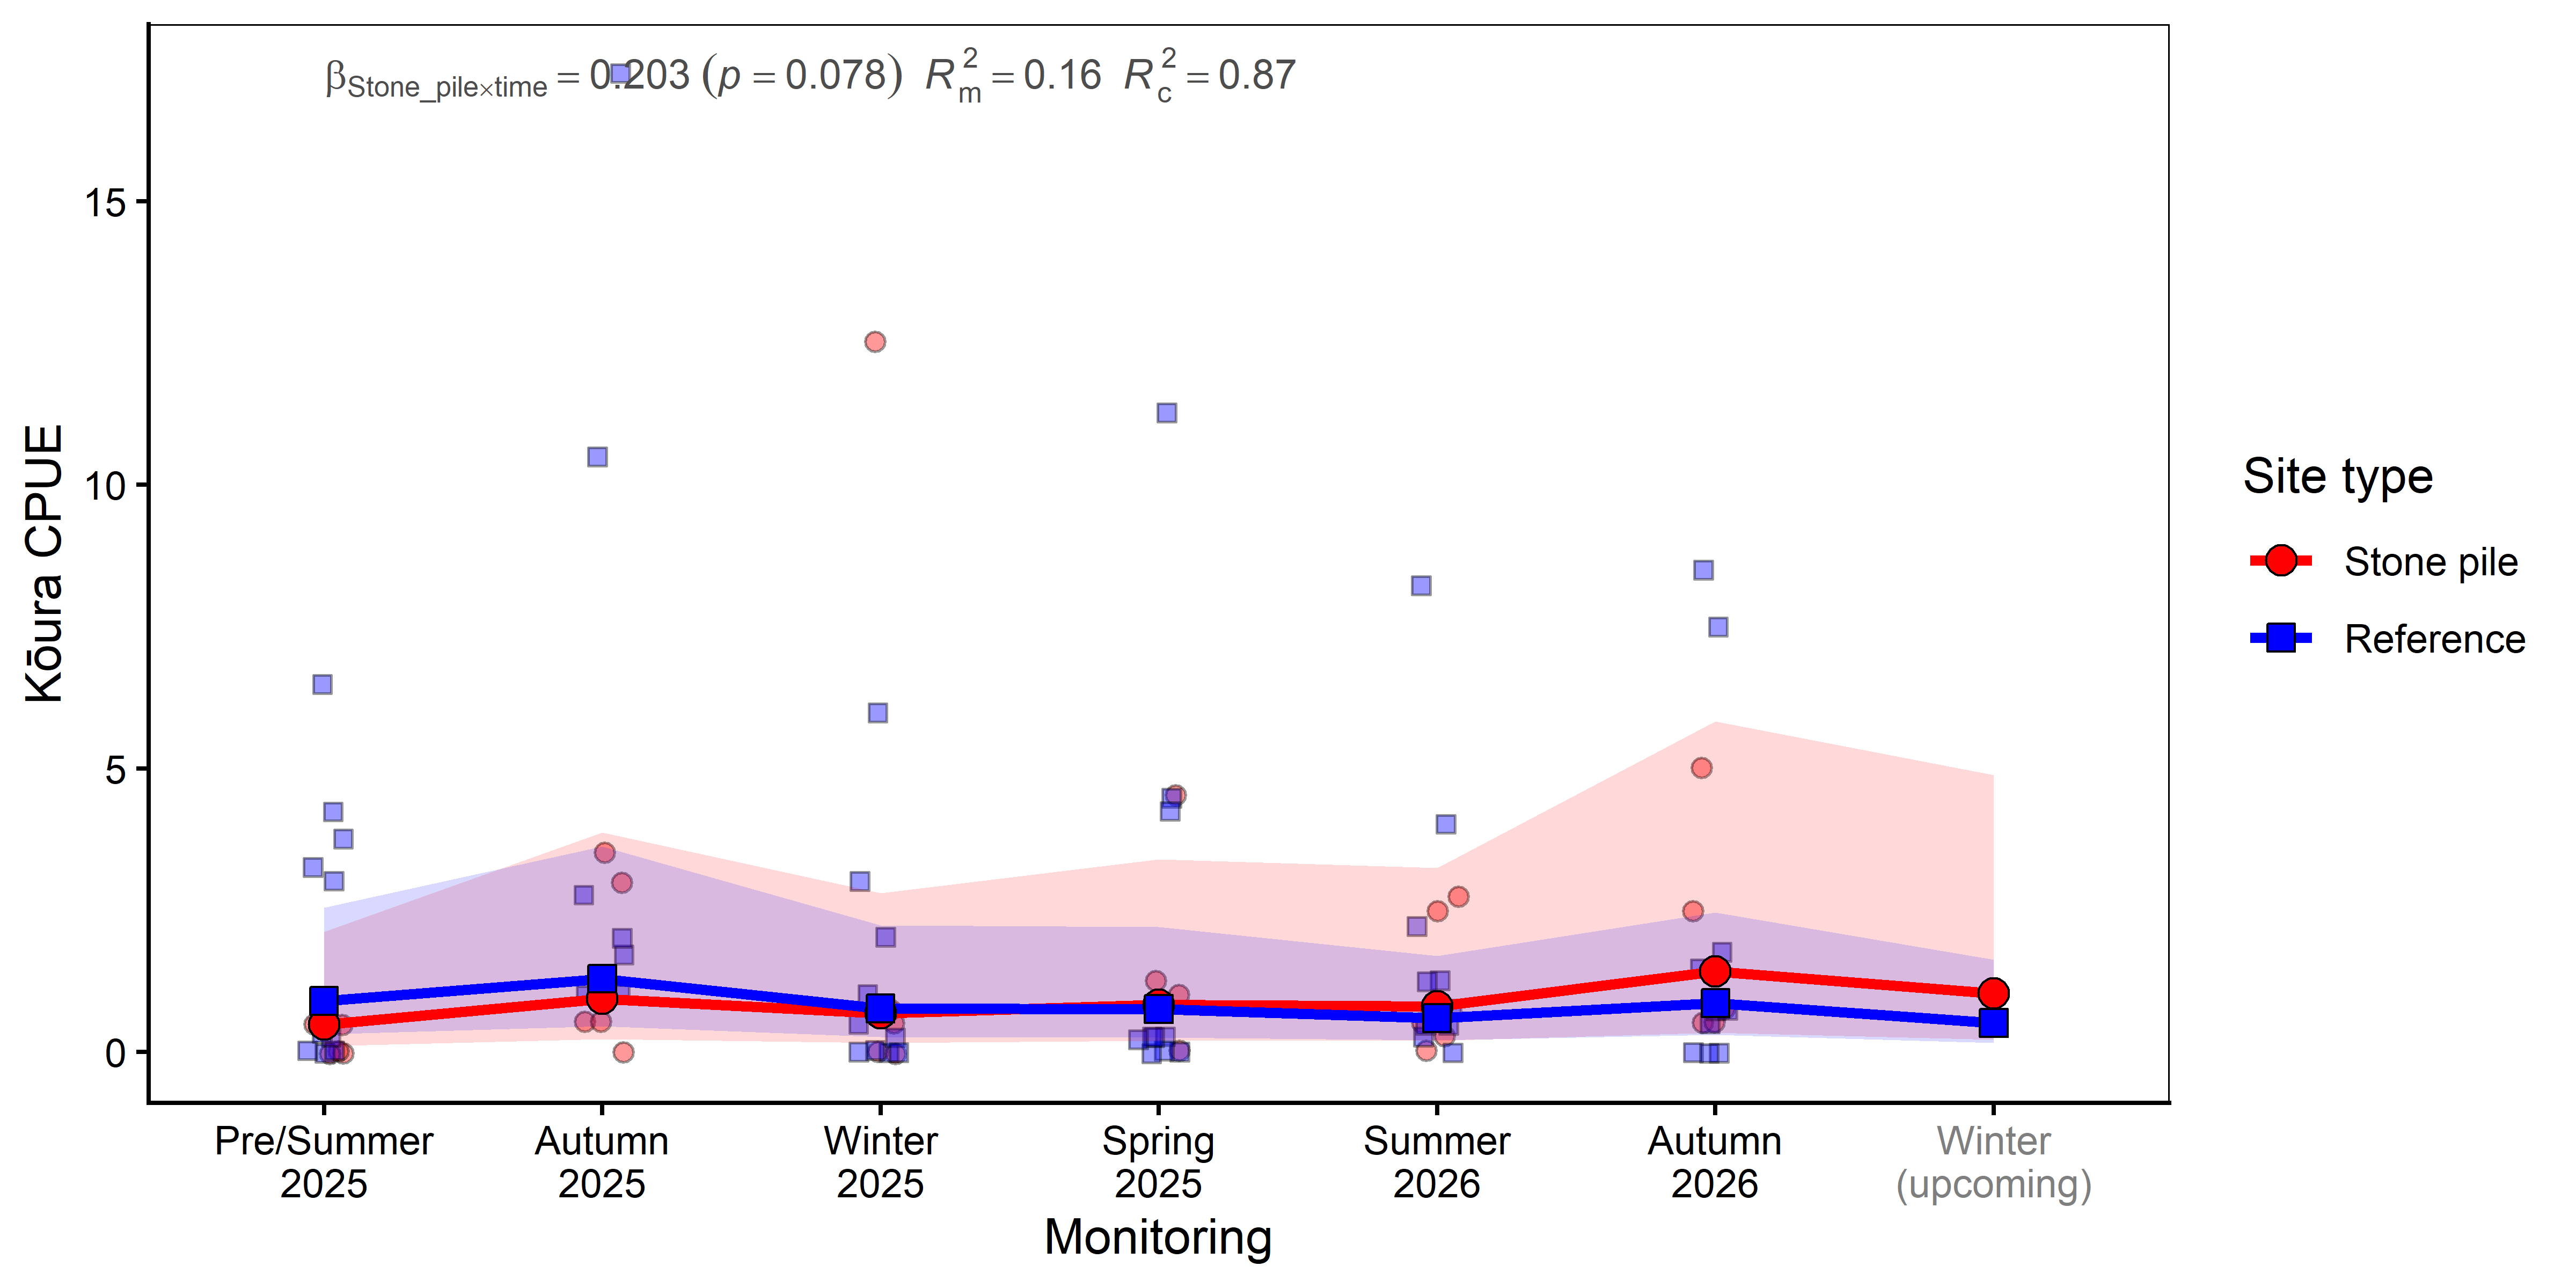

In [ ]:

M3ak <- pull_model(rq3_results, "Kōura", "abundance")

# Predicted trajectories at each monitoring round.
season_lookup <- c(`0` = "Summer", `1` = "Autumn", `2` = "Winter", `3` = "Spring",  `4` = "Summer", `5` = "Autumn", `6` = "Winter")

emmeans::emm_options(msg.interaction = FALSE)

site_substrate_lookup <- convergence_data %>%
  dplyr::distinct(site, monitoring_int, Substrate_index_after) %>%
  dplyr::mutate(period = dplyr::if_else(monitoring_int == 0, "baseline", "post")) %>%
  dplyr::group_by(site, period) %>%
  dplyr::summarise(Substrate_index_after = mean(Substrate_index_after, na.rm = TRUE), .groups = "drop")

emm_m3ak <- purrr::map_dfr(0:6, function(i) {
  period_i <- if (i == 0) "baseline" else "post"
  purrr::map_dfr(c("Stone_pile", "Reference"), function(s) {
    sub_idx <- site_substrate_lookup$Substrate_index_after[
      site_substrate_lookup$site == s & site_substrate_lookup$period == period_i]
    emmeans(M3ak, ~ site,
      at   = list(monitoring_int = i, Season = season_lookup[[as.character(i)]],
                   Substrate_index_after = sub_idx),
      type = "response") %>%
      as.data.frame() %>%
      dplyr::filter(site == s) %>%
      dplyr::mutate(monitoring_int = i)
  })
}) %>%
  dplyr::rename(lower.CL = dplyr::any_of("asymp.LCL"),
                upper.CL = dplyr::any_of("asymp.UCL")) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

# Clean numeric values for annotation
beta_val <- round(glmmTMB::fixef(M3ak)$cond["siteStone_pile:monitoring_int"], 3)
p_val    <- round(summary(M3ak)$coefficients$cond["siteStone_pile:monitoring_int", "Pr(>|z|)"], 3)
r2_vals  <- MuMIn::r.squaredGLMM(M3ak)
r2m_val  <- round(r2_vals[1, "R2m"], 2)
r2c_val  <- round(r2_vals[1, "R2c"], 2)

# Use plotmath-safe expression
model_label <- paste0("italic(beta)[Stone_pile%*%time]==", beta_val, "~(italic(p)==", p_val, ")", "~~italic(R)[m]^2==", r2m_val, "~~italic(R)[c]^2==", r2c_val)

convergence_data_plot <- convergence_data %>%
  filter(!is.na(`Weighted_CPUE_Kōura`)) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

convergence_plot <- ggplot() +
  geom_point(data = convergence_data_plot, aes(monitoring_int, `Weighted_CPUE_Kōura`,  fill = site, shape = site),  colour = "black",  alpha = 0.4, size = 1.8, stroke = 0.5, position = position_jitter(width = 0.08, seed = 42),show.legend = FALSE) +
  geom_ribbon(data = emm_m3ak, aes(monitoring_int, response,  ymin = lower.CL, ymax = upper.CL, fill = site),  alpha = 0.15, colour = NA,  show.legend = FALSE) +
  geom_line(data = emm_m3ak,  aes(monitoring_int, response,  colour = site, group = site), linewidth = 1.1) +
  geom_point(data = emm_m3ak, aes(monitoring_int, response,  fill = site, shape = site), colour = "black", size = 3, stroke = 0.4) +
  annotate("text", x = 0, y = Inf, label = model_label, parse = TRUE,  hjust = 0, vjust = 1.4, size = 3.2, colour = "grey30") +
  scale_colour_manual(values = conv_colours, labels = conv_labels) +
  scale_fill_manual(  values = conv_fill,    labels = conv_labels) +
  scale_shape_manual( values = conv_shapes,  labels = conv_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(x= "Monitoring",y= "Kōura CPUE",colour = "Site type",fill= "Site type",shape  = "Site type")+
  theme(axis.text.x = element_text(colour = c(rep("black", 6), "grey50")))


## Model diagnostics

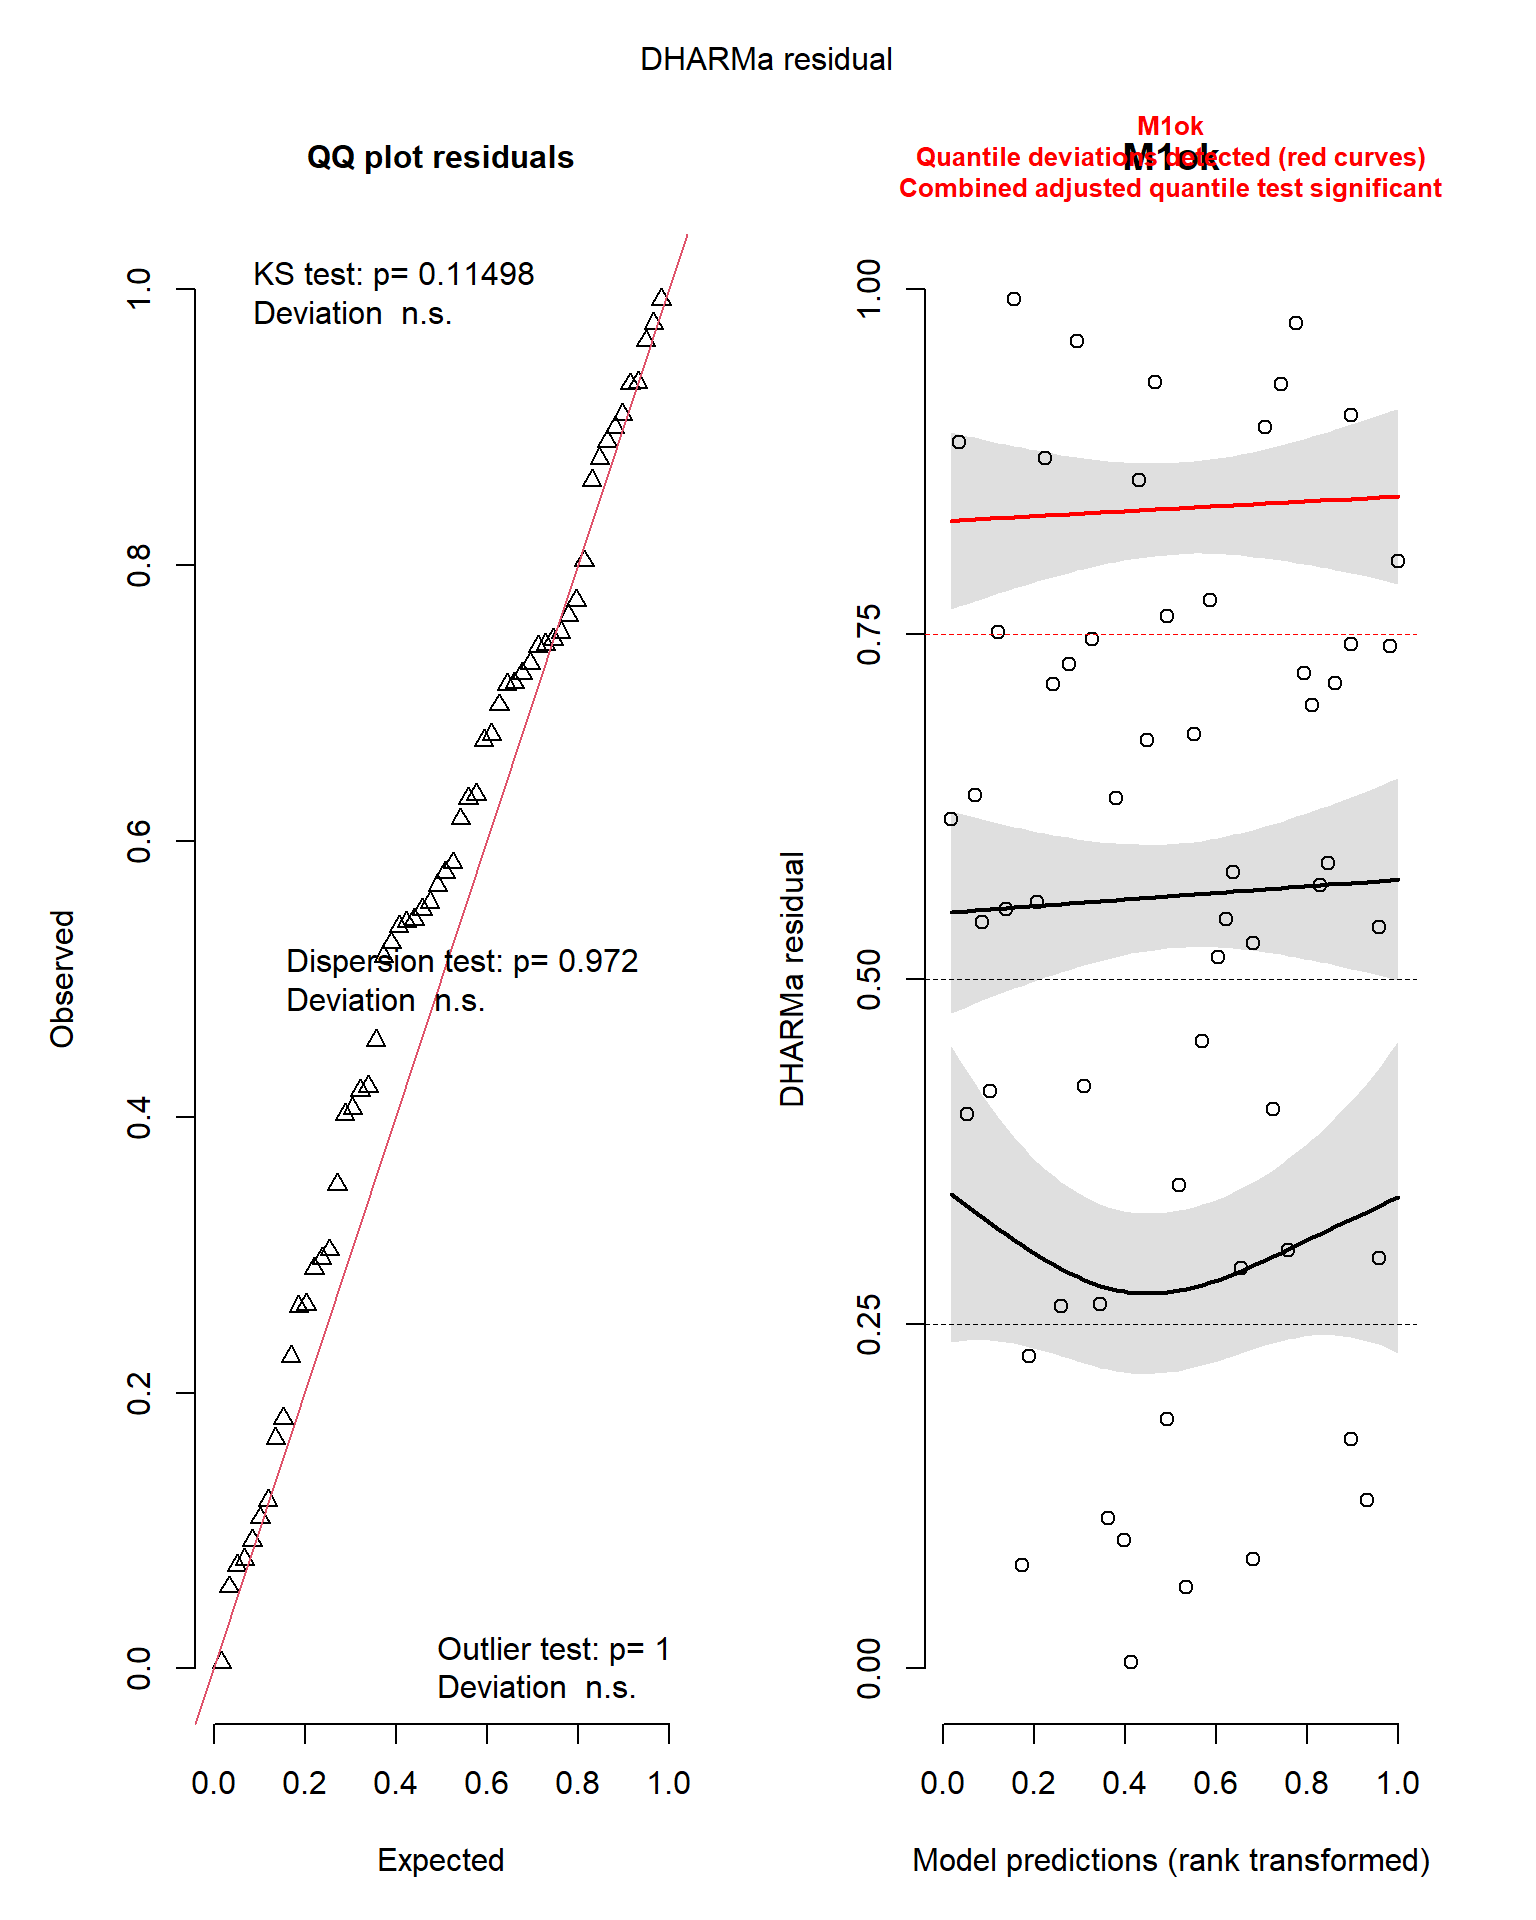

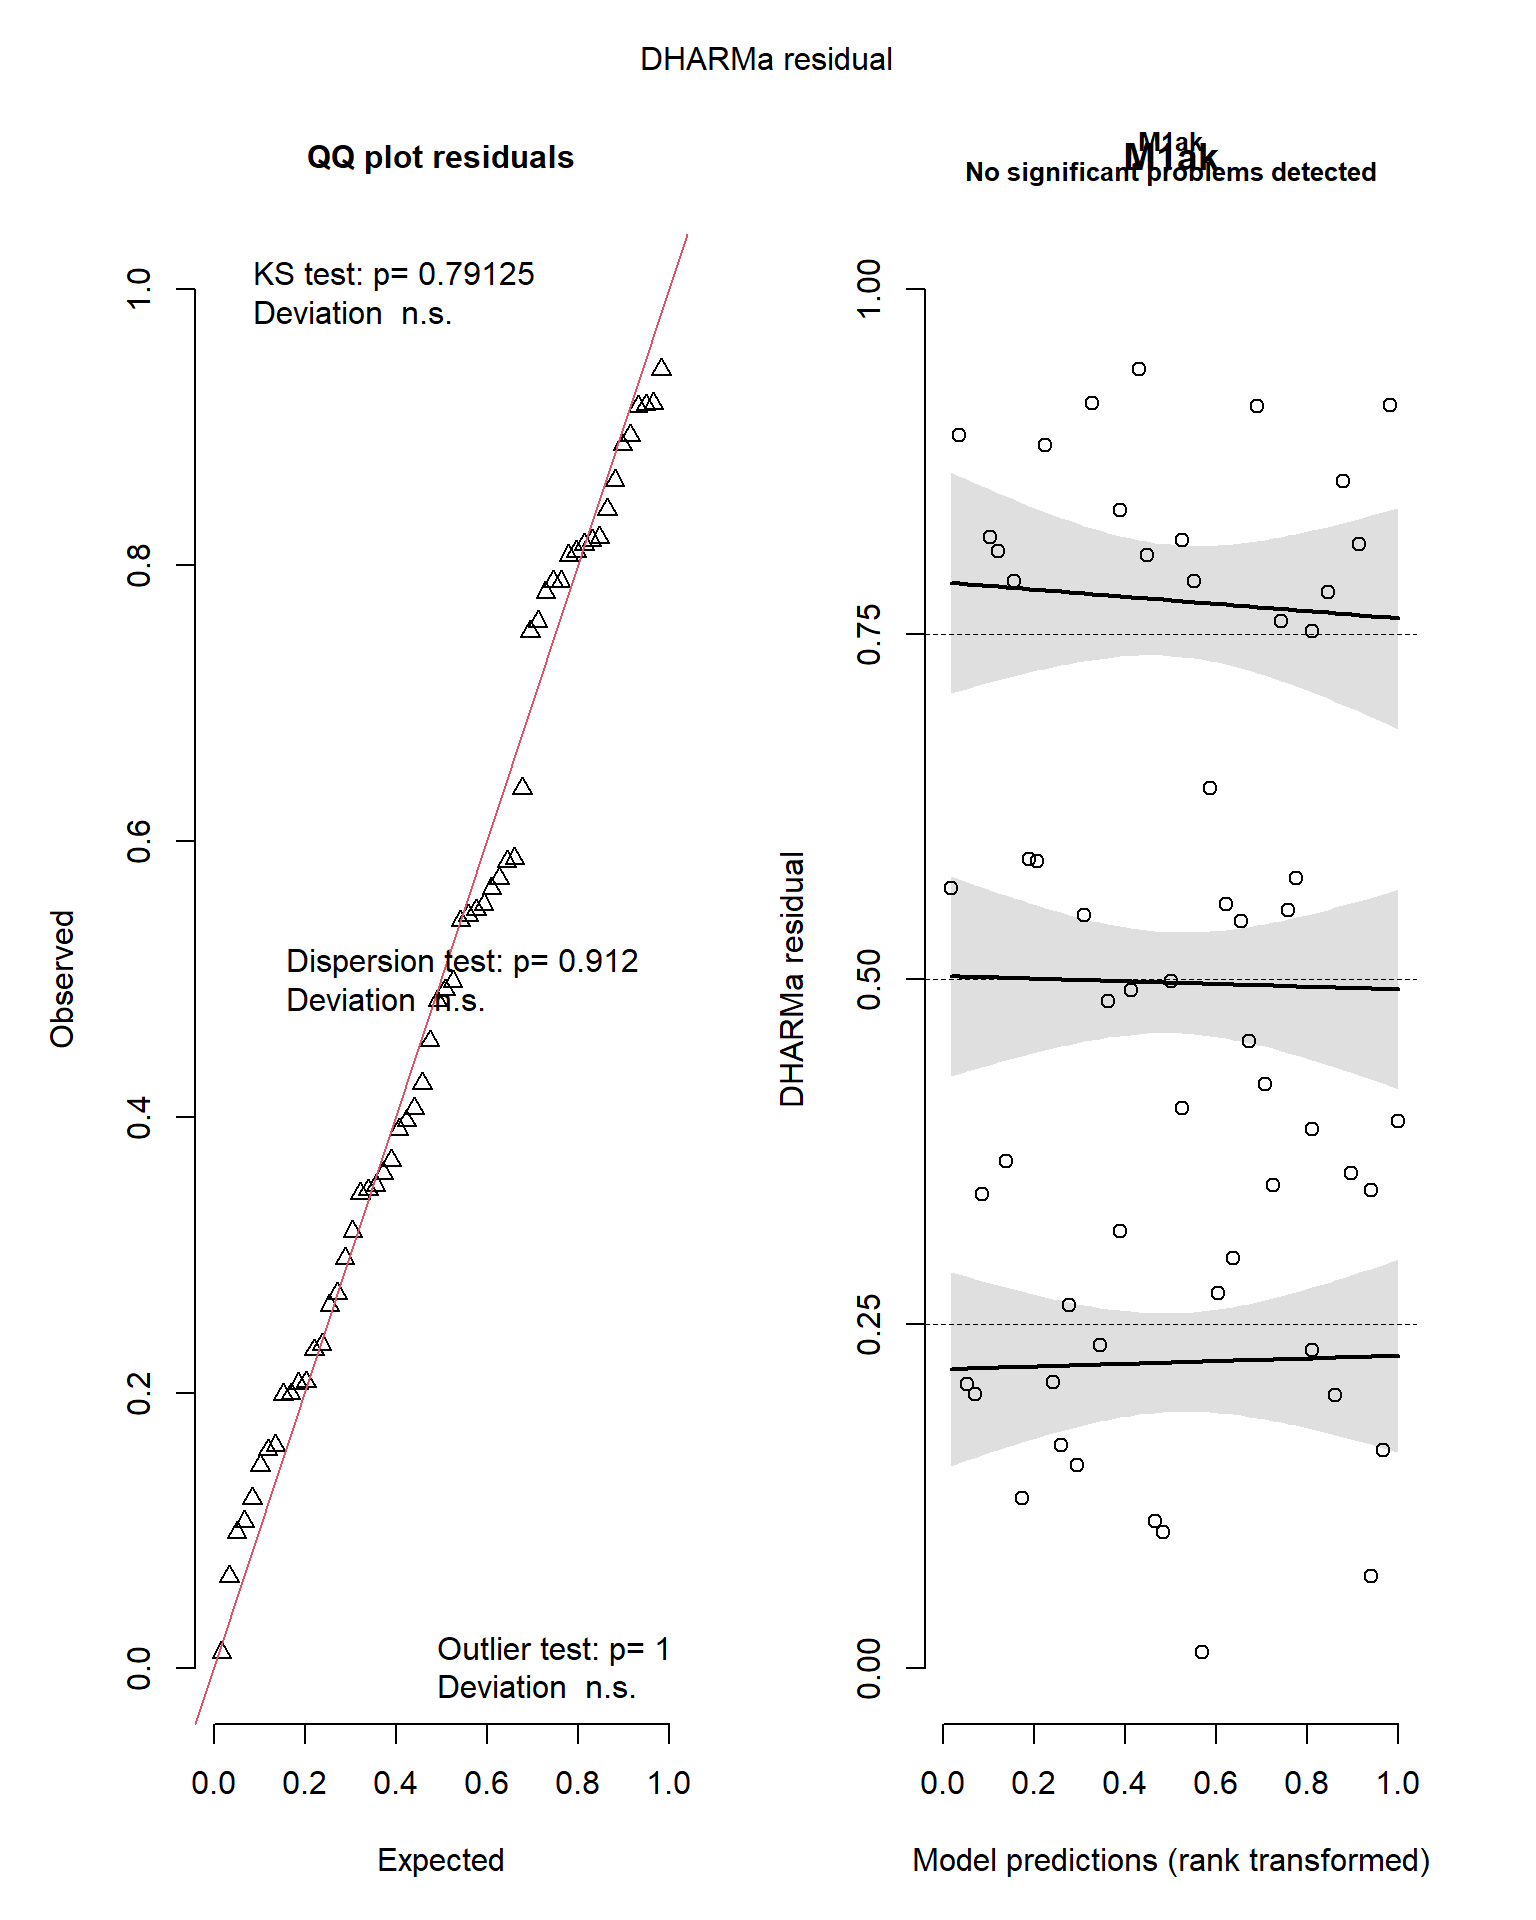

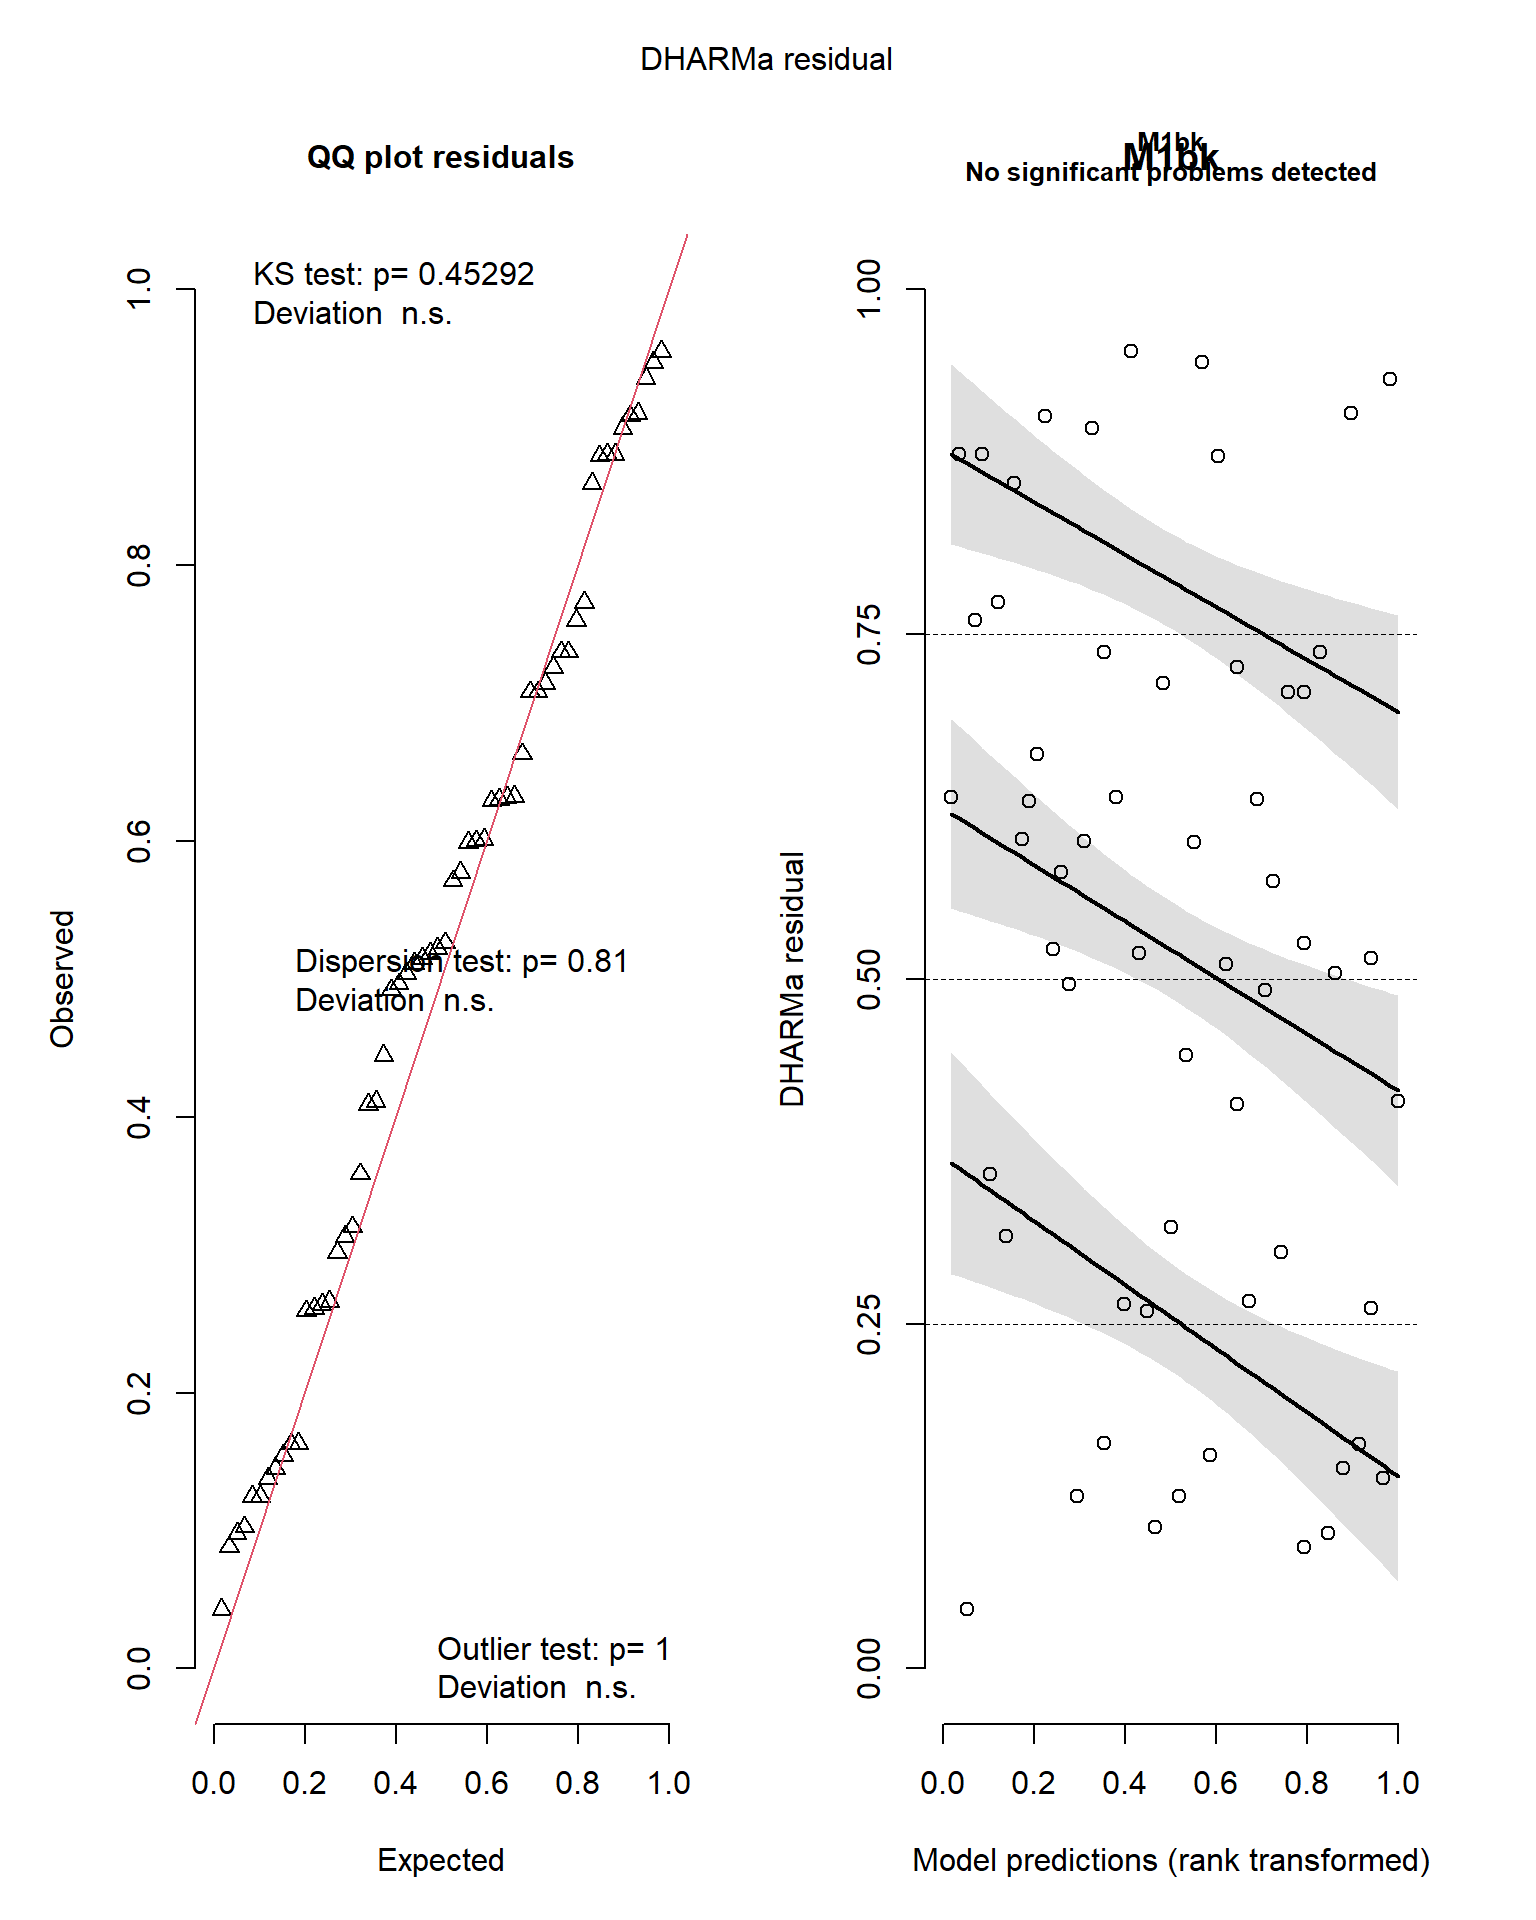

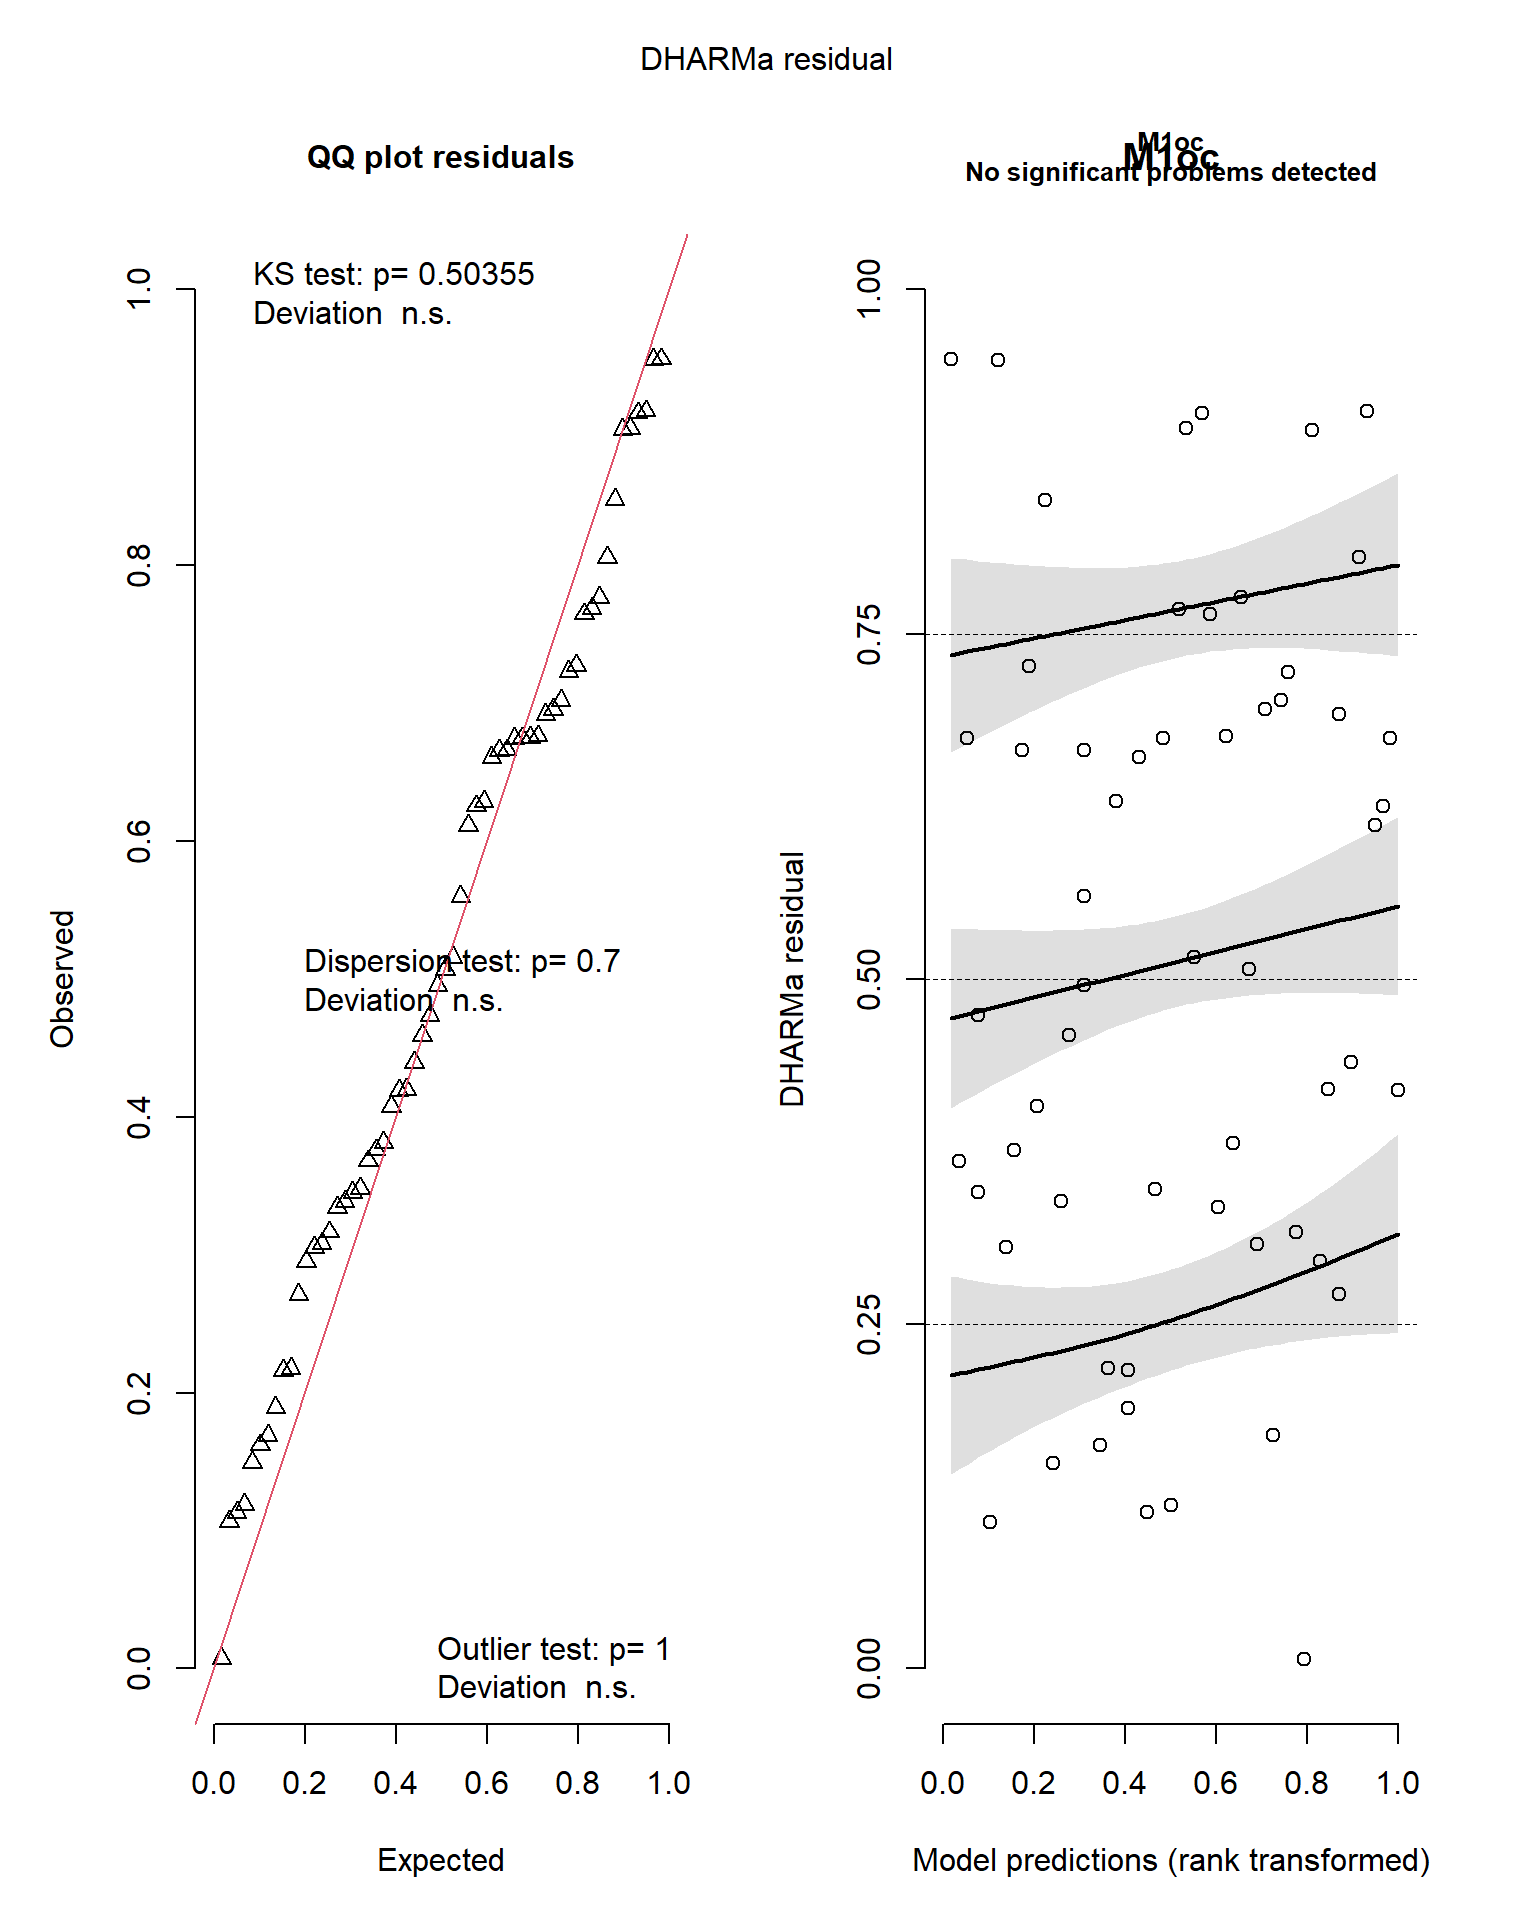

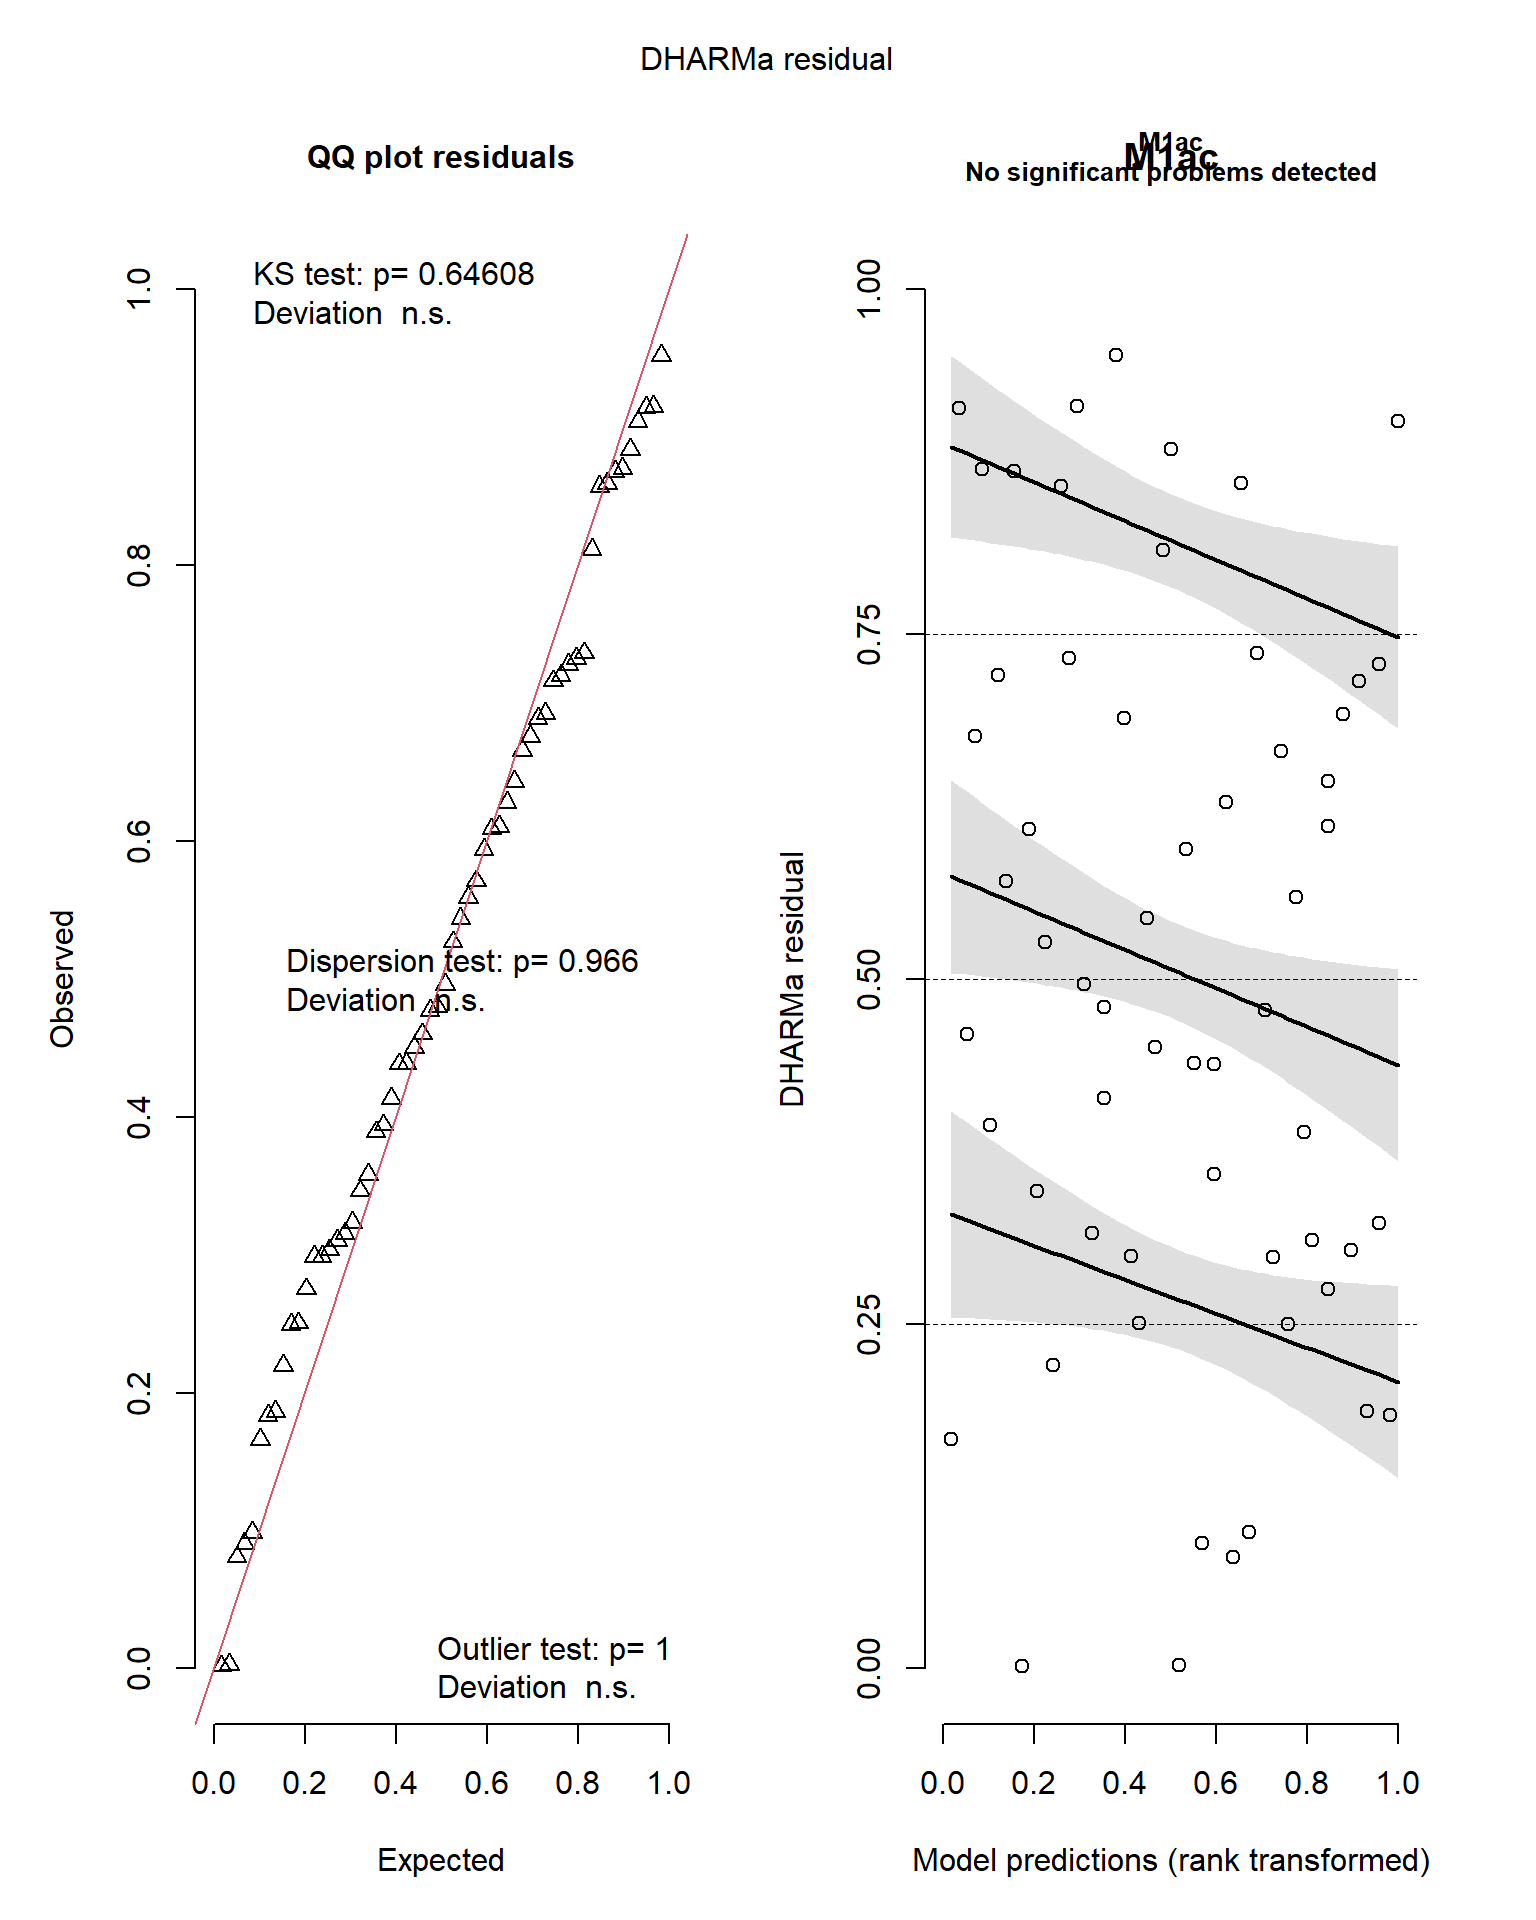

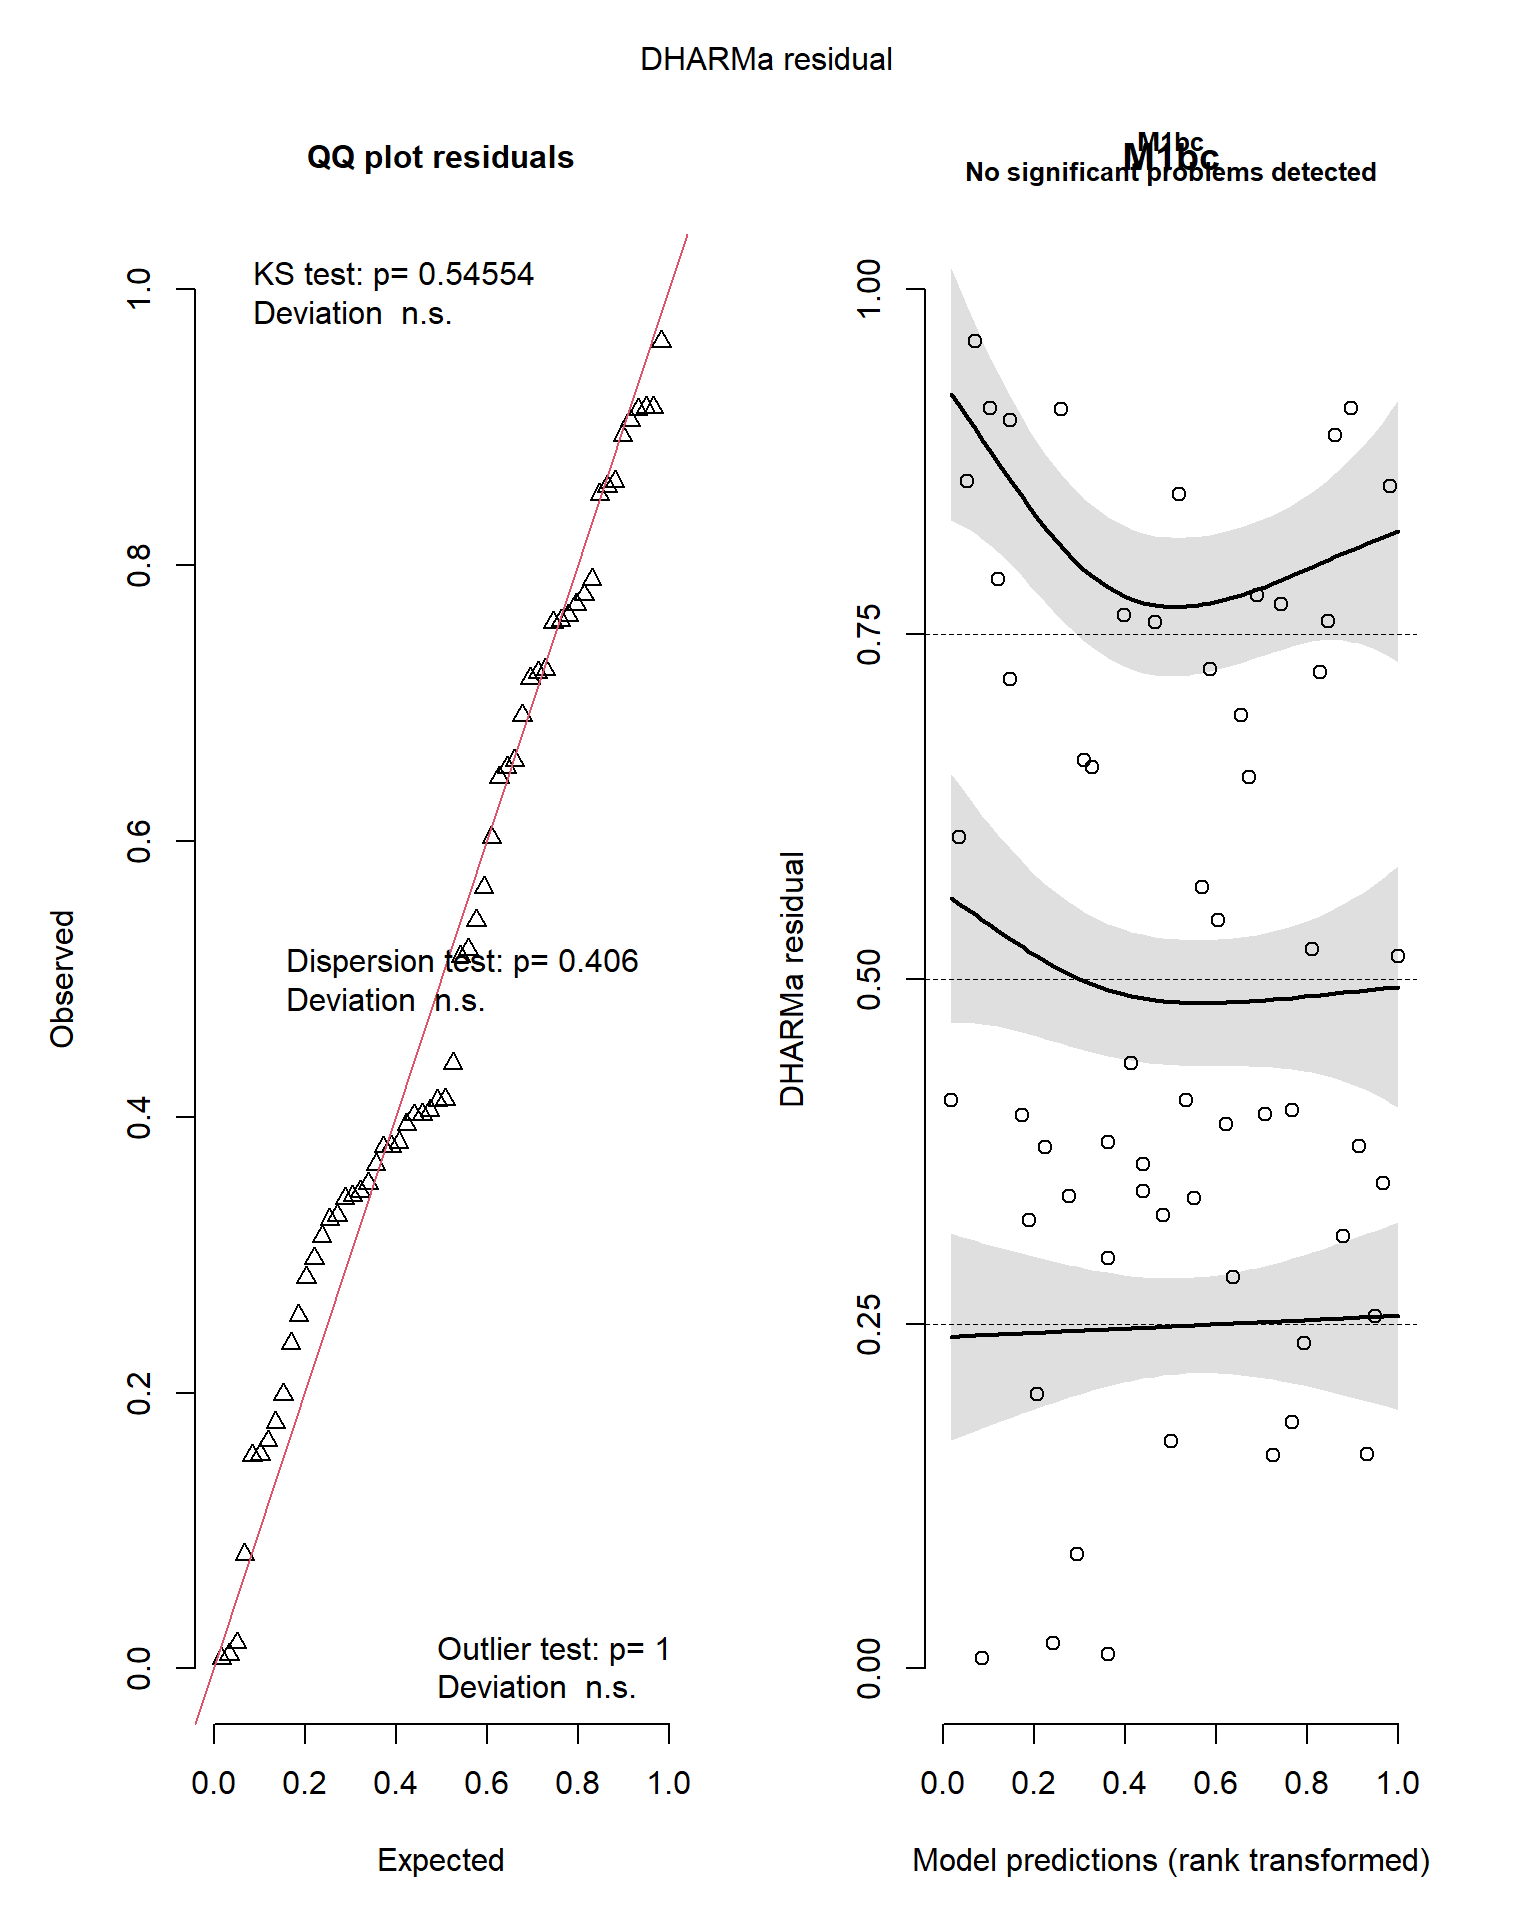

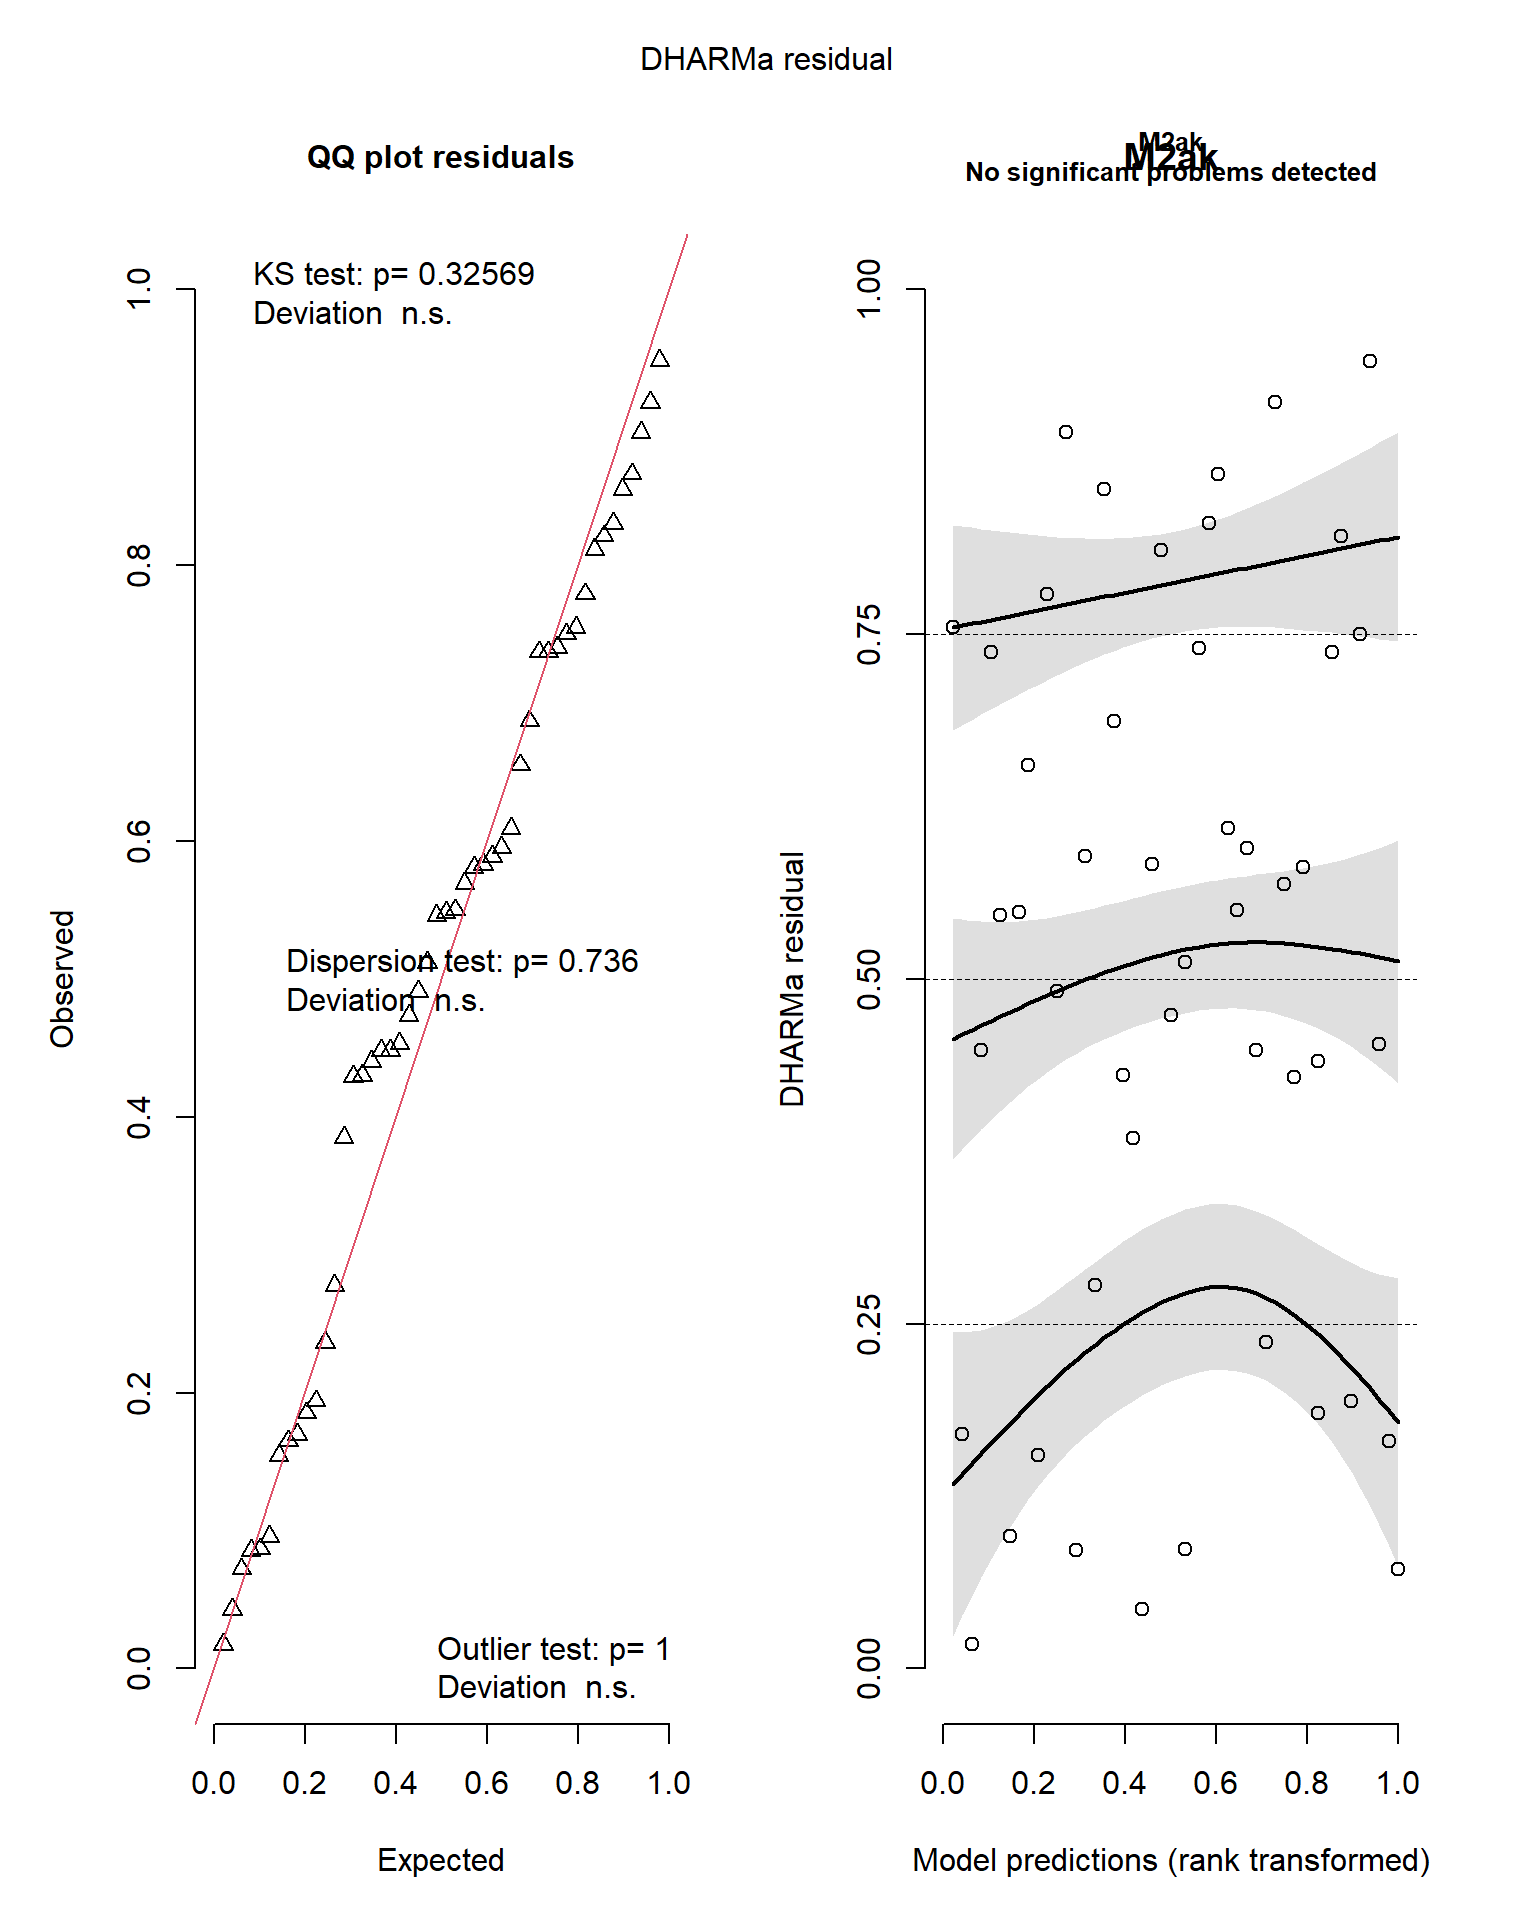

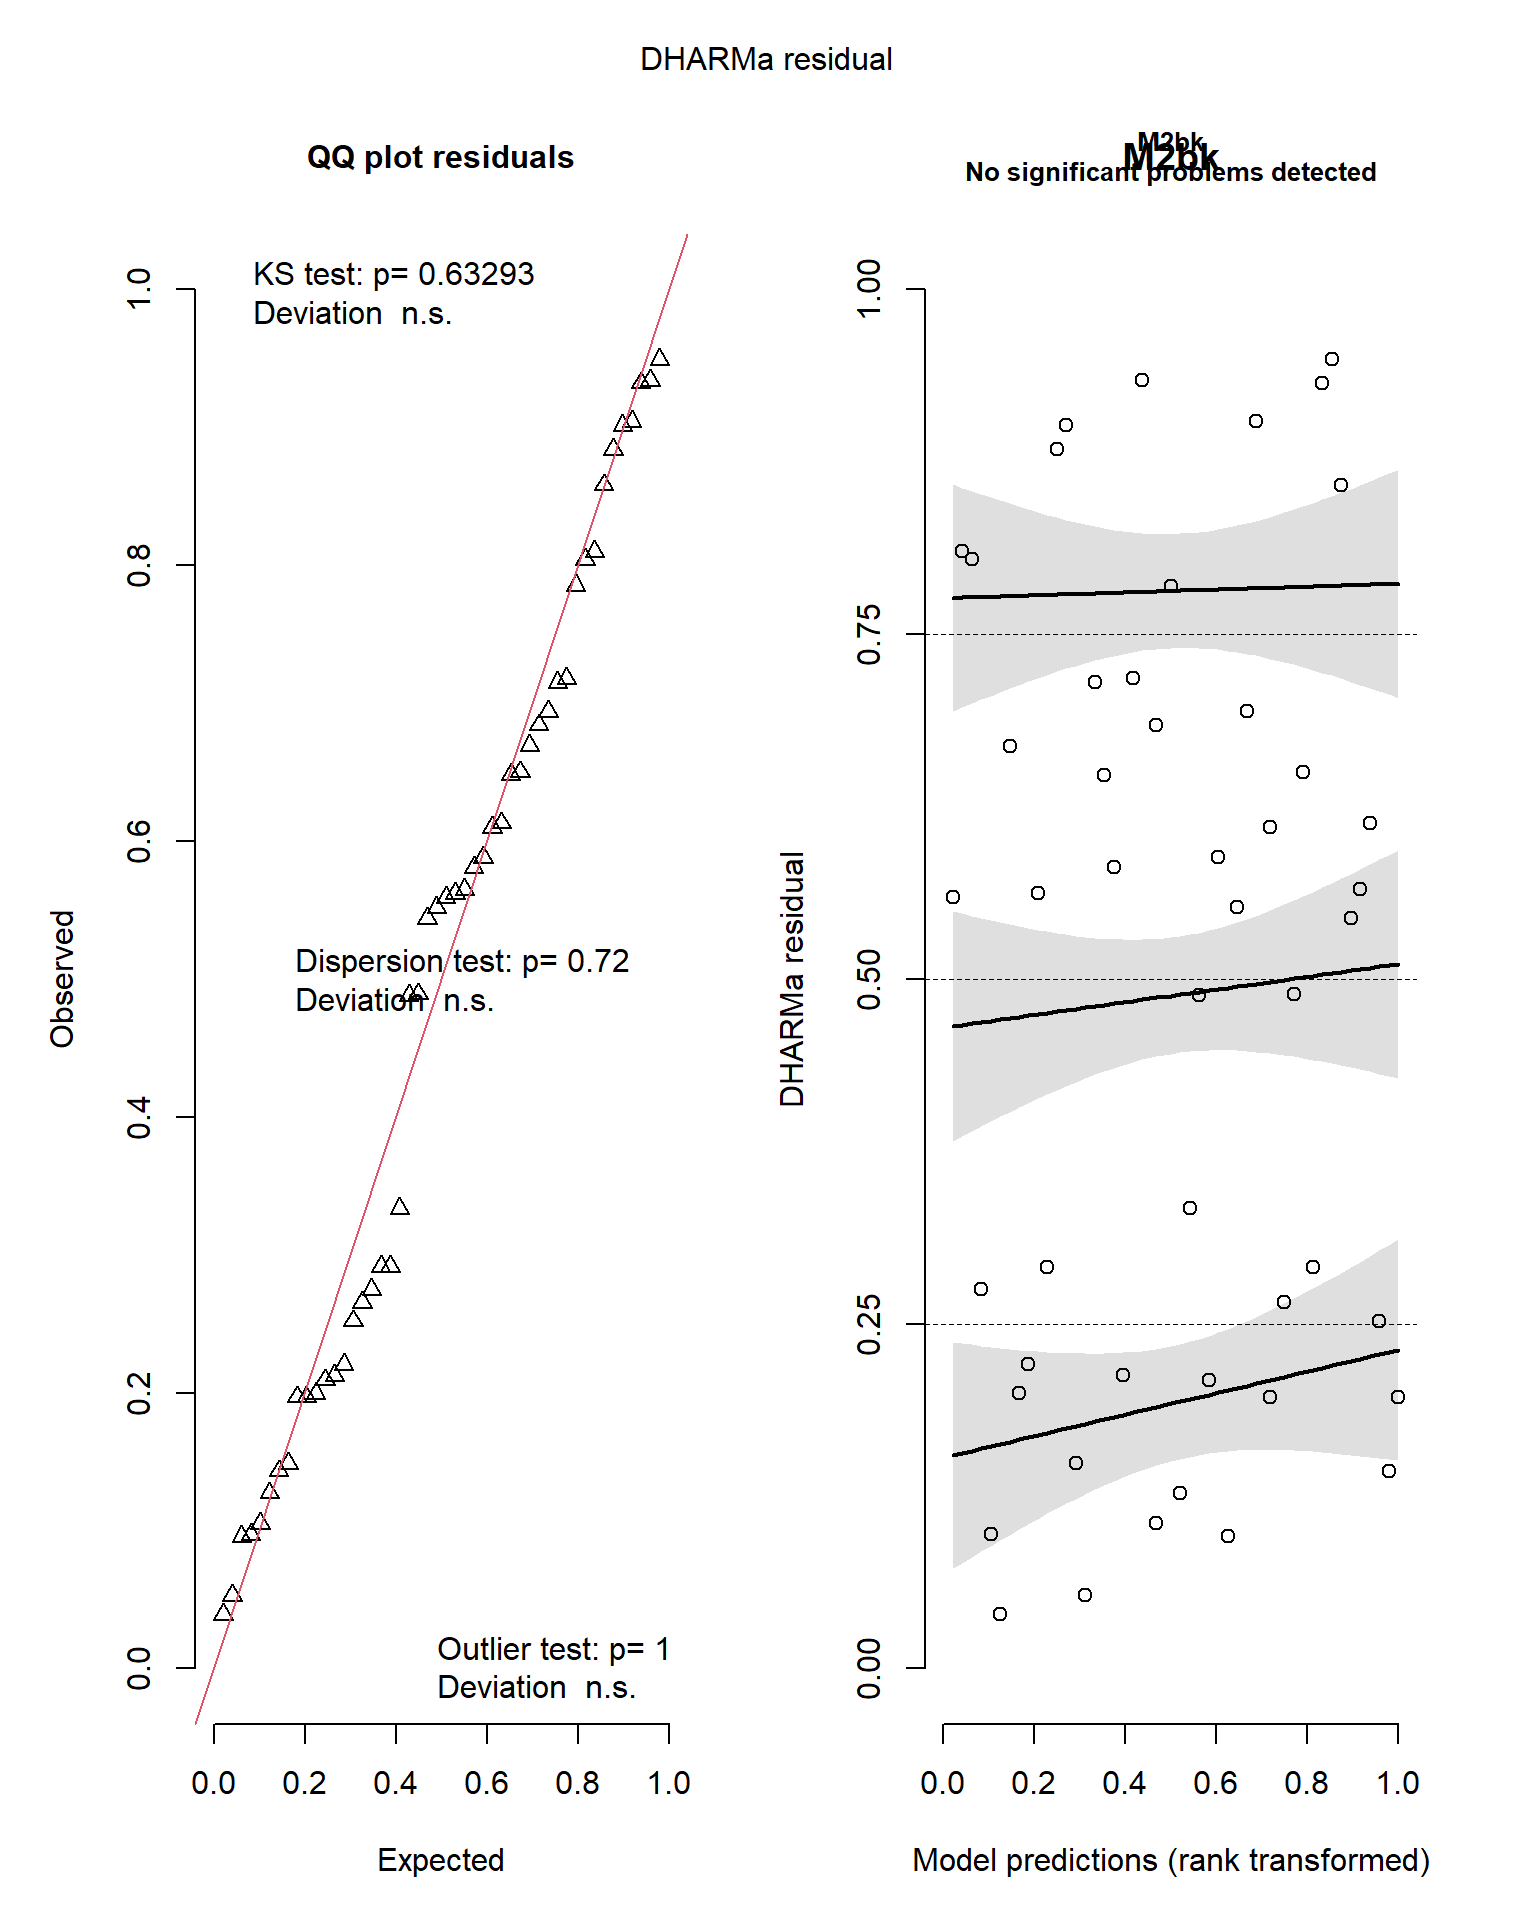

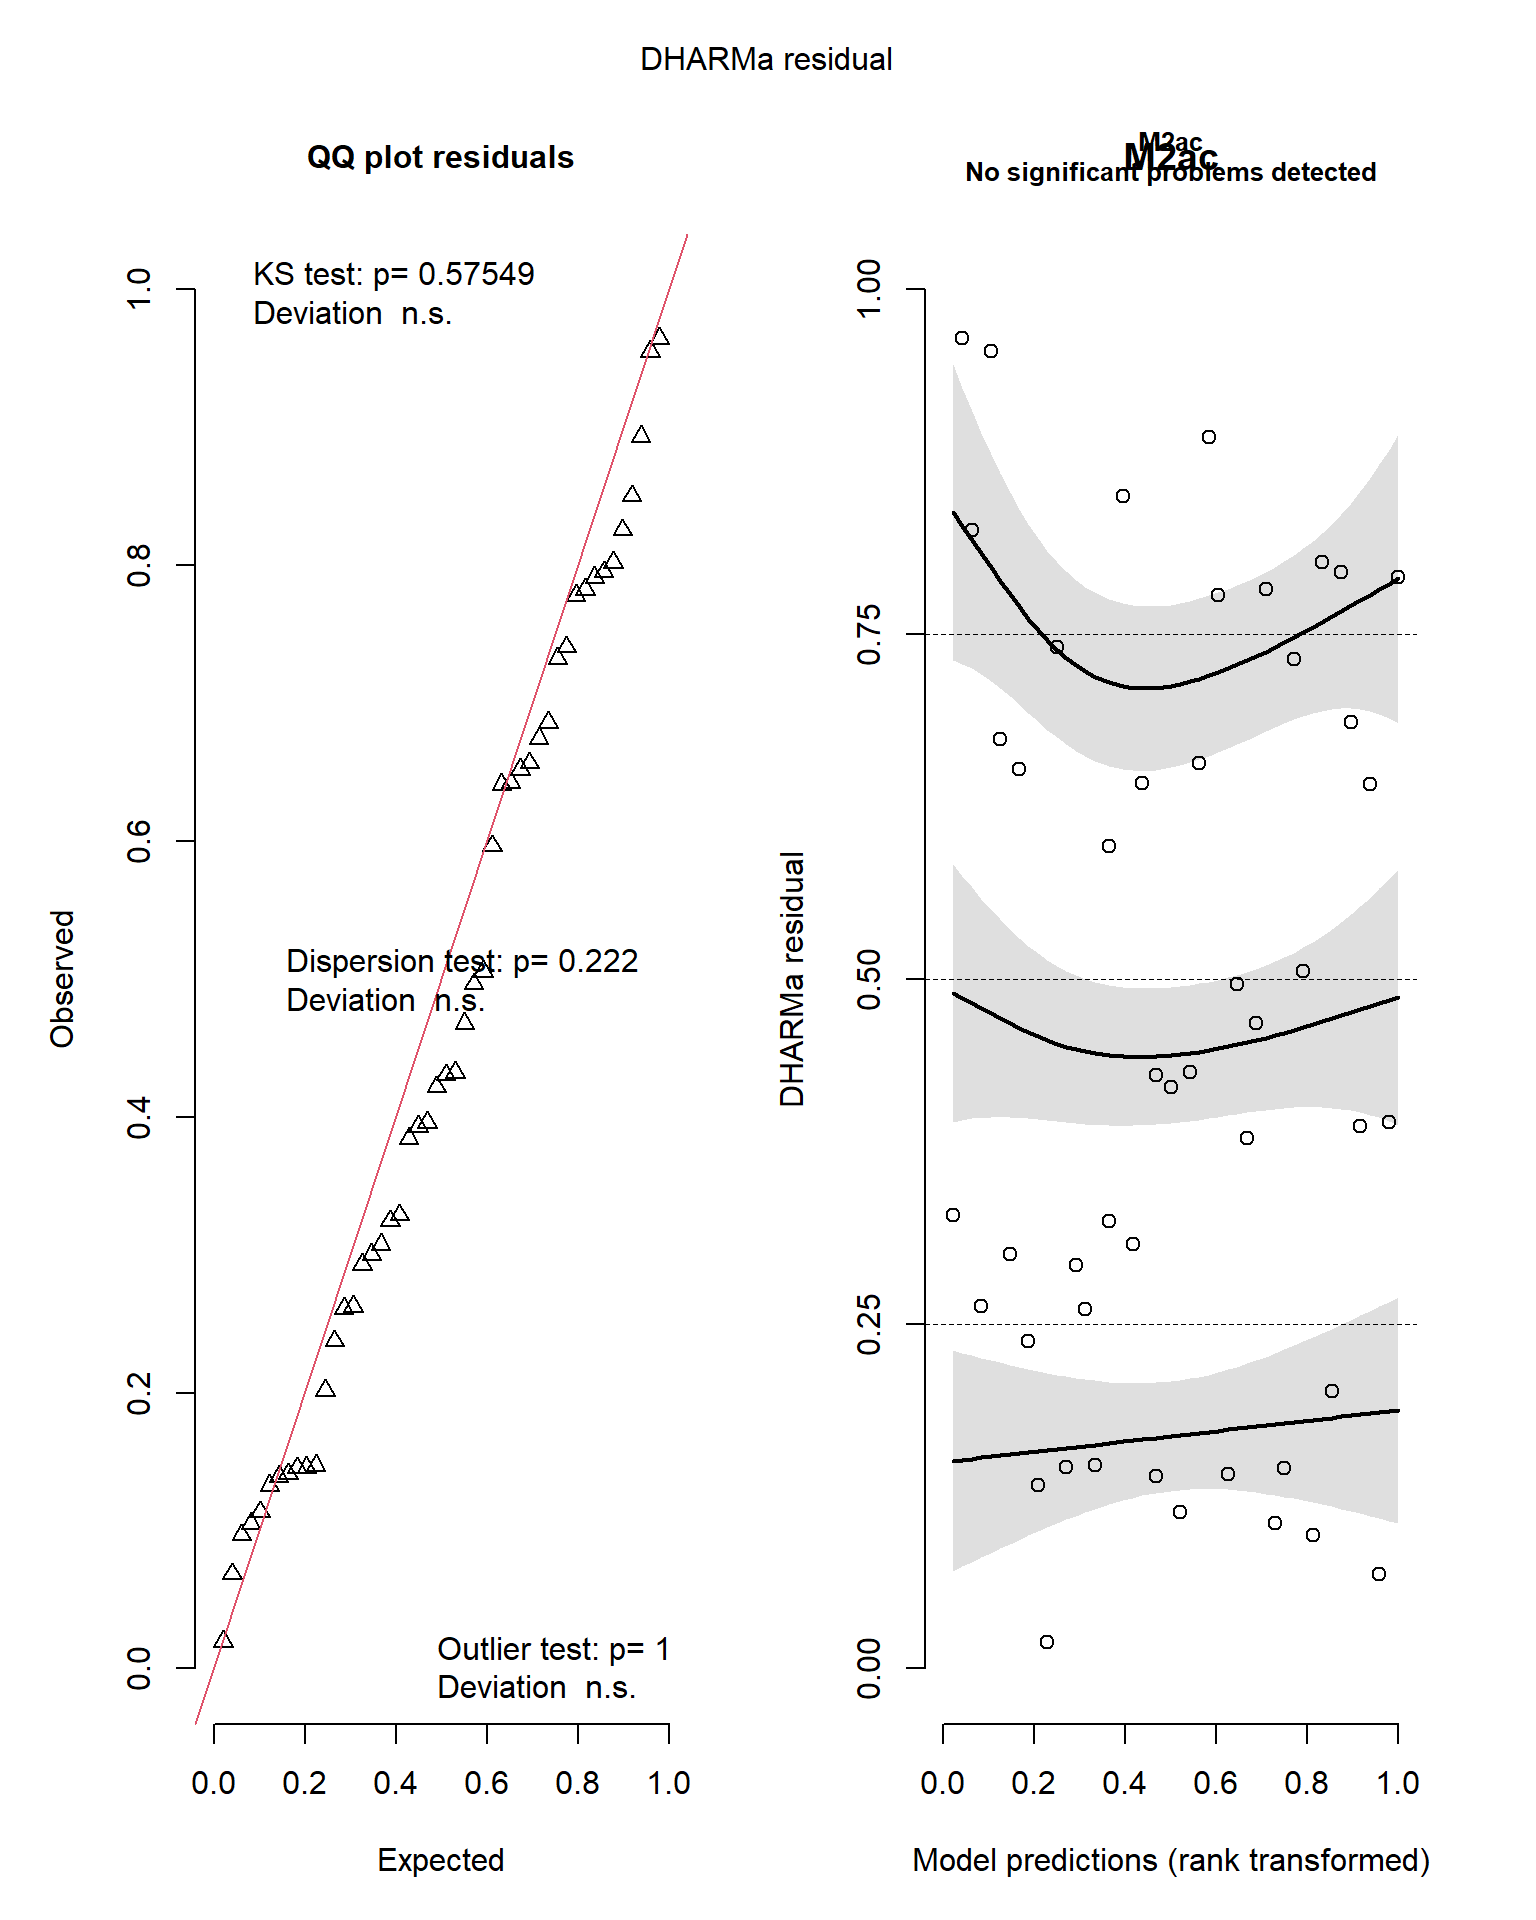

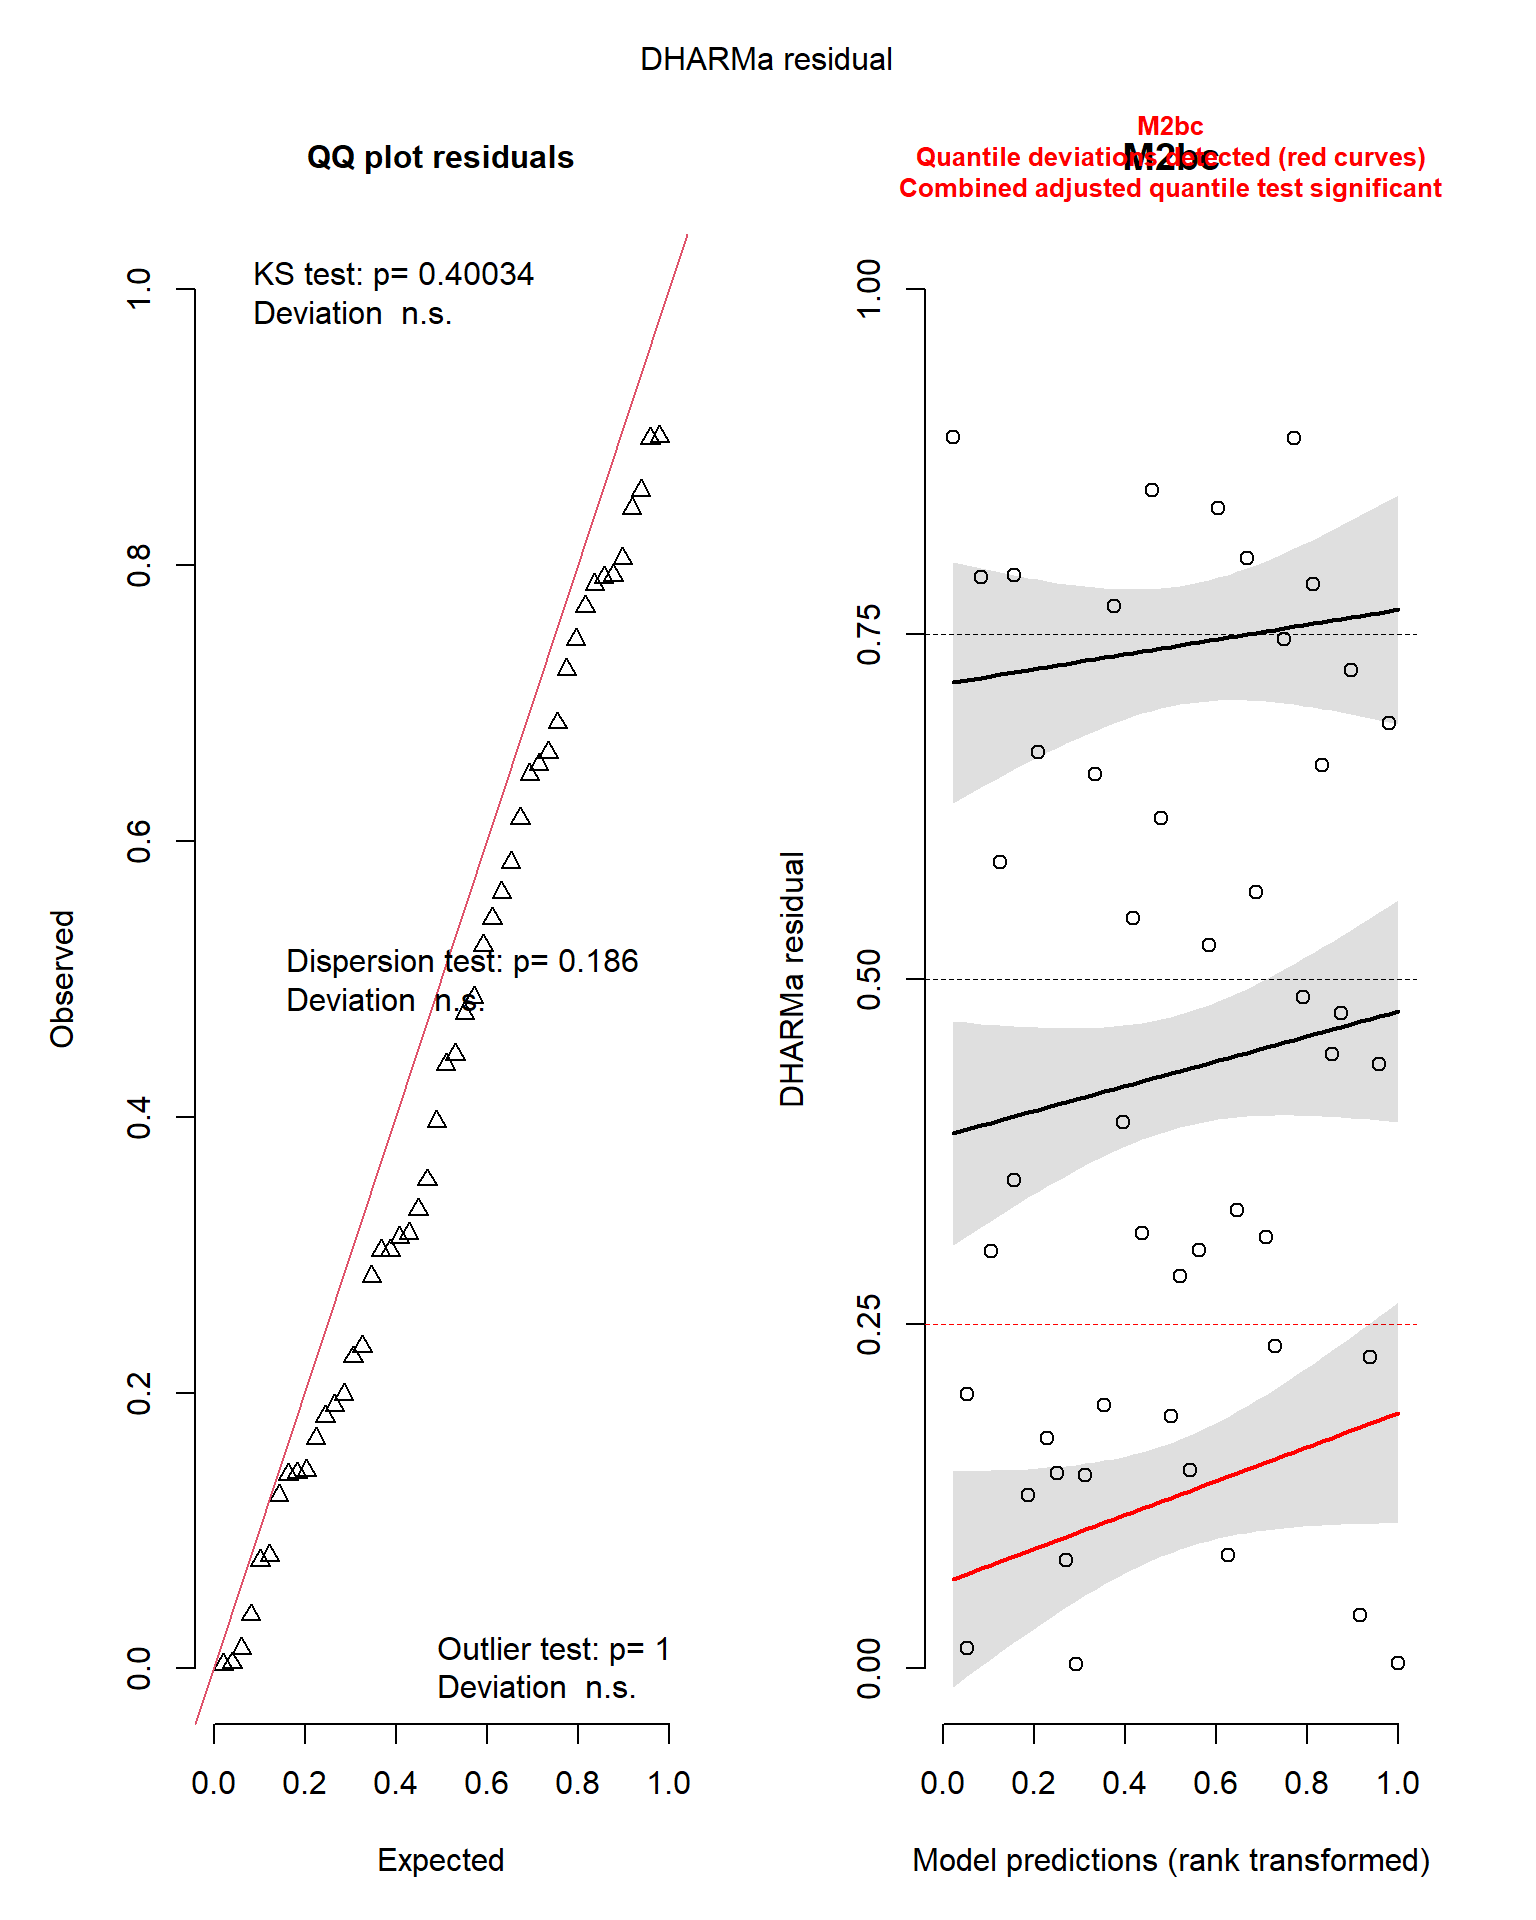

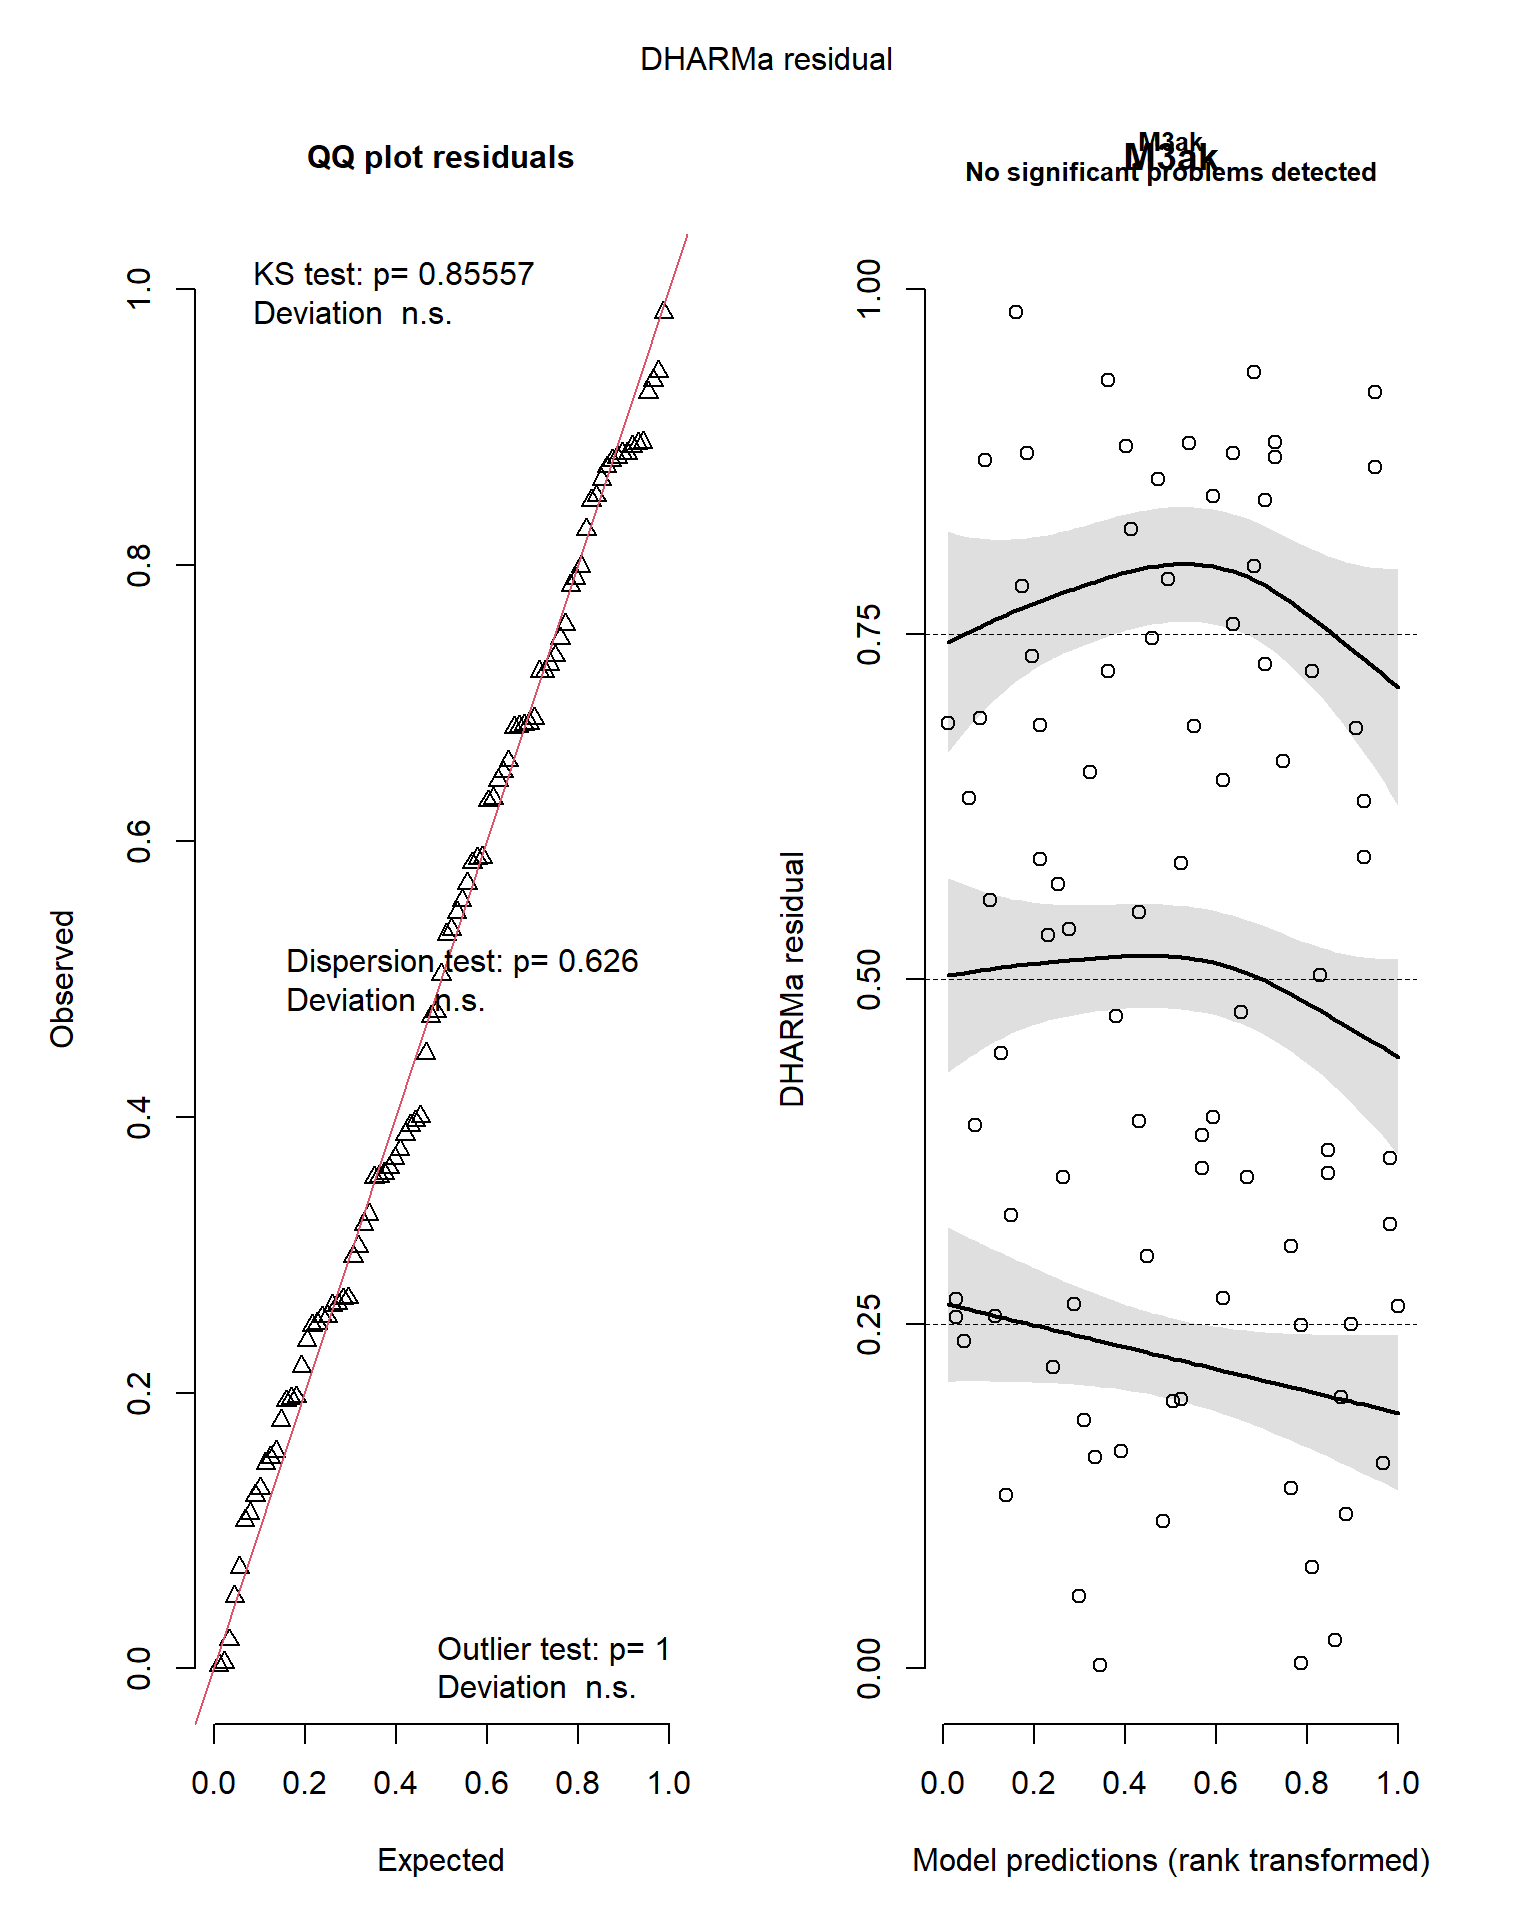

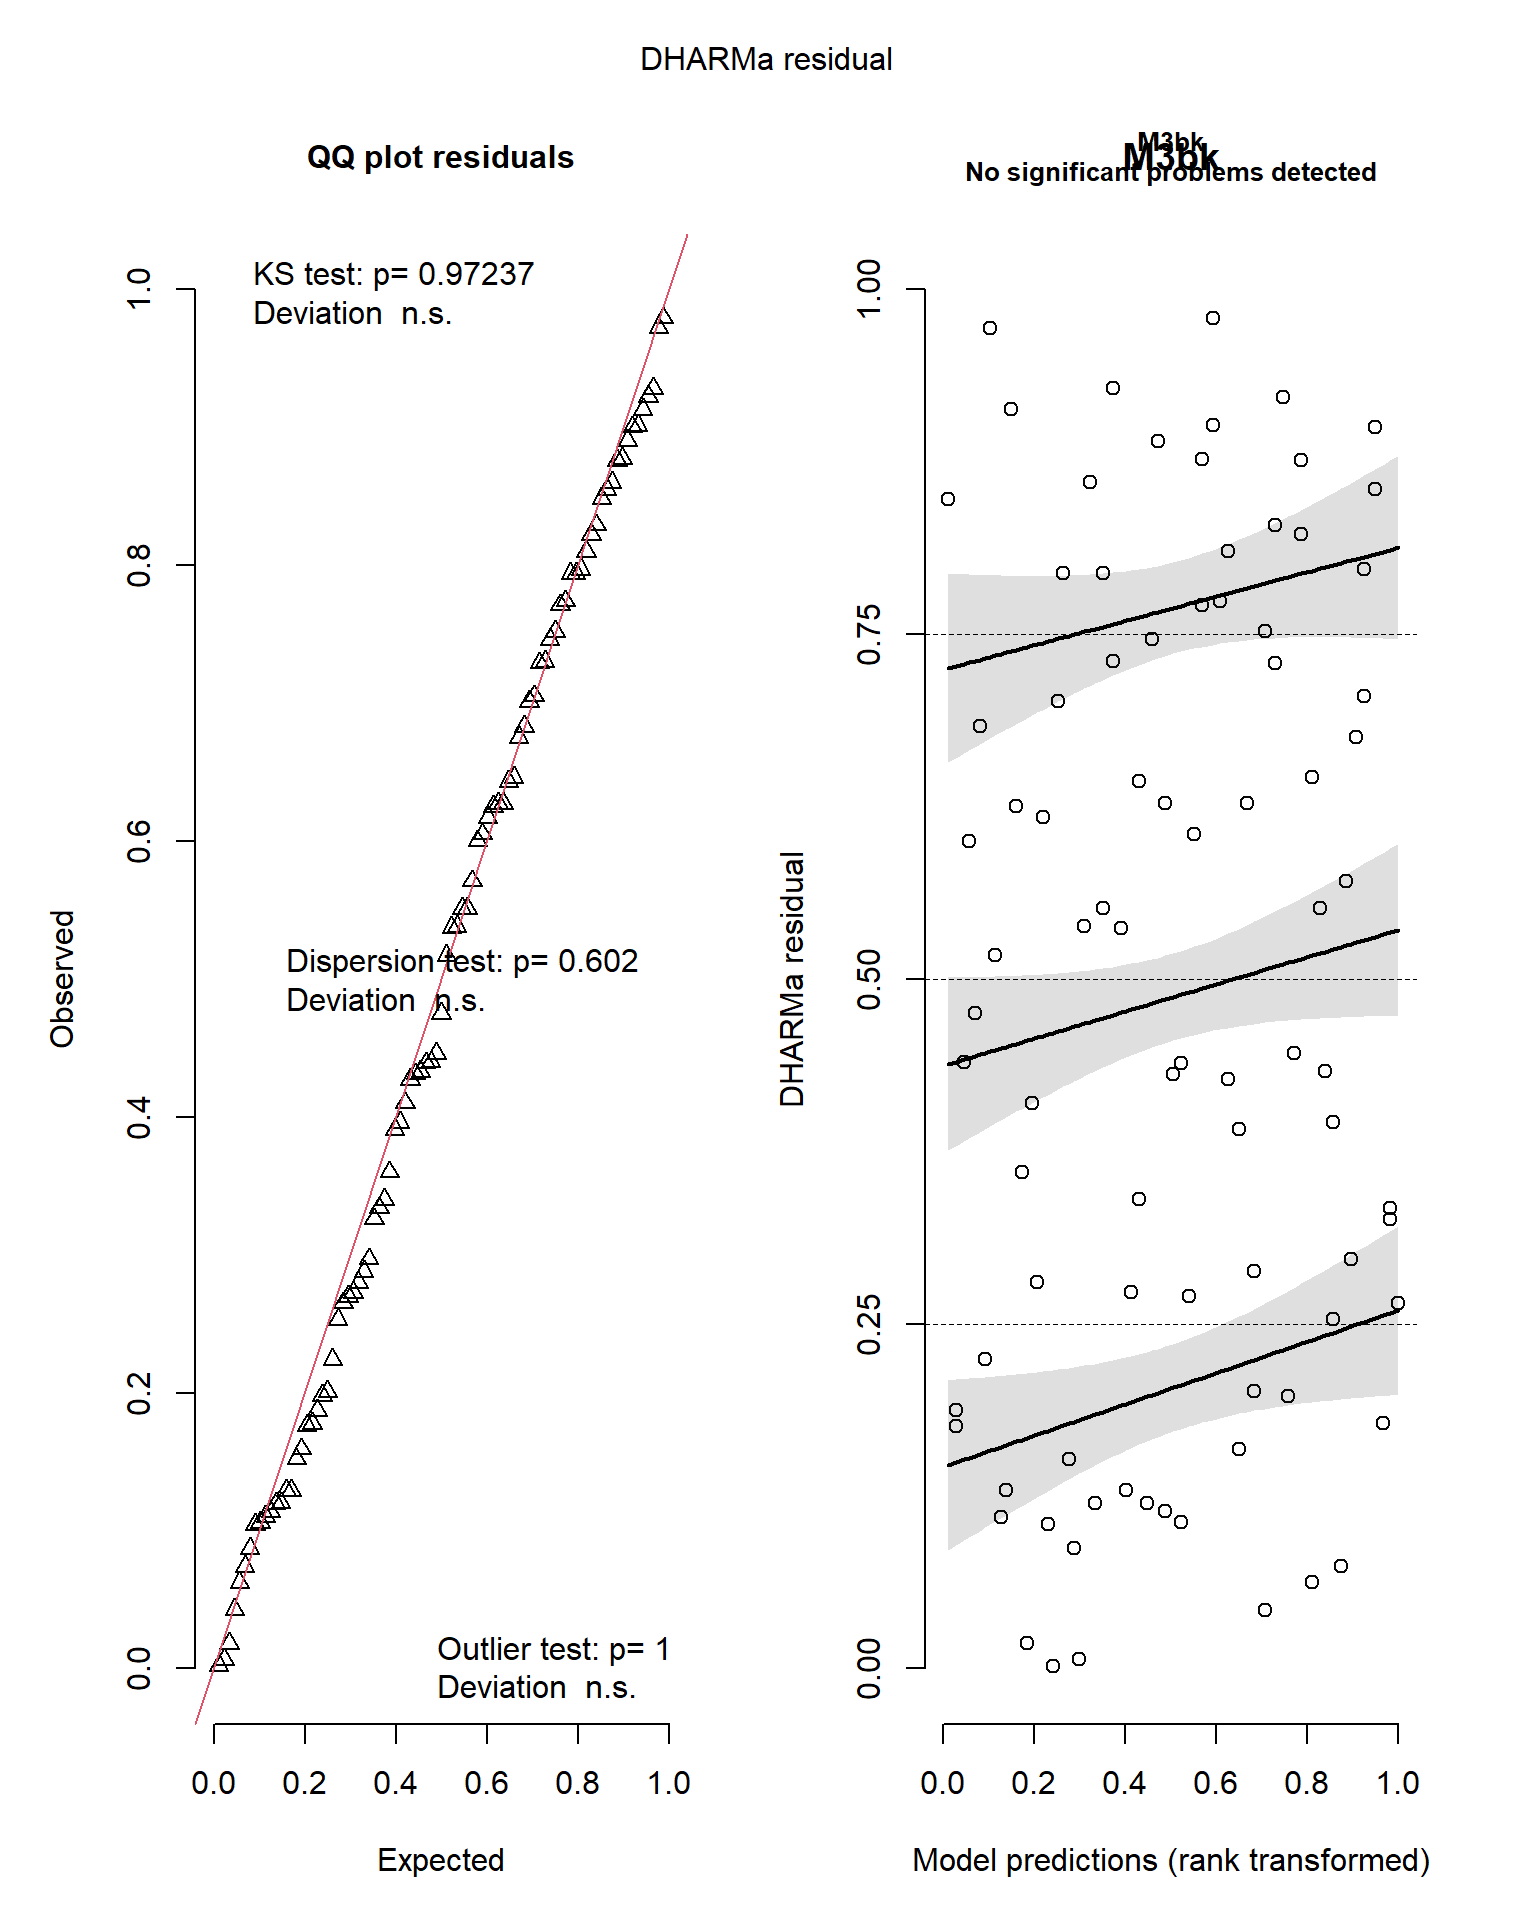

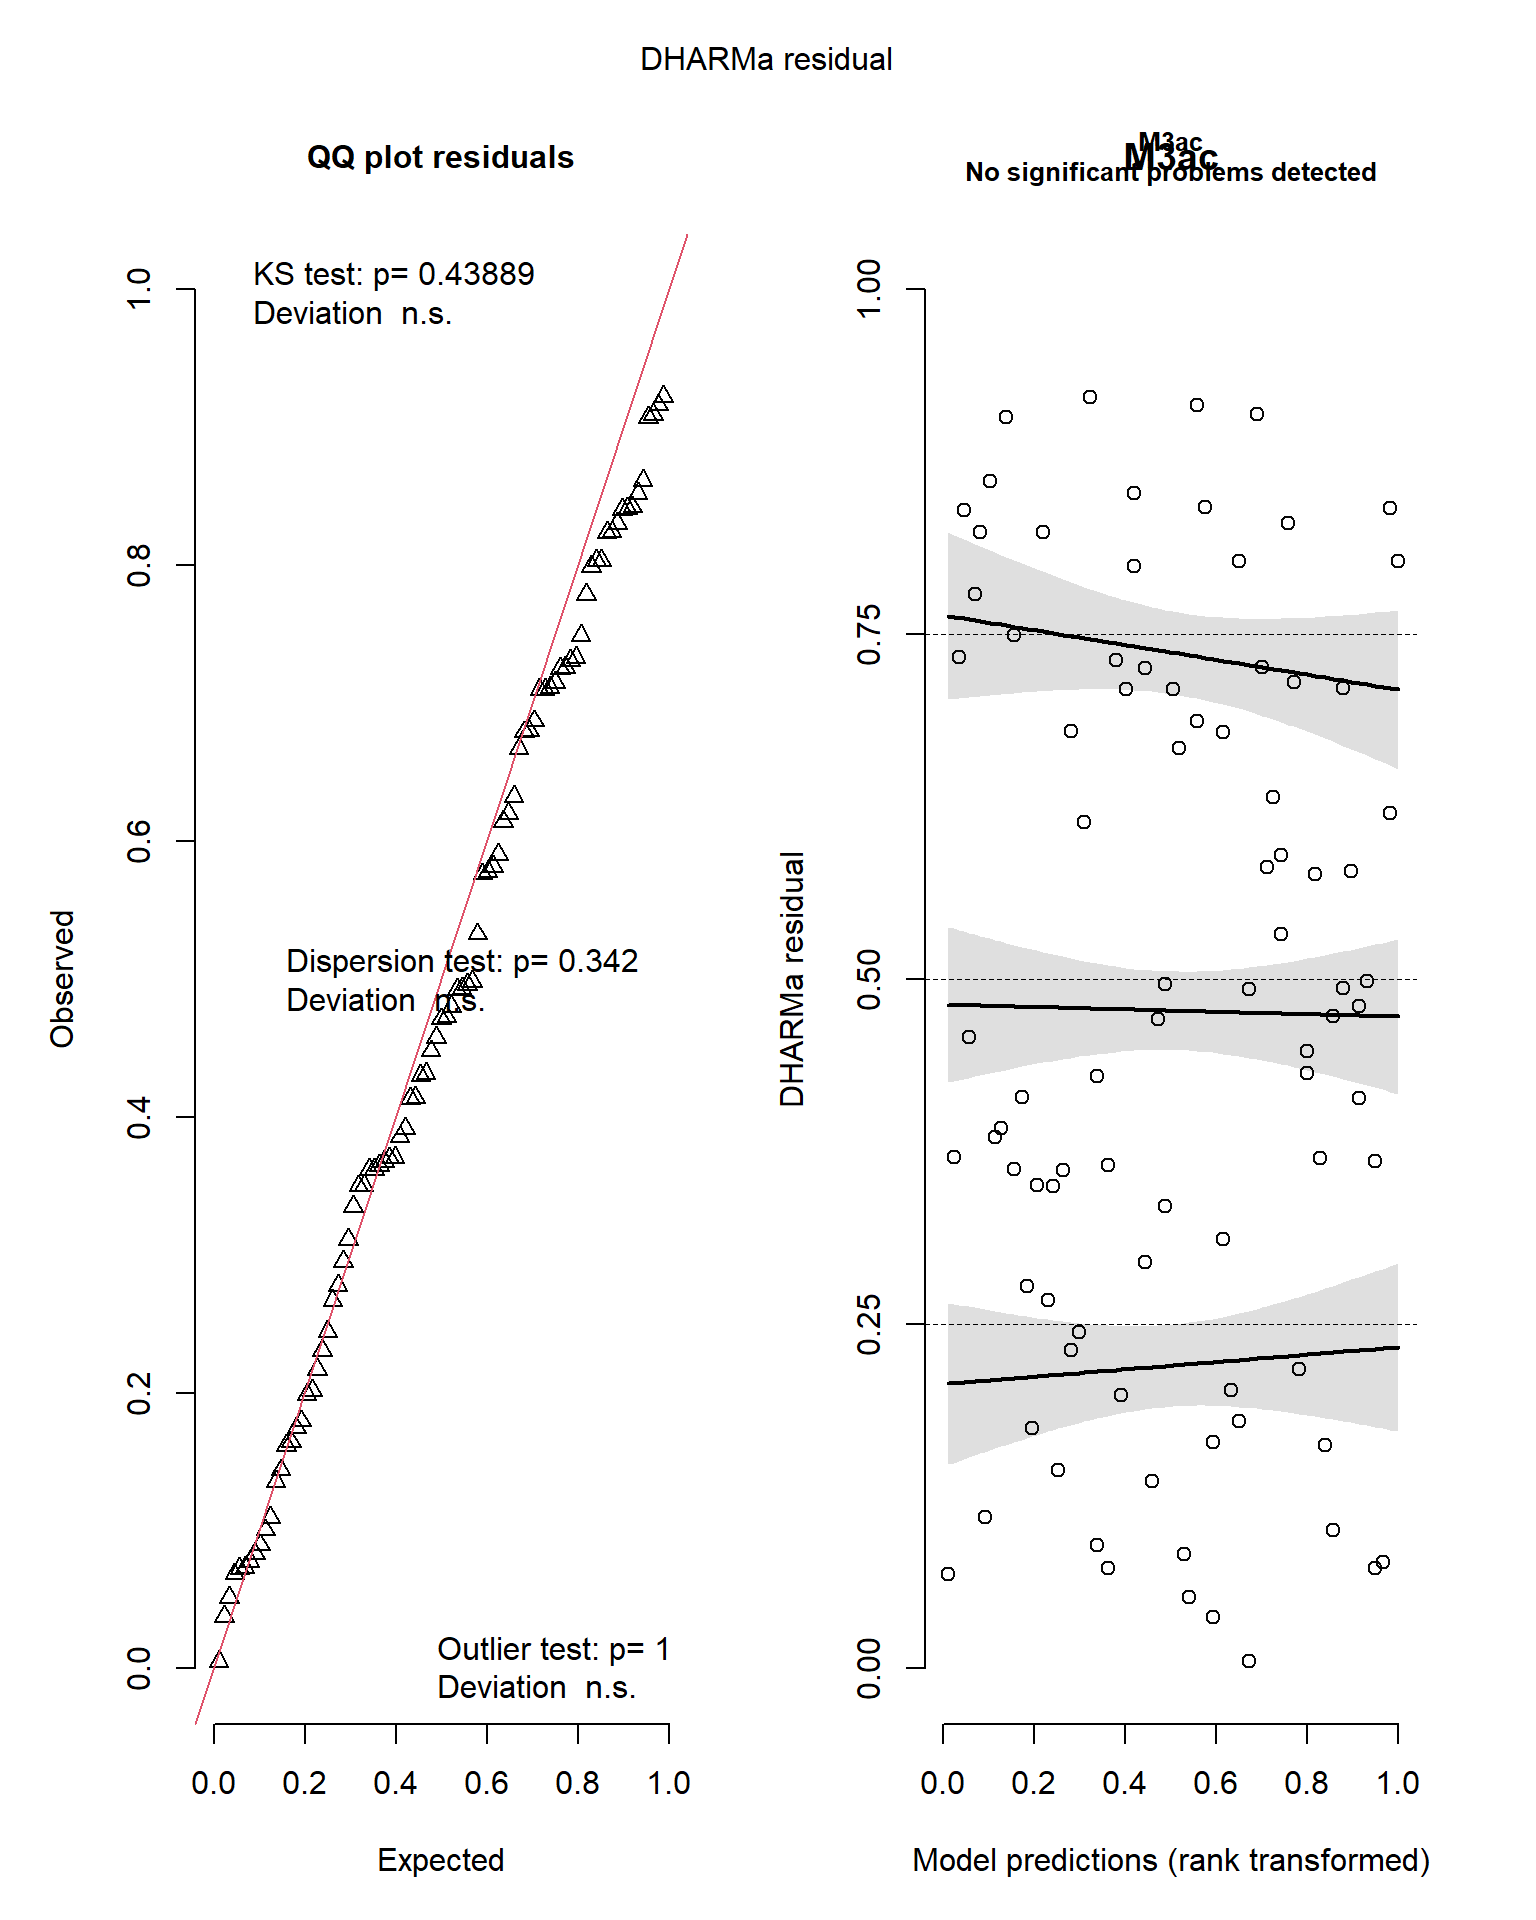

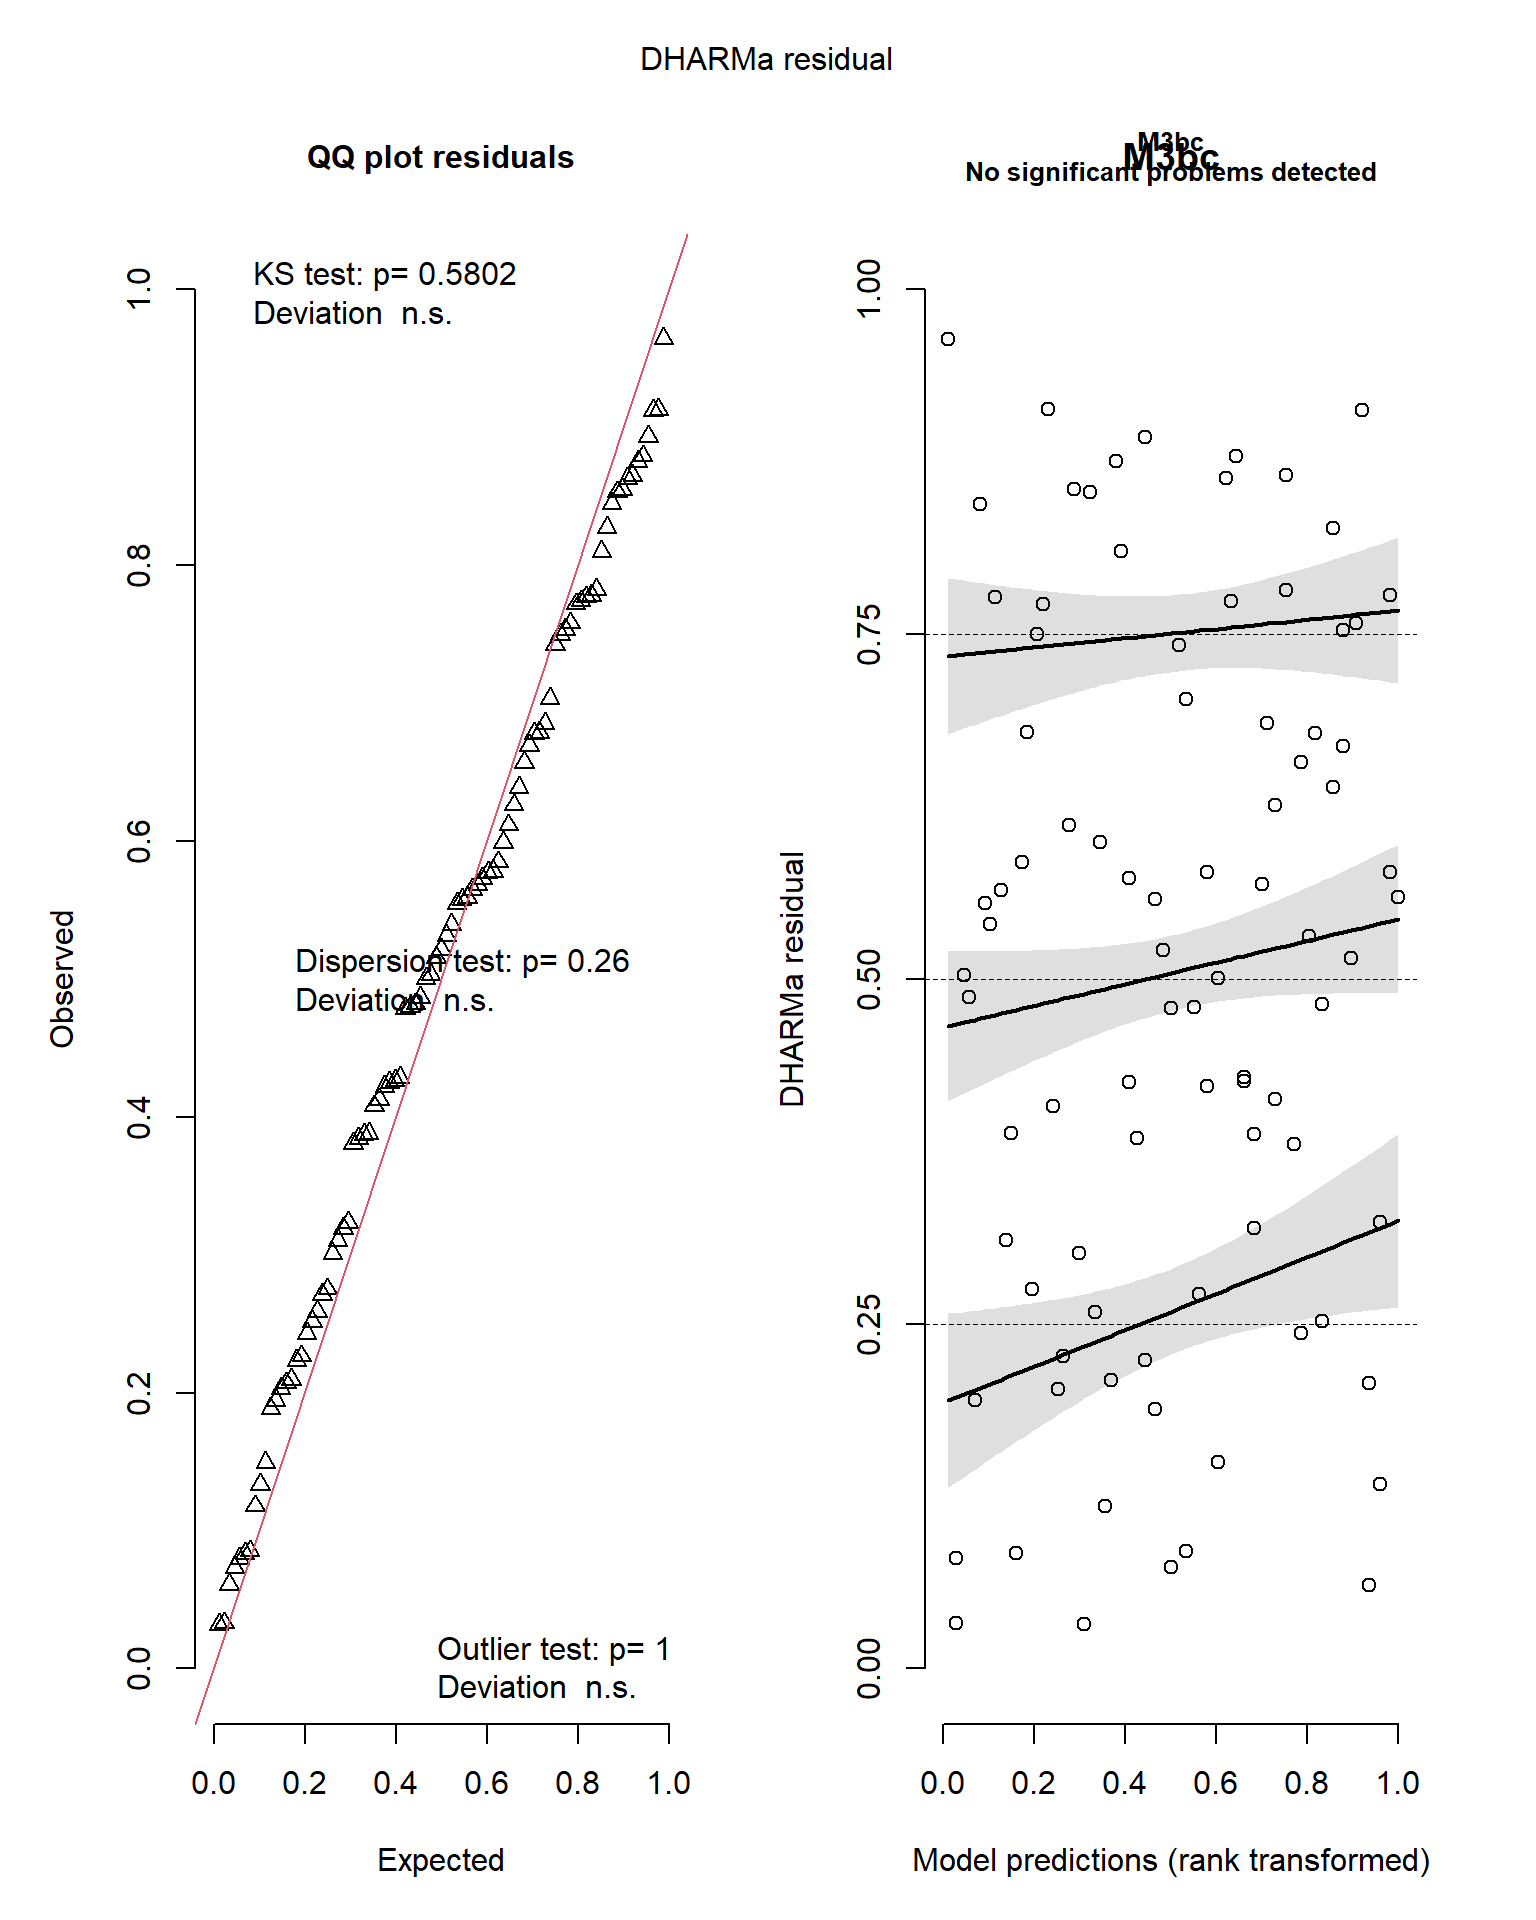

In [ ]:

model_registry <- dplyr::bind_rows(rq1_results, rq2_results, rq3_results) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame, term_of_interest, p_adj_BH, model)

diagnostic_models <- purrr::set_names(model_registry$model, model_registry$model_id) %>%
  purrr::compact()

simulate_check <- function(model, name, seed = 42) {
  sim <- DHARMa::simulateResiduals(model, n = 1000, seed = seed)
  plot(sim, main = name)
  sim
}

dharma_sims <- purrr::imap(diagnostic_models, simulate_check)


### Residual diagnostics summary table

In [ ]:

dharma_tests <- purrr::imap_dfr(dharma_sims, function(sim, name) {
  tibble(
    Model           = name,
    Uniformity_p    = DHARMa::testUniformity(sim, plot = FALSE)$p.value,
    Dispersion_p    = DHARMa::testDispersion(sim, plot = FALSE)$p.value,
    Outlier_p       = DHARMa::testOutliers(sim, plot = FALSE)$p.value)
}) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(dharma_tests)

write.csv(dharma_tests, file.path(out_dir, "tbl-residual-diagnostics.csv"), row.names = FALSE)


  Model     Uniformity_p   Dispersion_p   Outlier_p
  ------- -------------- -------------- -----------
  M1ok             0.115          0.972           1
  M1ak             0.791          0.912           1
  M1bk             0.453          0.810           1
  M1oc             0.504          0.700           1
  M1ac             0.646          0.966           1
  M1bc             0.546          0.406           1
  M2ak             0.326          0.736           1
  M2bk             0.633          0.720           1
  M2ac             0.575          0.222           1
  M2bc             0.400          0.186           1
  M3ak             0.856          0.626           1
  M3bk             0.972          0.602           1
  M3ac             0.439          0.342           1
  M3bc             0.580          0.260           1


# Model results

## Question structure reference table

In [ ]:

question_structure <- model_registry %>%
  dplyr::distinct(RQ, response_type, comparison, time_frame, term_of_interest) %>%
  dplyr::mutate(
    family = dplyr::if_else(response_type == "occupancy", "binomial", "tweedie"),
    data = dplyr::case_when(
      comparison == "vs_control" & time_frame == "full" ~ "baci_data",
      comparison == "vs_control" & time_frame == "post" ~ "baci_data_after",
      comparison == "vs_reference"                      ~ "convergence_data"),
    formula = dplyr::case_when(
      comparison == "vs_control" & time_frame == "full" ~
        "<response> ~ Period * site + monitoring_int + Temperature + (1 | pair_id / site_id)",
      comparison == "vs_control" & time_frame == "post" ~
        "<response> ~ site * monitoring_int + Temperature + Substrate_index_before + (1 | site_id)",
      comparison == "vs_reference" ~
        "<response> ~ site * monitoring_int + Season + Substrate_index_after + (1 | site_id)")) %>%
  dplyr::arrange(RQ, response_type) %>%
  dplyr::select(RQ, response_type, comparison, time_frame, family, data, formula, term_of_interest)

write.csv(question_structure, file.path(out_dir, "tbl-question-structure.csv"), row.names = FALSE)

knitr::kable(question_structure)


  --------------------------------------------------------------------------------------------------------------------------------------------------
  RQ    response_type   comparison     time_frame   family     data               formula                            term_of_interest
  ----- --------------- -------------- ------------ ---------- ------------------ ---------------------------------- -------------------------------
  RQ1   abundance       vs_control     full         tweedie    baci_data          `<response>`{=html} \~ Period \*   PeriodAfter:siteStone_pile
                                                                                  site + monitoring_int +            
                                                                                  Temperature + (1 \| pair_id /      
                                                                                  site_id)                           

  RQ1   biomass         vs_control     full         tweedie    baci_data          `<response>`{=html} \~ Period \*   PeriodAfter:siteStone_pile
                                                                                  site + monitoring_int +            
                                                                                  Temperature + (1 \| pair_id /      
                                                                                  site_id)                           

  RQ1   occupancy       vs_control     full         binomial   baci_data          `<response>`{=html} \~ Period \*   PeriodAfter:siteStone_pile
                                                                                  site + monitoring_int +            
                                                                                  Temperature + (1 \| pair_id /      
                                                                                  site_id)                           

  RQ2   abundance       vs_control     post         tweedie    baci_data_after    `<response>`{=html} \~ site \*     siteStone_pile:monitoring_int
                                                                                  monitoring_int + Temperature +     
                                                                                  Substrate_index_before + (1 \|     
                                                                                  site_id)                           

  RQ2   biomass         vs_control     post         tweedie    baci_data_after    `<response>`{=html} \~ site \*     siteStone_pile:monitoring_int
                                                                                  monitoring_int + Temperature +     
                                                                                  Substrate_index_before + (1 \|     
                                                                                  site_id)                           

  RQ3   abundance       vs_reference   full         tweedie    convergence_data   `<response>`{=html} \~ site \*     siteStone_pile:monitoring_int
                                                                                  monitoring_int + Season +          
                                                                                  Substrate_index_after + (1 \|      
                                                                                  site_id)                           

  RQ3   biomass         vs_reference   full         tweedie    convergence_data   `<response>`{=html} \~ site \*     siteStone_pile:monitoring_int
                                                                                  monitoring_int + Season +          
                                                                                  Substrate_index_after + (1 \|      
                                                                                  site_id)                           
  --------------------------------------------------------------------------------------------------------------------------------------------------


## Models summary table

``` r

tidy_all <- model_registry %>%
  dplyr::mutate(tidy = purrr::map2(model, term_of_interest, function(m, trm) {
    if (is.null(m)) return(NULL)
    broom.mixed::tidy(m, effects = "fixed", conf.int = TRUE) %>%
      dplyr::filter(term == trm)
  })) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame,
                term, estimate, std.error, statistic, p.value, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

tidy_all
```

    # A tibble: 14 × 13
       model_id RQ    species response_type comparison   time_frame term    estimate
       <chr>    <chr> <chr>   <chr>         <chr>        <chr>      <chr>      <dbl>
     1 M1ok     RQ1   Kōura   occupancy     vs_control   full       Period…    1.81 
     2 M1ak     RQ1   Kōura   abundance     vs_control   full       Period…    0.283
     3 M1bk     RQ1   Kōura   biomass       vs_control   full       Period…   -0.426
     4 M1oc     RQ1   Catfish occupancy     vs_control   full       Period…    0.426
     5 M1ac     RQ1   Catfish abundance     vs_control   full       Period…    1.40 
     6 M1bc     RQ1   Catfish biomass       vs_control   full       Period…    4.95 
     7 M2ak     RQ2   Kōura   abundance     vs_control   post       siteSt…    0.322
     8 M2bk     RQ2   Kōura   biomass       vs_control   post       siteSt…    0.448
     9 M2ac     RQ2   Catfish abundance     vs_control   post       siteSt…    1.30 
    10 M2bc     RQ2   Catfish biomass       vs_control   post       siteSt…    2.43 
    11 M3ak     RQ3   Kōura   abundance     vs_reference full       siteSt…    0.203
    12 M3bk     RQ3   Kōura   biomass       vs_reference full       siteSt…    0.239
    13 M3ac     RQ3   Catfish abundance     vs_reference full       siteSt…    0.34 
    14 M3bc     RQ3   Catfish biomass       vs_reference full       siteSt…    1.22 
    # ℹ 5 more variables: std.error <dbl>, statistic <dbl>, p.value <dbl>,
    #   conf.low <dbl>, conf.high <dbl>

## Full fixed-effects table

``` r

tidy_all_full <- model_registry %>%
  dplyr::mutate(tidy = purrr::map(model, function(m) {
    if (is.null(m)) return(NULL)
    broom.mixed::tidy(m, effects = "fixed", conf.int = TRUE)
  })) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  # p_adj_BH only applies to each model's own term of interest — NA elsewhere.
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame,
                term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

write.csv(tidy_all_full, file.path(out_dir, "tbl-models-summary-full.csv"), row.names = FALSE)

tidy_all_full
```

    # A tibble: 92 × 14
       model_id RQ    species response_type comparison time_frame term      estimate
       <chr>    <chr> <chr>   <chr>         <chr>      <chr>      <chr>        <dbl>
     1 M1ok     RQ1   Kōura   occupancy     vs_control full       (Interce…   -8.03 
     2 M1ok     RQ1   Kōura   occupancy     vs_control full       PeriodAf…    4.17 
     3 M1ok     RQ1   Kōura   occupancy     vs_control full       siteSton…    0.017
     4 M1ok     RQ1   Kōura   occupancy     vs_control full       monitori…   -0.218
     5 M1ok     RQ1   Kōura   occupancy     vs_control full       Temperat…    0.292
     6 M1ok     RQ1   Kōura   occupancy     vs_control full       PeriodAf…    1.81 
     7 M1ak     RQ1   Kōura   abundance     vs_control full       (Interce…   -1.52 
     8 M1ak     RQ1   Kōura   abundance     vs_control full       PeriodAf…    1.66 
     9 M1ak     RQ1   Kōura   abundance     vs_control full       siteSton…    0.702
    10 M1ak     RQ1   Kōura   abundance     vs_control full       monitori…   -0.09 
    # ℹ 82 more rows
    # ℹ 6 more variables: std.error <dbl>, statistic <dbl>, p.value <dbl>,
    #   p_adj_BH <dbl>, conf.low <dbl>, conf.high <dbl>

## All models summary plot

ℹ Please use the `orientation` argument of `geom_errorbar()` instead.

`height` was translated to `width`.

`height` was translated to `width`.

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

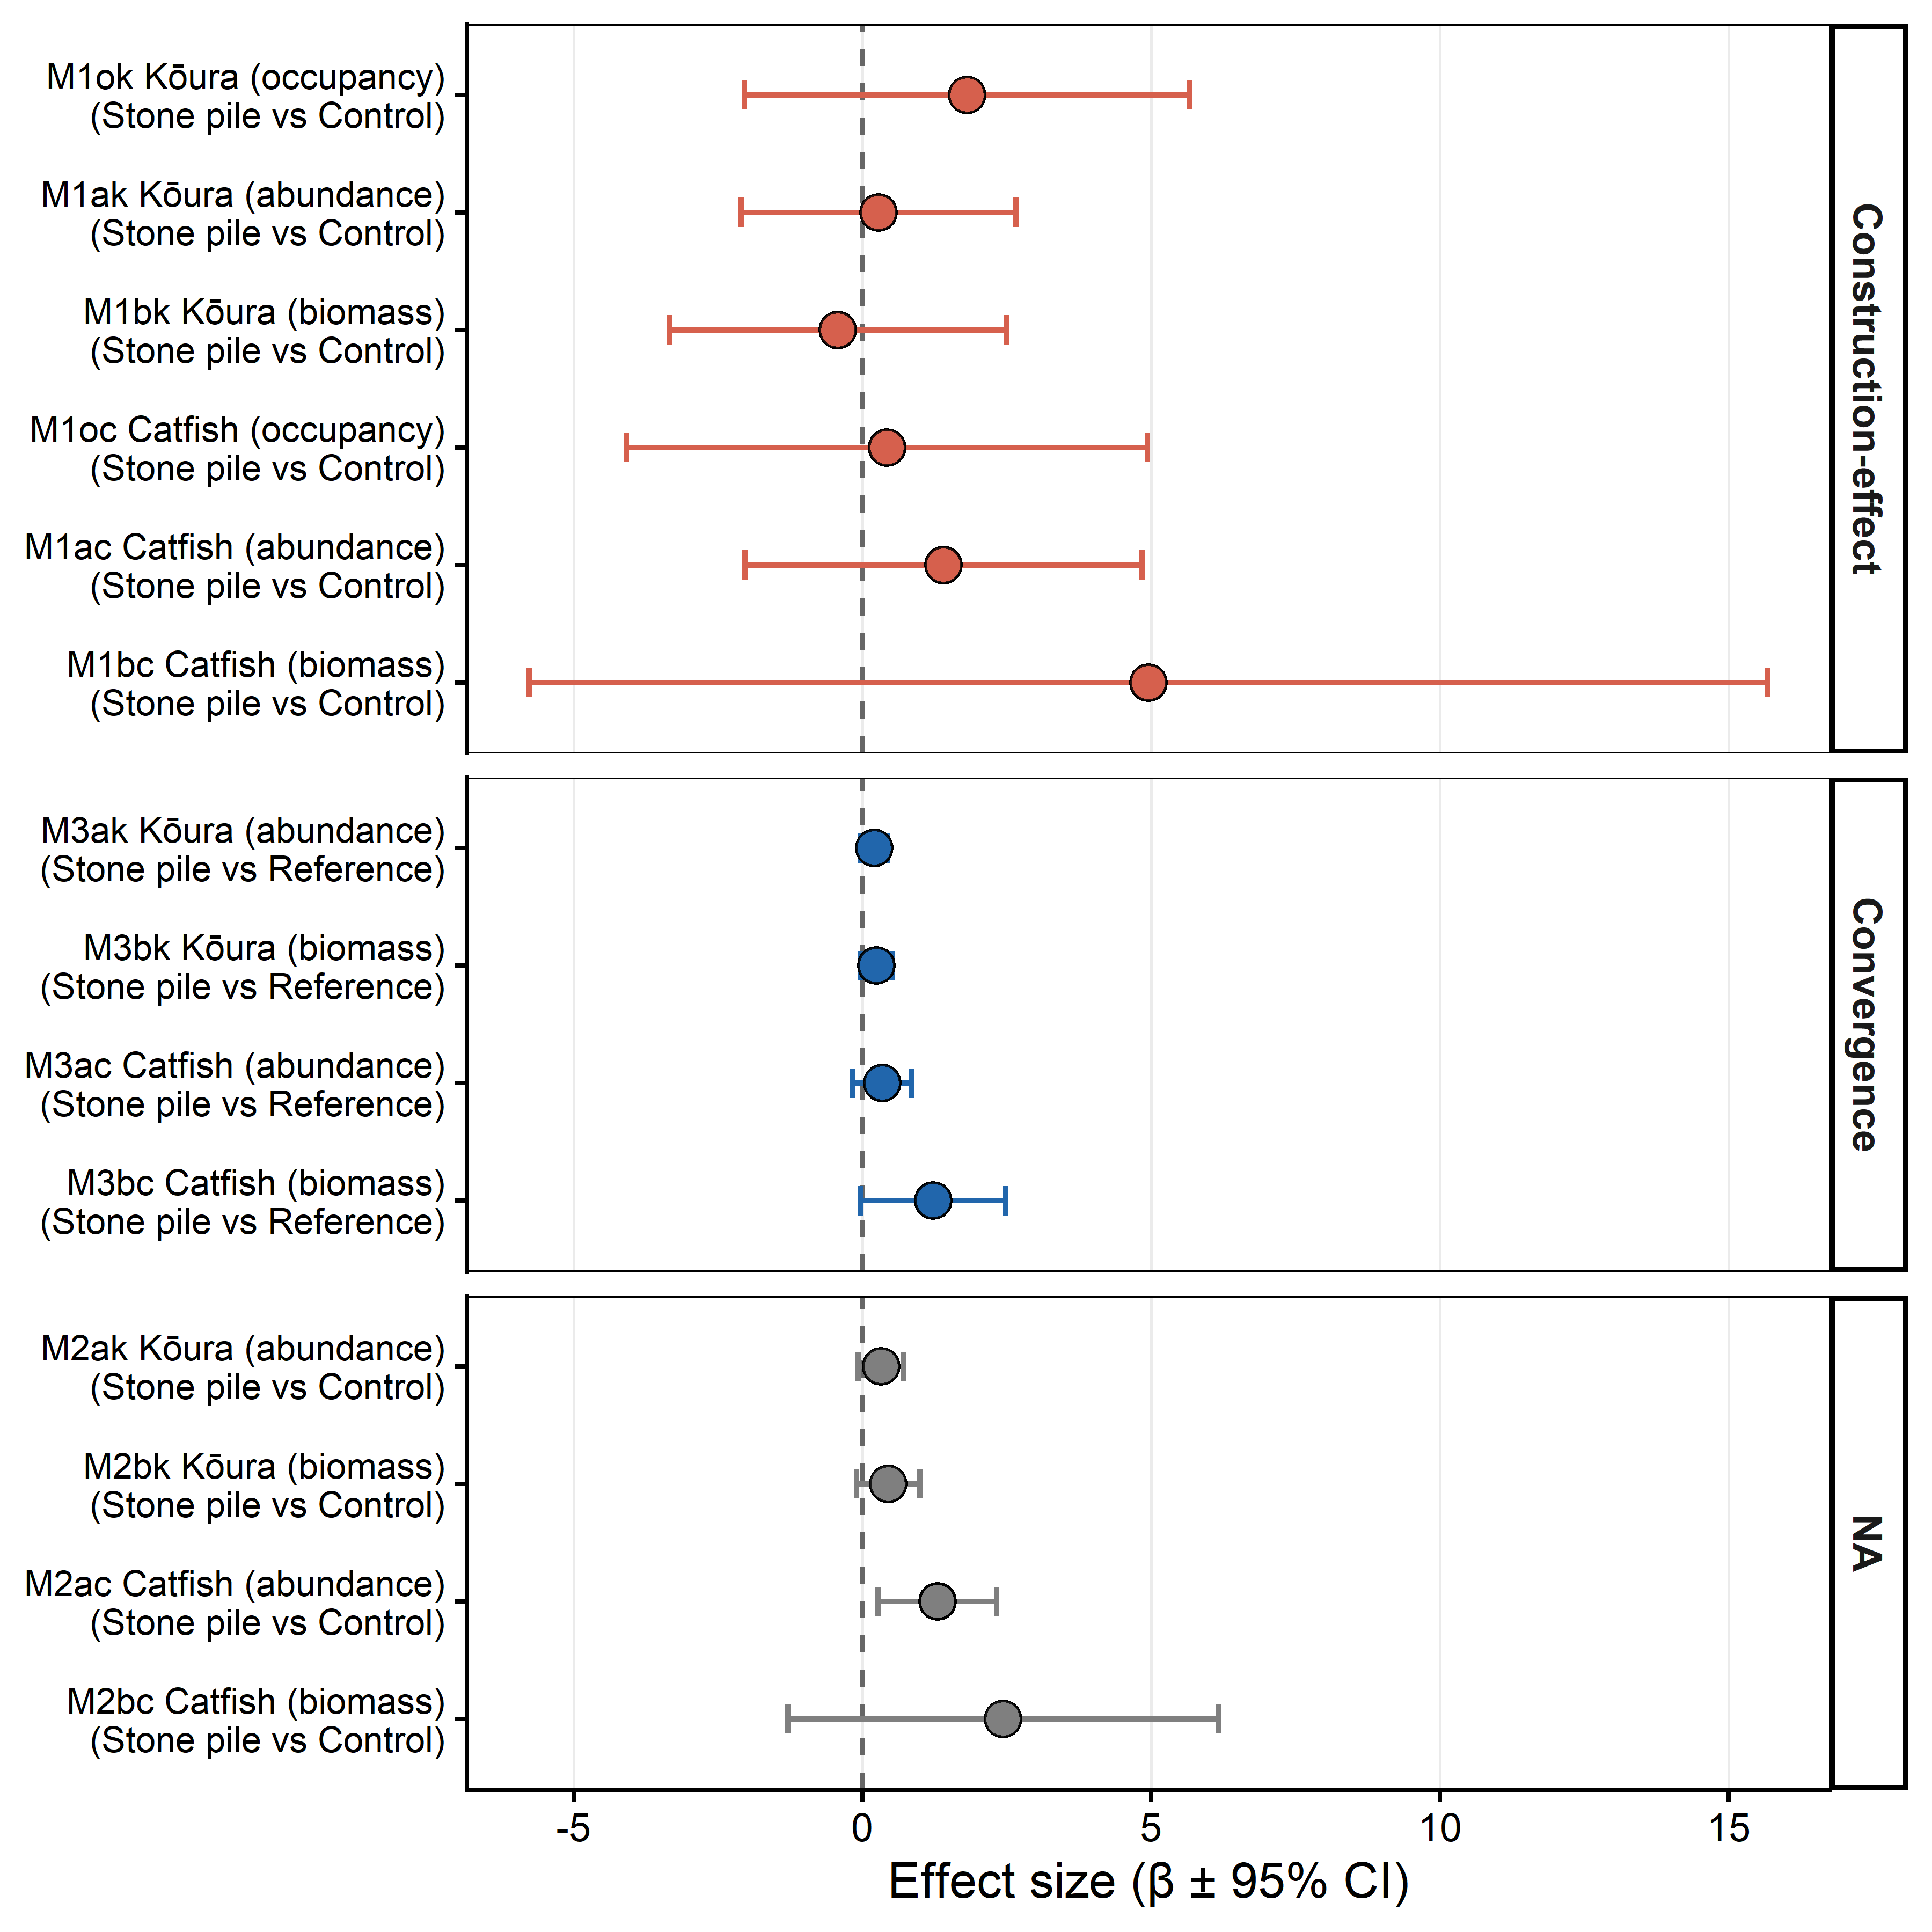

In [ ]:

# Built directly from tidy_all
forest_data <- tidy_all %>%
  dplyr::mutate(
    model_name = paste0(model_id, " ", species, " (", response_type, ")\n(Stone pile vs ",
             dplyr::if_else(comparison == "vs_control", "Control", "Reference"), ")"),
    group = dplyr::case_when(
      comparison == "vs_reference"     ~ "Convergence",
      time_frame == "post"             ~ "Post-construction trend",
      TRUE                              ~ "Construction-effect"),
    significant = p.value < 0.05,
    model_name  = factor(model_name, levels = rev(unique(model_name))),
    group       = factor(group, levels = c("Construction-effect", "Trend", "Convergence")))

group_colours <- c("Construction-effect"     = "#d6604d",
                   "Post-construction trend" = "#b8860b",
                   "Convergence"             = "#2166ac")

forest_plot <- ggplot(forest_data,
    aes(estimate, model_name)) +
  geom_vline(xintercept = 0, linetype = "dashed",
             colour = "grey40", linewidth = 0.5) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high,
                     colour = group),
                 height = 0.25, linewidth = 0.6) +
  # All points — coloured fill, black outline
  geom_point(aes(fill = group),
             colour = "black", shape = 21,
             size = 3.5, stroke = 0.5) +
  # Overlay faded layer for non-significant
  geom_point(data = forest_data %>% filter(!significant),
             aes(fill = group),
             colour = "black", shape = 21,
             size = 3.5, stroke = 0.5, alpha = 0.25) +
  scale_fill_manual(  values = group_colours) +
  scale_colour_manual(values = group_colours) +
  facet_grid(group ~ ., scales = "free_y", space = "free_y") +
  labs(
    x      = "Effect size (β ± 95% CI)",
    y      = NULL,
    fill   = "Model group",
    colour = "Model group") +
  theme(
    strip.text         = element_text(size = 9, face = "bold"),
    axis.text.y        = element_text(size = 8),
    legend.position    = "none",
    panel.grid.major.x = element_line(colour = "grey92", linewidth = 0.3))


# Additional and sensitivity models

## Check various additional models

In [ ]:

# test the effect of koura length.
m_size <- lmerTest::lmer(
  Mean_Length_Kōura ~  site * monitoring_int + (1 | site_id),
  data = all_data %>% filter(!is.na(Mean_Length_Kōura)))

# Data-quality sensitivity check
quality_sensitivity_check <- function(results, data_obj) {
  purrr::pmap_dfr(results, function(model_id, term_of_interest, model, ...) {
    if (is.null(model)) return(NULL)
    dat_sens <- data_obj %>% dplyr::filter(monitoring_quality == "complete")
    m_sens <- tryCatch(update(model, data = dat_sens), error = function(e) NULL)
    orig <- broom.mixed::tidy(model, effects = "fixed") %>%
      dplyr::filter(term == term_of_interest) %>%
      dplyr::mutate(model_id = model_id, version = "All data")
    if (is.null(m_sens)) return(orig)
    sens <- broom.mixed::tidy(m_sens, effects = "fixed") %>%
      dplyr::filter(term == term_of_interest)
    if (nrow(sens) == 0 || is.na(sens$std.error) || sens$std.error <= 0) return(orig)
    sens <- sens %>% dplyr::mutate(model_id = model_id, version = "Complete quality only")
    dplyr::bind_rows(orig, sens)
  })
}

quality_sensitivity_all <- dplyr::bind_rows(
  quality_sensitivity_check(rq1_results, baci_data),
  quality_sensitivity_check(rq2_results, baci_data_after),
  quality_sensitivity_check(rq3_results, convergence_data)) %>%
  dplyr::select(model_id, version, term, estimate, std.error, statistic, p.value) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))


Warning in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old): Model convergence
problem; false convergence (8). See vignette('troubleshooting'),
help('diagnose')

  -------------------------------------------------------------------------------------------------------
  model_id   version         term                              estimate   std.error   statistic   p.value
  ---------- --------------- ------------------------------- ---------- ----------- ----------- ---------
  M1ok       All data        PeriodAfter:siteStone_pile           1.814       1.968       0.922     0.357

  M1ok       Complete        PeriodAfter:siteStone_pile           5.986       4.492       1.333     0.183
             quality only                                                                       

  M1ak       All data        PeriodAfter:siteStone_pile           0.283       1.214       0.233     0.816

  M1ak       Complete        PeriodAfter:siteStone_pile           0.268       1.171       0.229     0.819
             quality only                                                                       

  M1bk       All data        PeriodAfter:siteStone_pile          -0.426       1.487      -0.287     0.774

  M1bk       Complete        PeriodAfter:siteStone_pile          -0.447       1.494      -0.299     0.765
             quality only                                                                       

  M1oc       All data        PeriodAfter:siteStone_pile           0.426       2.302       0.185     0.853

  M1oc       Complete        PeriodAfter:siteStone_pile           0.383       2.387       0.160     0.872
             quality only                                                                       

  M1ac       All data        PeriodAfter:siteStone_pile           1.403       1.753       0.800     0.424

  M1bc       All data        PeriodAfter:siteStone_pile           4.954       5.473       0.905     0.365

  M1bc       Complete        PeriodAfter:siteStone_pile           5.145       5.903       0.872     0.383
             quality only                                                                       

  M2ak       All data        siteStone_pile:monitoring_int        0.322       0.202       1.593     0.111

  M2ak       Complete        siteStone_pile:monitoring_int        0.263       0.189       1.396     0.163
             quality only                                                                       

  M2bk       All data        siteStone_pile:monitoring_int        0.448       0.280       1.601     0.109

  M2bk       Complete        siteStone_pile:monitoring_int        0.375       0.286       1.309     0.191
             quality only                                                                       

  M2ac       All data        siteStone_pile:monitoring_int        1.298       0.525       2.471     0.013

  M2ac       Complete        siteStone_pile:monitoring_int        1.042       0.713       1.462     0.144
             quality only                                                                       

  M2bc       All data        siteStone_pile:monitoring_int        2.434       1.903       1.279     0.201

  M2bc       Complete        siteStone_pile:monitoring_int        4.327       6.637       0.652     0.514
             quality only                                                                       

  M3ak       All data        siteStone_pile:monitoring_int        0.203       0.115       1.761     0.078

  M3ak       Complete        siteStone_pile:monitoring_int        0.210       0.112       1.878     0.060
             quality only                                                                       

  M3bk       All data        siteStone_pile:monitoring_int        0.239       0.139       1.718     0.086

  M3bk       Complete        siteStone_pile:monitoring_int        0.246       0.139       1.768     0.077
             quality only                                                                       

  M3ac       All data        siteStone_pile:monitoring_int        0.340       0.263       1.293     0.196

  M3ac       Complete        siteStone_pile:monitoring_int        0.339       0.263       1.286     0.198
             quality only                                                                       

  M3bc       All data        siteStone_pile:monitoring_int        1.223       0.642       1.905     0.057

  M3bc       Complete        siteStone_pile:monitoring_int        1.211       0.641       1.891     0.059
             quality only                                                                       
  -------------------------------------------------------------------------------------------------------


  ---------------------------------------------------------------------------------------------------
  species   response_type   term                           estimate   std.error   statistic   p.value
  --------- --------------- ---------------------------- ---------- ----------- ----------- ---------
  Kōura     occupancy       PeriodAfter:siteStone_pile        0.981       1.936       0.506     0.613

  Kōura     abundance       PeriodAfter:siteStone_pile        0.693       1.259       0.551     0.582

  Kōura     biomass         PeriodAfter:siteStone_pile       -0.187       1.360      -0.137     0.891

  Catfish   occupancy       PeriodAfter:siteStone_pile        0.981       2.141       0.458     0.647

  Catfish   abundance       PeriodAfter:siteStone_pile        3.332       2.451       1.360     0.174

  Catfish   biomass         PeriodAfter:siteStone_pile        7.370       3.548       2.077     0.038
  ---------------------------------------------------------------------------------------------------


  ----------------------------------------------------------------------------------------------------------------
  model_id   version                  term                              estimate   std.error   statistic   p.value
  ---------- ------------------------ ------------------------------- ---------- ----------- ----------- ---------
  M2ak       With                     Substrate_index_before               0.785       0.563       1.395     0.163
             Substrate_index_before                                                                      

  M2ak       With                     siteStone_pile:monitoring_int        0.322       0.202       1.593     0.111
             Substrate_index_before                                                                      

  M2ak       Without                  siteStone_pile:monitoring_int        0.317       0.202       1.570     0.116
             Substrate_index_before                                                                      

  M2bk       With                     Substrate_index_before               0.607       0.494       1.230     0.219
             Substrate_index_before                                                                      

  M2bk       With                     siteStone_pile:monitoring_int        0.448       0.280       1.601     0.109
             Substrate_index_before                                                                      

  M2bk       Without                  siteStone_pile:monitoring_int        0.434       0.279       1.552     0.121
             Substrate_index_before                                                                      

  M2ac       With                     Substrate_index_before              -0.986       1.051      -0.938     0.348
             Substrate_index_before                                                                      

  M2ac       With                     siteStone_pile:monitoring_int        1.298       0.525       2.471     0.013
             Substrate_index_before                                                                      

  M2ac       Without                  siteStone_pile:monitoring_int        1.293       0.524       2.467     0.014
             Substrate_index_before                                                                      

  M2bc       With                     Substrate_index_before              -0.183       2.053      -0.089     0.929
             Substrate_index_before                                                                      

  M2bc       With                     siteStone_pile:monitoring_int        2.434       1.903       1.279     0.201
             Substrate_index_before                                                                      

  M2bc       Without                  siteStone_pile:monitoring_int        2.153       1.513       1.423     0.155
             Substrate_index_before                                                                      

  M3ak       With                     Substrate_index_after                0.626       0.420       1.489     0.137
             Substrate_index_after                                                                       

  M3ak       With                     siteStone_pile:monitoring_int        0.203       0.115       1.761     0.078
             Substrate_index_after                                                                       

  M3ak       Without                  siteStone_pile:monitoring_int        0.217       0.115       1.883     0.060
             Substrate_index_after                                                                       

  M3bk       With                     Substrate_index_after                0.406       0.380       1.067     0.286
             Substrate_index_after                                                                       

  M3bk       With                     siteStone_pile:monitoring_int        0.239       0.139       1.718     0.086
             Substrate_index_after                                                                       

  M3bk       Without                  siteStone_pile:monitoring_int        0.245       0.139       1.764     0.078
             Substrate_index_after                                                                       

  M3ac       With                     Substrate_index_after                0.486       0.662       0.734     0.463
             Substrate_index_after                                                                       

  M3ac       With                     siteStone_pile:monitoring_int        0.340       0.263       1.293     0.196
             Substrate_index_after                                                                       

  M3ac       Without                  siteStone_pile:monitoring_int        0.359       0.260       1.381     0.167
             Substrate_index_after                                                                       

  M3bc       With                     Substrate_index_after                0.571       1.054       0.541     0.588
             Substrate_index_after                                                                       

  M3bc       With                     siteStone_pile:monitoring_int        1.223       0.642       1.905     0.057
             Substrate_index_after                                                                       

  M3bc       Without                  siteStone_pile:monitoring_int        1.248       0.647       1.929     0.054
             Substrate_index_after                                                                       
  ----------------------------------------------------------------------------------------------------------------


  model_id     Season_AICc   Temperature_AICc   delta_AICc
  ---------- ------------- ------------------ ------------
  M3ak               321.5              323.4          1.9
  M3bk               704.2              706.7          2.5
  M3ac               145.7              153.2          7.5
  M3bc               391.6              395.4          3.8


### Colonisation drivers — what explains the colonisation pattern?

In [ ]:

M3ak_complete_vars <- c("Weighted_CPUE_Kōura",
 "Temperature", "DO_mgl", "pH", "Specific_conductivity",
 "Substrate_index_after", "lunar_illumination",  "Season",
 "log_cpue_catfish")

convergence_data_complete <- convergence_data %>%
  filter(dplyr::if_all(dplyr::all_of(M3ak_complete_vars), ~ !is.na(.)))

# Refit base model with ML for comparison
M3ak_base <- update(M3ak, data = convergence_data_complete, REML = FALSE)

# Linear vs quadratic trajectory
M3ak_quad <- update(M3ak_base, . ~ . - monitoring_int - site:monitoring_int + poly(monitoring_int, 2) * site)
anova(M3ak_base, M3ak_quad)


Data: convergence_data_complete
Models:
M3ak_base: Weighted_CPUE_Kōura ~ site * monitoring_int + Season + Substrate_index_after + , zi=~0, disp=~1
M3ak_base:     (1 | site_id), zi=~0, disp=~1
M3ak_quad: Weighted_CPUE_Kōura ~ site + Season + Substrate_index_after + , zi=~0, disp=~1
M3ak_quad:     (1 | site_id) + poly(monitoring_int, 2) + site:poly(monitoring_int, , zi=~0, disp=~1
M3ak_quad:     2), zi=~0, disp=~1
          Df    AIC    BIC  logLik deviance  Chisq Chi Df Pr(>Chisq)  
M3ak_base 11 309.00 336.12 -143.50   287.00                           
M3ak_quad 13 306.24 338.29 -140.12   280.24 6.7592      2    0.03406 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

  Model                                              K    AICc   ΔAICc
  ----------------------------------------------- ---- ------- -------
  Base (site × time + Season + Substrate index)     11   312.5    0.00
  Base + Temperature                                12   313.6    1.05
  Base + Catfish CPUE                               12   313.7    1.19
  Base + pH                                         12   314.0    1.45
  Base + Dissolved oxygen                           12   314.0    1.52
  Base + Lunar illumination                         12   314.6    2.07
  Base + Specific conductivity                      12   315.2    2.69
  Base + Lunar + Catfish CPUE                       13   315.4    2.93


# Session info

In [ ]:
sessionInfo()


R version 4.5.2 (2025-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26100)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_New Zealand.utf8  LC_CTYPE=English_New Zealand.utf8   
[3] LC_MONETARY=English_New Zealand.utf8 LC_NUMERIC=C                        
[5] LC_TIME=English_New Zealand.utf8    

time zone: Pacific/Auckland
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] readxl_1.4.5        writexl_1.5.4       lubridate_1.9.5    
 [4] forcats_1.0.1       stringr_1.6.0       dplyr_1.2.0        
 [7] purrr_1.2.1         readr_2.2.0         tidyr_1.3.2        
[10] tibble_3.3.1        ggplot2_4.0.2       tidyverse_2.0.0    
[13] patchwork_1.3.2     lmerTest_3.2-1      lme4_1.1-38        
[16] Matrix_1.7-4        emmeans_2.0.2       broom.mixed_0.2.9.7
[19] DHARMa_0.4.7        glmmTMB_1.1.14      lunar_0.2-1        


```` markdown
---
title: "Analysis Notebook"
format:
  html:
    fig-path: "analysis_files/figure-html/"
    theme:
      light: flatly
      dark: darkly
    code-fold: true
    code-tools: true
    code-summary: "View Code"
    toc: true
    toc-depth: 3
    number-sections: true
fig-width: 8
fig-height: 6

execute:
  freeze: false
  cache: false

---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
#| include: false

packages <- c("MuMIn","lunar","glmmTMB","DHARMa","broom.mixed","emmeans","lmerTest","lme4","patchwork","tidyverse","writexl","readxl")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))
  }
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)
}

options(repos = c(CRAN = "https://cloud.r-project.org"))
invisible(lapply(packages, quiet_load))

exc_file_dir  <- "data/raw/Data_Stone_piles_Rotoiti.xlsx"
raw_data_dir  <- "data/raw"
der_data_dir  <- "data/derived"
out_dir       <- "outputs"

# Read data
Site_info          <- readxl::read_excel(exc_file_dir, sheet = "Site_info")
Monitoring_data    <- readxl::read_excel(exc_file_dir, sheet = "Monitoring_data")
Chemical_data      <- readxl::read_excel(exc_file_dir, sheet = "Chemical_data")
Stone_pile_data    <- readxl::read_excel(exc_file_dir, sheet = "Stone_pile_data")  %>% select(-starts_with("..."))
Weed_data          <- readxl::read_excel(exc_file_dir, sheet = "Weed_data")  %>% select(-starts_with("..."))
Fish_data          <- readxl::read_excel(exc_file_dir, sheet = "Fish_data")  %>% select(-starts_with("..."))
Macroinvertebrates <- readxl::read_excel(exc_file_dir, sheet = "Macroinvertebrates")

# Save as csv to derived
write.csv(Site_info,          file.path(der_data_dir, "Site_info.csv"),          row.names = FALSE)
write.csv(Monitoring_data,    file.path(der_data_dir, "Monitoring_data.csv"),    row.names = FALSE)
write.csv(Chemical_data,      file.path(der_data_dir, "Chemical_data.csv"),      row.names = FALSE)
write.csv(Stone_pile_data,    file.path(der_data_dir, "Stone_pile_data.csv"),    row.names = FALSE)
write.csv(Weed_data,          file.path(der_data_dir, "Weed_data.csv"),          row.names = FALSE)
write.csv(Fish_data,          file.path(der_data_dir, "Fish_data.csv"),          row.names = FALSE)
write.csv(Macroinvertebrates, file.path(der_data_dir, "Macroinvertebrates.csv"), row.names = FALSE)

### Reproducibility note 
# The sections above require data/raw/Natural_habitat.xlsx (not tracked).
# To reproduce analyses and figures without the raw Excel file,
# run from here using the derived CSVs in data/derived/:

Site_info          <- read.csv(file.path(der_data_dir, "Site_info.csv"))
Monitoring_data    <- read.csv(file.path(der_data_dir, "Monitoring_data.csv"))
Chemical_data      <- read.csv(file.path(der_data_dir, "Chemical_data.csv"))
Stone_pile_data    <- read.csv(file.path(der_data_dir, "Stone_pile_data.csv"))
Weed_data          <- read.csv(file.path(der_data_dir, "Weed_data.csv"))
Fish_data          <- read.csv(file.path(der_data_dir, "Fish_data.csv"))
Macroinvertebrates <- read.csv(file.path(der_data_dir, "Macroinvertebrates.csv"))

# set plotting aesthetics
site_colours <- c("Stone_pile" = "#ff0000", "Control" = "#eeff00", "Reference" = "#0000ff")
site_fill <- c("Stone_pile" = "#ff0000", "Control" = "#eeff00", "Reference" = "#0000ff")
site_shapes  <- c("Stone_pile" = 21,  "Control" = 24, "Reference" = 22)

conv_colours <- c("Stone_pile"= "#ff0000","Reference" = "#0000ff")
conv_fill    <- conv_colours
conv_shapes  <- c("Stone_pile" = 21,"Reference" = 22)

site_labels <- c("Stone_pile" = "Stone pile", "Control" = "Control", "Reference" = "Reference")
conv_labels <- c("Stone_pile" = "Stone pile", "Reference" = "Reference")

monitor_labels <- c("Pre/Summer\n2025", "Autumn\n2025", "Winter\n2025", "Spring\n2025", "Summer\n2026", "Autumn\n2026", "Winter\n(upcoming)")

base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "Arial", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3))
theme_set(base_theme_bw)

# Format of p values in text, including the correct comparison operator and
# the italic "p" label. Set label = FALSE for values chained after a leading
# "*p*" (e.g. "*p* < 0.001, 0.011, 0.004, respectively").
format_pval <- function(p, label = TRUE) {
  out <- if (p < 0.001) "< 0.001" else paste0("= ", format(round(p, 3), nsmall = 3))
  if (label) paste0("*p* ", out) else out
}

```

# Data ingestion and preparation
## Length–weight
quarto-executable-code-5450563D

```r
#| label: fig-length-weight
#| include: true
#| fig-width: 8
#| fig-height: 5
#| fig-cap: "Length–weight relationship for kōura, fitted on log₁₀–log₁₀ scale. Open points are weights predicted from the length–weight regression (used to fill missing scale measurements); filled points are directly measured weights."

# use size of koura to fill missing weights.
lw_model <- lm(log10(weight_g) ~ log10(length_mm), data = Fish_data, subset = species_name == "Freshwater_crayfish", na.action = na.exclude)

# extract the residual variance
sigma_log10 <- sigma(lw_model)
c <- 10^(0.5 * sigma_log10^2)

Fish_data <- Fish_data |>
  mutate(is_koura = species_name == "Freshwater_crayfish",
    Predicted_weight = case_when( !is.na(weight_g) ~ weight_g,
      is_koura ~ {pred_log <- predict(lw_model, newdata = pick(everything()))
        10^(pred_log) * c}, TRUE ~ NA_real_ ),
    Weight_source = case_when(is_koura & !is.na(weight_g) ~ "measured",
      is_koura & is.na(weight_g) ~ "predicted",TRUE ~ NA_character_))

count_df <- Fish_data |>
  dplyr::filter(is_koura, !is.na(Weight_source)) |>
  dplyr::count(Weight_source, name = "n")

measured_n  <- count_df$n[count_df$Weight_source == "measured"]
predicted_n <- count_df$n[count_df$Weight_source == "predicted"]

total_koura <- Fish_data |>
  dplyr::filter(is_koura) |>
  nrow()

hist(Fish_data |> dplyr::filter(is_koura) |> dplyr::pull(length_mm), xlab = "Length (mm)")

# Extract model coefficients
a <- coef(lw_model)[1]
b <- coef(lw_model)[2]

# Create formula text for the plot
formula_text <- paste0( "log10(Weight[g]) = ", round(a, 3), " + ", round(b, 3), " * log10(OCL Length[mm])")

# Plot with formula added
length_weight_plot <- ggplot(
Fish_data |> dplyr::filter(is_koura),
aes(x = length_mm, y = Predicted_weight, shape = Weight_source)) +
geom_point(size = 2.2, colour = "black", stroke = 0.6) +
scale_shape_manual(values = c("measured" = 16, "predicted" = 1)) +
labs(x = "OCL length (mm)", y = "Weight (g)", shape = "Weight source") +
annotate("text", x = Inf, y = Inf, label = formula_text, hjust = 1.1, vjust = 1.3, size = 3) 

ggsave(file.path(out_dir, "fig-length-weight.png"),length_weight_plot,width = 8, height = 5, dpi = 300)

length_weight_plot

```

## Build CPUE and BPUE
quarto-executable-code-5450563D

```r
#| label: cpue-bpue
#| include: false

CPUE_BPUE_legacy <- Fish_data %>%
  filter(!is.na(species)) %>%
  group_by(monitoring_id, species, net_type) %>%
  dplyr::reframe(
    Total_Individuals = sum(amount, na.rm = TRUE),
    Total_Weight      = sum(weight_g, na.rm = TRUE),
    Total_Effort      = dplyr::first(amount_nets),
    CPUE              = Total_Individuals / Total_Effort,
    BPUE              = Total_Weight      / Total_Effort,
    Mean_Length       = mean(length_mm, na.rm = TRUE),
    Min_Length        = ifelse(all(is.na(length_mm)), NA, min(length_mm, na.rm = TRUE)),
    Max_Length        = ifelse(all(is.na(length_mm)), NA, max(length_mm, na.rm = TRUE)),
    Mean_Weight       = mean(weight_g, na.rm = TRUE),
    Min_Weight        = ifelse(all(is.na(weight_g)), NA, min(weight_g, na.rm = TRUE)),
    Max_Weight        = ifelse(all(is.na(weight_g)), NA, max(weight_g, na.rm = TRUE))
  )

CPUE_BPUE_weighted <- CPUE_BPUE_legacy %>%
  group_by(monitoring_id, species) %>%
  summarise(
    Total_Individuals       = sum(Total_Individuals, na.rm = TRUE),
    Total_Weight            = sum(Total_Weight,      na.rm = TRUE),
    Weighted_CPUE_numerator = sum(CPUE * Total_Effort,  na.rm = TRUE),
    Weighted_BPUE_numerator = sum(BPUE * Total_Effort,  na.rm = TRUE),
    Total_Effort_sum        = sum(Total_Effort,         na.rm = TRUE),
    Mean_Length             = mean(Mean_Length, na.rm = TRUE),
    Min_Length              = ifelse(all(is.na(Min_Length)), NA, min(Min_Length, na.rm = TRUE)),
    Max_Length              = ifelse(all(is.na(Max_Length)), NA, max(Max_Length, na.rm = TRUE)),
    Mean_Weight             = mean(Mean_Weight, na.rm = TRUE),
    Min_Weight              = ifelse(all(is.na(Min_Weight)), NA, min(Min_Weight, na.rm = TRUE)),
    Max_Weight              = ifelse(all(is.na(Max_Weight)), NA, max(Max_Weight, na.rm = TRUE)),
    .groups = "drop") %>%
  ungroup() %>%
  mutate(Total_Effort_sum = ifelse(monitoring_id %in% c("16_0", "10_1", "3_2", "16_2"), 3, 4),
    Weighted_CPUE    = Weighted_CPUE_numerator / Total_Effort_sum,
    Weighted_BPUE    = Weighted_BPUE_numerator / Total_Effort_sum)

species_presence_absence <- Fish_data %>%
  filter(!is.na(species)) %>%
  distinct(monitoring_id, species) %>%
  mutate(presence = 1) %>%
  pivot_wider(
    names_from  = species,
    values_from = presence,
    values_fill = list(presence = 0),
    names_prefix = "Presence_") %>%
  mutate(Predator_Fish_Presence = pmax(Presence_Trout, Presence_Eel, Presence_Catfish))

CPUE_BPUE_weighted_summary <- CPUE_BPUE_weighted %>%
  pivot_wider(
    names_from  = species,
    values_from = c(
      Total_Individuals, Weighted_CPUE, Weighted_BPUE, Total_Weight,
      Mean_Length, Mean_Weight, Weighted_CPUE_numerator, Weighted_BPUE_numerator,
      Total_Effort_sum, Min_Length, Max_Length, Min_Weight, Max_Weight),
    names_sep   = "_", values_fill = list(Total_Individuals = 0, Weighted_CPUE = 0, Weighted_BPUE = 0)) %>%
  mutate(
    Richness  = rowSums(dplyr::select(., starts_with("Total_Individuals_")) > 0),
    Abundance = rowSums(dplyr::select(., starts_with("Total_Individuals_") & !ends_with(c("_Bullies", "_Common_smelt")))))
```


## Combined dataset construction
quarto-executable-code-5450563D

```r
#| label: combine-data
#| include: true

unit_metadata <- dplyr::bind_rows(Monitoring_data %>%
    dplyr::select(parameter, unit), Chemical_data %>%
    dplyr::select(parameter, unit)) %>%
  dplyr::distinct() %>%
  dplyr::rename(Variable = parameter, Unit = unit)

Monitoring_summary <- Monitoring_data %>%
  dplyr::select(-group, -notes, -unit, -monitoring_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Riparian_vegetation, Vegetation_nearby, Overhanging_trees, Erosion, Structure, Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter, Wood_cover ), ~ as.numeric(.)))

Chemical_summary <- Chemical_data %>%
  dplyr::select(-group, -notes, -unit, -site_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), ~ as.numeric(.)))

Weed_summary <- Weed_data %>%
  group_by(monitoring_id, weed_type, native_status) %>%
  summarise(Total_Cover = sum(percentage_cover, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from  = c(weed_type, native_status), values_from = Total_Cover, values_fill = 0) %>% 
  dplyr::select(monitoring_id, Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Turf_Native)

Stone_pile_summary <- Stone_pile_data %>%
  select(-unit, -notes, -site_id)%>%
  pivot_wider(names_from = c(parameter, stone_pile_id), values_from = value, names_sep = ".")

Macroinvertebrates_sum <- Macroinvertebrates %>%
  group_by(monitoring_id, species) %>%
  summarise(Total_amount = sum(amount, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = c(species), values_from = Total_amount, values_fill = 0) %>%
  mutate(Invertebrates_Richness  = rowSums(dplyr::select(., -monitoring_id) > 0),
    Invertebrates_Abundance = rowSums(dplyr::select(., -monitoring_id)))

Combined_data <- Site_info %>%
  left_join(Monitoring_summary, by = "site_id") %>%
  left_join(Chemical_summary, by = c("monitoring_id")) %>%
  left_join(Weed_summary, by = c("monitoring_id")) %>%
  left_join(Stone_pile_summary, by = c("monitoring_id")) %>%
  left_join(CPUE_BPUE_weighted_summary, by = "monitoring_id") %>%
  left_join(species_presence_absence, by = "monitoring_id") %>%
  left_join(Macroinvertebrates_sum, by = "monitoring_id")

```

## Derived variables
quarto-executable-code-5450563D

```r
#| label: derived-variables
#| include: true

Combined_data <- Combined_data %>%
  dplyr::mutate(date_time = as.POSIXct(date_time, tz = "Pacific/Auckland"),
    Presence_rocks = dplyr::if_else(Cobble > 1 | Boulders > 1, 1, 0),
    Period = factor(dplyr::if_else(monitoring == 0, "Before", "After"),levels = c("Before", "After")),
    Date  = as.Date(date_time),
    Time  = format(date_time, "%H:%M:%S"),
    Year  = lubridate::year(date_time),
    Month = lubridate::month(date_time, label = TRUE),
    Day   = lubridate::day(date_time),
    Season = dplyr::case_when(
      Month %in% c("Dec", "Jan", "Feb") ~ "Summer",
      Month %in% c("Mar", "Apr", "May") ~ "Autumn",
      Month %in% c("Jun", "Jul", "Aug") ~ "Winter",
      Month %in% c("Sep", "Oct", "Nov") ~ "Spring",
      TRUE ~ NA_character_),
    Date_Time_Numeric = as.numeric(date_time),
    Monitoring_label = dplyr::case_when(
      monitoring == 0 ~ "0 Pre/Summer",
      monitoring == 1 ~ "1 Autumn",
      monitoring == 2 ~ "2 Winter",
      monitoring == 3 ~ "3 Spring",
      monitoring == 4 ~ "4 Summer",
      monitoring == 5 ~ "5 Autumn",
      monitoring == 6 ~ "6 Winter",
      TRUE ~ as.character(monitoring)
    ) %>% as.factor(), site_id = as.factor(site_id)) %>%
  dplyr::mutate(
  Depth_5m    = suppressWarnings(as.numeric(Distance_5m)),
  Depth_20m   = suppressWarnings(as.numeric(Distance_20m)),
  Slope_0_5m  = 5  / Depth_5m,    # 5m rise / horizontal distance in m
  Slope_0_20m = 20 / Depth_20m)   # 20m rise / horizontal distance in m
        

habitat_classification <- Combined_data %>%
  filter(monitoring == 0) %>%
  dplyr::select(site_id, DHT, lake,
                Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover) %>%
  pivot_longer(cols = c(Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                  Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover),
    names_to  = "Type", values_to = "Percentage") %>%
  group_by(site_id) %>%
  summarise(Rocky_Percentage  = sum(Percentage[Type %in% c("Bedrock", "Boulders", "Cobble")], na.rm = TRUE),
    Sand_Percentage     = sum(Percentage[Type == "Sand"], na.rm = TRUE),
    Mud_Percentage      = sum(Percentage[Type %in% c("Mud", "Organic_matter")], na.rm = TRUE),
    Emergent_Percentage = sum(Percentage[Type %in% c("Emergent_Native")], na.rm = TRUE),
    Substrate_index_before = sum(
      0.08 * Percentage[Type == "Bedrock"] +
      0.07 * Percentage[Type == "Boulders"] +
      0.06 * Percentage[Type == "Cobble"] +
      0.04 * Percentage[Type == "Gravel"] +
      0.03 * Percentage[Type == "Sand"] +
      0.02 * Percentage[Type == "Organic_matter"] +
      0.01 * Percentage[Type == "Mud"],
      na.rm = TRUE),.groups = "drop") %>%
  mutate(Habitat_Type = case_when(
      Rocky_Percentage    > 25 ~ "Rocky",
      Emergent_Percentage > 25 ~ "Emergent Macrophyte",
      Sand_Percentage   >= Mud_Percentage ~ "Sandy",
      TRUE ~ "Muddy")) %>%
  dplyr::select(site_id, Habitat_Type, Substrate_index_before)

Combined_data <- Combined_data %>%
  left_join(habitat_classification, by = c("site_id"))%>%
  dplyr::mutate(monitoring_int = as.integer(monitoring),
    pair_id = factor(ceiling(as.numeric(as.character(site_id)) / 2)),
    koura_present = as.integer(`Total_Individuals_Kōura` > 0))

# Substrate_index_before above is fixed at the baseline (pre-construction) substrate
# survey and never updated, even though the stone piles physically added new
# rocky structure at Stone_pile sites. Rather than assume a flat added-cover
# percentage for every site, use each site's own measured pile footprint:
# total footprint area of the ~3 piles at that site, as a percentage of the
# 10 m x 15 m (150 m^2) site survey area, classified 80% Cobble / 20%
# Boulders (most stones were below boulder size) and displacing an equal
# area of Sand (the pre-existing substrate at all 5 stone-pile sites).
# Substrate_index_after equals the original Substrate_index_before
# everywhere except Stone_pile sites at monitoring_int >= 1 (post-
# construction), where it reflects this site-specific addition.
site_area_m2 <- 10 * 15

pile_footprint_pct <- Stone_pile_data %>%
  dplyr::filter(stringr::str_detect(monitoring_id, "_0"), parameter == "Area") %>%
  dplyr::mutate(value_num = suppressWarnings(as.numeric(value)),
                site_id   = as.character(site_id)) %>%
  dplyr::group_by(site_id) %>%
  dplyr::summarise(footprint_pct = sum(value_num, na.rm = TRUE) / site_area_m2 * 100, .groups = "drop")

substrate_updated <- Combined_data %>%
  dplyr::filter(monitoring_int == 0) %>%
  dplyr::distinct(site_id, Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter) %>%
  dplyr::mutate(site_id = as.character(site_id)) %>%
  dplyr::left_join(pile_footprint_pct, by = "site_id") %>%
  tidyr::replace_na(list(footprint_pct = 0)) %>%
  dplyr::mutate(
    Boulders_new = Boulders + footprint_pct * 0.20,
    Cobble_new   = Cobble   + footprint_pct * 0.80,
    Sand_new     = Sand     - footprint_pct,
    Substrate_index_after = 0.08 * Bedrock + 0.07 * Boulders_new + 0.06 * Cobble_new +
      0.04 * Gravel + 0.03 * Sand_new + 0.02 * Organic_matter + 0.01 * Mud) %>%
  dplyr::select(site_id, Substrate_index_after)

Combined_data <- Combined_data %>%
  dplyr::mutate(site_id = as.character(site_id)) %>%
  dplyr::left_join(substrate_updated, by = "site_id") %>%
  dplyr::mutate(
    # as.factor() alone would sort "1","10","11",...,"2","20",...
    # alphabetically — sort numerically first so site_id reads 1-20.
    site_id = factor(site_id, levels = as.character(sort(as.numeric(unique(site_id))))),
    Substrate_index_after = dplyr::if_else(
      site == "Stone_pile" & monitoring_int >= 1,
      Substrate_index_after,
      Substrate_index_before))

Combined_data <- Combined_data %>%
  mutate(lunar_phase = lunar.phase(Date, name = FALSE),  # 0-2π radians
    lunar_illumination = (1 - cos(lunar.phase(Date))) / 2,  # 0=new, 1=full
    lunar_name = lunar.phase(Date, name = TRUE))     # "New", "Waxing", "Full", "Waning"

# Monitoring quality flag — based on known compromised events
compromised_ids <- c("6_1", "13_1", "14_1", "1_2", "2_2", "19_2", "20_2", "1_3", "2_3", "6_5")

Combined_data <- Combined_data %>%
  mutate(monitoring_quality = case_when(monitoring_id %in% compromised_ids ~ "compromised", is.na(`Total_Individuals_Kōura`) ~ "missing", TRUE  ~ "complete"))

writexl::write_xlsx(Combined_data, file.path(der_data_dir, "Combined_data.xlsx"))
write.csv(Combined_data, file.path(der_data_dir, "Combined_data.csv"), row.names = FALSE)
write.csv(habitat_classification, file.path(der_data_dir, "habitat_classification.csv"), row.names = FALSE)

all_data <- Combined_data

```

## Missing data summary
quarto-executable-code-5450563D

```r
#| label: tbl-missing-data-summary
#| include: true
#| tbl-cap: "Monitoring events excluded due to environmental disturbance."

# Missing data summary
missing_table <- all_data %>%
  filter(monitoring_quality != "complete") %>%
  select(site_id, site, Monitoring_label, monitoring_id, monitoring_quality) %>%
  arrange(site_id, Monitoring_label)

missing_table

```


# Site overview
## Site overview table
quarto-executable-code-5450563D

```r
#| label: tbl-site-overview
#| include: true
#| tbl-cap: "Site overview: baseline physical characteristics by site. Stone pile structural dimensions are reported in Methods and the Stone pile structure figure instead, since they have no Control/Reference equivalent to display alongside."

# Site-level info from all_data — baseline monitoring only
site_info_summary <- all_data %>%
  filter(monitoring == 0) %>%
  distinct(site_id, site, lat, lon, DHT, 
           Habitat_Type, Substrate_index_before,
           Slope_0_20m) %>%
  mutate(site_id = as.factor(site_id))

# Stone pile summary — mean across 3 piles per modified site at baseline
stone_pile_site_summary <- Stone_pile_data %>%
  filter(str_detect(monitoring_id, "_0")) %>%
  filter(parameter %in% c("Weight", "Volume", "Height_above", 
                           "Distance_to_shore", "Depth_on_R", 
                           "Depth_on_L", "Depth_after", "Area")) %>%
  mutate(value_num = suppressWarnings(as.numeric(value))) %>%
  group_by(site_id, parameter) %>%
  summarise(
    value_num = mean(value_num, na.rm = TRUE),
    n_piles   = n_distinct(stone_pile_id),
    .groups   = "drop") %>%
  pivot_wider(names_from = parameter, values_from = value_num) %>%
  mutate(
    # Cast to character (not factor) so the join below inherits
    # site_info_summary's (already correctly numeric-ordered) factor
    # instead of re-sorting this subset alphabetically on its own —
    # left_join() coerces factor-vs-character but errors on factor-vs-integer.
    site_id          = as.character(site_id),
    Depth_m          = round((Depth_on_R + Depth_on_L) / 2 / 1000, 2),
    Depth_after_m    = round(Depth_after       / 1000, 2),
    Height_above_m   = round(Height_above       / 1000, 2),
    Distance_shore_m = round(Distance_to_shore / 1000, 2),
    Area_m2          = round(Area,   2),
    Weight_kg        = round(Weight, 0),
    Volume_m3        = round(Volume, 2)) %>%
  select(site_id, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3)

# Join and finalise
site_data <- site_info_summary %>%
  left_join(stone_pile_site_summary, by = "site_id") %>%
  arrange(as.numeric(as.character(site_id))) %>%
  mutate(across(where(is.numeric), ~ round(.x, 2))) %>%
  select(site_id, site, DHT, Substrate_index_before, Slope_0_20m, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3)

# Display table drops the stone-pile build dimensions (Distance_shore_m,
# Depth_m, Height_above_m, Area_m2, Volume_m3) — they only exist for
# Stone_pile sites, so they don't fit a per-site comparison table. site_data
# itself keeps them, since stone_pile_data2/mean_dist_shore/mean_depth/
# mean_area below still depend on them.
site_overview_display <- site_data %>%
  dplyr::select(site_id, site, DHT, Substrate_index_before, Slope_0_20m)

write.csv(site_overview_display, file = file.path(out_dir, "tbl-site-overview.csv"), row.names = FALSE)

knitr::kable(site_overview_display, digits = 2)

```

# Descriptive results
## Descriptive context plots
Background/methods-supporting plots — combined into a single figure below
rather than shown individually, since none are primary results.

### Habitat characteristics
quarto-executable-code-5450563D

```r
#| label: fig-habitat-plot
#| include: false
#| fig-cap: "Baseline habitat characteristics (slope, substrate index, riparian vegetation, overhanging tree cover, wood cover), mean ± SE by site type."

Habitat_data <- all_data %>%
  dplyr::select(site_id, site, monitoring_int, Habitat_Type,Slope_0_5m, Slope_0_20m, Substrate_index_before, Substrate_index_after, Riparian_vegetation, Overhanging_trees, Wood_cover) %>%
  tidyr::pivot_longer(cols = c(Slope_0_5m, Slope_0_20m, Substrate_index_before, Substrate_index_after, Riparian_vegetation, Overhanging_trees, Wood_cover), names_to  = "Variable", values_to = "Value") %>%
  dplyr::group_by(site_id, site, Variable) %>%
  # Most of these are static baseline-only measurements (constant across all
  # rounds), so first/last makes no difference. Substrate_index_after is
  # the exception — it only changes from round 1 onward for Stone_pile sites
  # — so take the latest round to show the current (post-construction) state
  # rather than the frozen baseline.
  dplyr::slice_max(monitoring_int, n = 1, with_ties = FALSE) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

# Mean ± SE by site type rather than one bar per site_id — individual-site
# detail is already in the site overview table; at combined-figure scale,
# 20 site labels per facet aren't legible and aren't the point here.
Habitat_summary <- Habitat_data %>%
  dplyr::group_by(site, Variable) %>%
  dplyr::summarise(
    mean_v = mean(Value, na.rm = TRUE),
    se     = sd(Value, na.rm = TRUE) / sqrt(sum(!is.na(Value))),
    .groups = "drop")

habitat_var_labels <- c(
  Slope_0_5m             = "Slope (0-5m)",
  Slope_0_20m            = "Slope (0-20m)",
  Substrate_index_before = "Substrate index\n(before)",
  Substrate_index_after  = "Substrate index\n(after)",
  Riparian_vegetation    = "Riparian\nvegetation",
  Overhanging_trees      = "Overhanging\ntrees",
  Wood_cover             = "Wood cover")

Habitat_plot <- ggplot(Habitat_summary, aes(site, mean_v, fill = site)) +
  geom_col(colour = "black") +
  geom_errorbar(aes(ymin = mean_v - se, ymax = mean_v + se), width = 0.25) +
  facet_wrap(~ Variable, scales = "free_y", nrow = 2, labeller = as_labeller(habitat_var_labels)) +
  scale_fill_manual(values = site_fill, labels = site_labels) +
  labs(y = "Mean value (± SE)", x = NULL) +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), legend.position = "none")

ggsave(file.path(out_dir, "fig-habitat-plot.png"), Habitat_plot, width = 10, height = 6, dpi = 300)
```

### Stone pile structure
quarto-executable-code-5450563D

```r
#| label: fig-stone-pile-structure
#| include: false
#| fig-cap: "Stone pile structure parameters at each site."

stone_pile_data2 <- site_data %>%
  dplyr::select(site_id, site, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3) %>%
  tidyr::pivot_longer(
    cols      = c(Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3),
    names_to  = "Parameter",
    values_to = "Value") %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

parameter_labels <- c(
  Distance_shore_m = "Distance to shore (m)",
  Depth_m          = "Depth (m)",
  Height_above_m   = "Height above lakebed (m)",
  Area_m2          = "Area (m²)",
  Volume_m3        = "Volume (m³)")

# Only Stone_pile sites have real values here (Control/Reference are NA
# from the left_join in site_data) — filter the NAs out before plotting so
# the unused factor levels actually drop, instead of leaving 15 empty tick
# positions squeezed in next to the 5 real bars. No fill/legend needed
# either, since every remaining bar is the same site type.
stone_pile_structure_plot <- stone_pile_data2 %>%
  dplyr::filter(!is.na(Value)) %>%
  ggplot(aes(site_id, Value)) +
  geom_col(colour = "black", fill = site_fill[["Stone_pile"]]) +
  facet_wrap(~ Parameter, scales = "free_y", nrow = 2, labeller = as_labeller(parameter_labels)) +
  labs(y = "Value", x = "Stone pile site")

ggsave(file.path(out_dir, "fig-stone-pile-structure.png"), stone_pile_structure_plot, width = 8, height = 6, dpi = 300)



# Overall means across sites, used inline in the Methods text
mean_dist_shore <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Distance_shore_m"], na.rm = TRUE)
mean_depth      <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Depth_m"], na.rm = TRUE)
mean_area       <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Area_m2"], na.rm = TRUE)
```

### Chemical conditions over time
quarto-executable-code-5450563D

```r
#| label: fig-chemical-plot
#| include: false
#| fig-cap: "Chemical conditions (temperature, dissolved oxygen, conductivity, pH) over the monitoring period, coloured by site type."

Chemical_data2 <- all_data %>%
  dplyr::select(monitoring_id, monitoring_int, site_id, site, Monitoring_label, Habitat_Type, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH, Temperature) %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference"))) %>%
  tidyr::pivot_longer(cols = c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), names_to = "Variable", values_to = "Values")

chemical_var_labels <- c(
  Temperature           = "Temperature (°C)",
  DO_mgl                = "Dissolved oxygen\n(mg/L)",
  DO_percent            = "Dissolved oxygen\n(%)",
  Conductivity          = "Conductivity\n(µS/cm)",
  Specific_conductivity = "Specific conductivity\n(µS/cm)",
  pH                    = "pH")

# Coloured by site type (not individual site_id) for consistency with every
# other panel — a 20-line/colour legend was competing with the data itself.
# x-axis uses monitoring_int + monitor_labels, same as the species-trends
# panel, so both panels read the same round labels.
Chemical_plot <- ggplot(Chemical_data2, aes(monitoring_int, Values, colour = site)) +
  geom_point(alpha = 0.5, position = position_jitter(width = 0.1)) +
  geom_smooth(aes(group = site), se = FALSE) +
  facet_wrap(~ Variable, scales = "free", nrow = 2, labeller = as_labeller(chemical_var_labels)) +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels) +
  labs(y = "Value", x = "Monitoring", colour = "Site type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")

ggsave(file.path(out_dir, "fig-chemical-plot.png"), Chemical_plot, width = 8, height = 6,  dpi = 300)
```

### All species trends
quarto-executable-code-5450563D

```r
#| label: fig-species-trends
#| include: false
#| fig-cap: "Mean catch per monitoring round (± 95% CI) by site type for all monitored species."

# Species to plot and their display names
species_vec_trends <- c("Catfish", "Kōaro", "Goldfish")

species_labels <- c("Kōura" = "Kōura", "Catfish" = "Catfish", "Kōaro" = "Kōaro", "Goldfish" = "Goldfish")

# Function to build one trend plot per species
make_trend_plot <- function(sp) {

  col_name <- paste0("Weighted_CPUE_", sp)
  if (!col_name %in% names(all_data)) return(NULL)

  summary_df <- all_data %>%
    group_by(monitoring_int, site) %>%
    summarise(
      mean_n = mean(.data[[col_name]], na.rm = TRUE),
      se     = sd(.data[[col_name]], na.rm = TRUE) /
               sqrt(sum(!is.na(.data[[col_name]]))),
      n      = sum(!is.na(.data[[col_name]])),
      ci95   = qt(0.975, df = pmax(n - 1, 1)) * se,
      .groups = "drop") %>%
    mutate(
      site   = factor(site, levels = c("Stone_pile", "Control", "Reference")),
      ci_low  = pmax(mean_n - ci95, 0),
      ci_high = mean_n + ci95)

  ggplot(summary_df,
      aes(monitoring_int, mean_n, colour = site, shape = site, fill = site)) +
    geom_errorbar(aes(ymin = ci_low, ymax = ci_high), position = position_dodge(width = 0.4), width = 0.25, linewidth = 0.4, colour = "grey40") +
    geom_line(aes(group = site), position = position_dodge(width = 0.4), linewidth = 0.6) +
    geom_point(colour = "black", size = 2.5, stroke = 0.4, position = position_dodge(width = 0.4)) +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(values = site_fill, labels = site_labels) +
    scale_shape_manual(values = site_shapes, labels = site_labels) +
    scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
    labs(title  = species_labels[[sp]], x = NULL, y = "Mean CPUE (± 95% CI)", colour = "Site type", shape = "Site type", fill = "Site type") +
    theme(axis.text.x     = element_text(size = 7,
        colour = c(rep("black", 6), "grey50")),
      axis.text.y     = element_text(size = 8),
      axis.title.y    = element_text(size = 9),
      plot.title      = element_text(size = 10, face = "bold"),
      legend.position = "none")   # collect legend from patchwork
}

# Generate all plots, drop NULLs
trend_plots <- purrr::map(species_vec_trends, make_trend_plot) %>%
  purrr::set_names(species_vec_trends) %>%
  purrr::compact()

combined_trends <- patchwork::wrap_plots(trend_plots, ncol = 1) +
  patchwork::plot_layout(guides = "collect") +
  patchwork::plot_annotation(theme= theme(legend.position = "right")) & theme(legend.position = "right")

# Save combined
ggsave(file.path(out_dir, "fig-all-species-trends.png"), combined_trends, width = 6, height = 6, dpi = 300)

# Also save individual plots if needed
#purrr::iwalk(trend_plots, ~ ggsave(filename = file.path(out_dir, paste0("fig-trend-", .y, ".png")), plot= .x, width= 8, height = 4, units = "in", dpi = 300))

```

### Combined figure
quarto-executable-code-5450563D

```r
#| label: fig-descriptive-context
#| fig-width: 14
#| fig-height: 12
#| dpi: 300
#| fig-cap: "Descriptive context plots, combined. Left column (top to bottom): baseline habitat characteristics (mean ± SE by site type), stone pile structure dimensions (5 stone pile sites), chemical conditions over time (mean ± smoothed trend by site type). Right column: mean catch per monitoring round by site type, for catfish, kōaro, and goldfish. Site-type colours are shared across all panels — see the legend on the right. Background/methods-supporting figures, not primary results — see Results for the BACI, trend, and convergence models."

# Left column stacks the 3 site-characteristic panels; right column is the
# species-trends panel (already a 3-row stack of its own), so both sides
# end up with matching internal proportions instead of a forced 2x2 grid
# that would otherwise squash the taller species-trends panel.
left_column <- Habitat_plot / stone_pile_structure_plot / Chemical_plot

descriptive_context_plot <- (left_column | combined_trends) +
  patchwork::plot_layout(widths = c(1.3, 1)) +
  patchwork::plot_annotation(tag_levels = "A")

ggsave(file.path(out_dir, "fig-descriptive-context.png"), descriptive_context_plot, width = 14, height = 12, dpi = 300)

descriptive_context_plot
```

### Kōura trend plot
quarto-executable-code-5450563D

```r
#| label: fig-koura-trends
#| fig-width: 5
#| fig-height: 3
#| dpi: 300
#| fig-cap: "Mean catch per monitoring round (± 95% CI) by site type for kōura."

# kōura trend plot — more detail than combined figure
koura_trend <- make_trend_plot("Kōura") +
  labs(title = NULL) +   # remove title since it's obvious
  theme(
    axis.text.x     = element_text(size = 9),
    axis.text.y     = element_text(size = 9),
    axis.title.y    = element_text(size = 10),
    legend.position = "bottom")

ggsave(file.path(out_dir, "fig-koura-trends.png"), koura_trend, width = 5, height = 3, dpi = 300)

koura_trend
```

### Kōura CPUE plot per site
quarto-executable-code-5450563D

```r
#| label: fig-koura-cpue
#| include: true
#| fig-width: 8
#| fig-height: 7
#| fig-cap: "Kōura CPUE over time at each individual site, faceted by site_id. Stone pile and control sites are shown on the left; reference sites on the right."

koura_cpue_sites <- all_data %>%
  dplyr::filter(site != "Reference") %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference"))) %>%
  ggplot(aes(monitoring_int, `Weighted_CPUE_Kōura`,  shape = site, fill = site)) +
  geom_smooth(se = FALSE, aes(group = site, col = site)) +
  geom_point(size = 2, col = "black") +
  facet_wrap(~site_id, ncol = 2, scales = "free_y") +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_fill_manual(  values = site_fill,    labels = site_labels) +
  scale_shape_manual( values = site_shapes,  labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(y = "Kōura CPUE", x = "Monitoring",
       col = "Site type", shape = "Site type", fill = "Site type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7))

koura_cpue_reference <- all_data %>%
  dplyr::filter(site == "Reference") %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference"))) %>%
  ggplot(aes(monitoring_int, `Weighted_CPUE_Kōura`, shape = site, fill = site)) +
  geom_smooth(se = FALSE, aes(group = site, col = site)) +
  geom_point(size = 2, col = "black") +
  facet_wrap(~site_id, ncol = 2, scales = "free_y") +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_fill_manual(  values = site_fill,    labels = site_labels) +
  scale_shape_manual( values = site_shapes,  labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(y = "Kōura CPUE", x = "Monitoring",
       col = "Site type", shape = "Site type", fill = "Site type") +
  theme(axis.title.y = element_blank(),
        axis.text.x  = element_text(angle = 45, hjust = 1, size = 7))

koura_cpue_plot <- koura_cpue_sites + koura_cpue_reference + plot_layout(guides = "collect") & theme(legend.position = "bottom")

ggsave(file.path(out_dir, "fig-koura-cpue.png"),  koura_cpue_plot, width = 8, height = 7, dpi = 300)

koura_cpue_plot
```

## Combined environmental and fish summary table
quarto-executable-code-5450563D

```r
#| label: tbl-env-fish-summary
#| tbl-cap: Distribution of environmental and biotic variables measured at sampling sites. Summaries are grouped by site (ID) across repeated sampling events; an overall ‘All sites’ summary is also provided

group_var <- "site_id" 
var_order_exact <- c("Substrate index","Riparian vegetation","Overhanging trees","Wood cover","Emergent vegetation","Submerged vegetation", "Temperature","Dissolved oxygen","Specific conductivity","pH","Presence Kōura", "Presence Catfish","Presence Eel","Presence Goldfish","Presence Common smelt", "Presence Kōaro","Presence Trout")

ci95 <- function(x) {
  x <- x[!is.na(x)]
  n <- length(x)
  if (n < 2) return(c(NA_real_, NA_real_))
  se <- stats::sd(x) / sqrt(n)
  tcrit <- stats::qt(0.975, df = n - 1)
  m <- mean(x)
  c(m - tcrit * se, m + tcrit * se)
}

site_lookup <- all_data %>%
  dplyr::select(site_id, site) %>%
  dplyr::distinct() %>%
  dplyr::mutate(site_id   = as.character(site_id), site = as.character(site))

unit_map <- dplyr::tibble(Variable = c("Substrate_index_before","Riparian_vegetation","Overhanging_trees","Wood_cover", "Temperature","DO_mgl","Specific_conductivity","pH"))

Env_data <- all_data %>%
  dplyr::mutate(
    Emergent_vegetation  = Emergent_Native + Emergent_Non_Native,
    Submerged_vegetation = Submerged_Non_Native) %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Substrate_index_before, Riparian_vegetation, Overhanging_trees, Wood_cover,
    Emergent_vegetation, Submerged_vegetation,
    Temperature, DO_mgl, Specific_conductivity, pH ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Value")

Env_summary_by_group <- Env_data %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_all <- Env_data %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_table <- dplyr::bind_rows(Env_summary_by_group, Env_summary_all)

# ---- Fish presence data (long) ----
Fish_data_long <- all_data %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Presence_Kōura, Presence_Catfish, Presence_Eel, Presence_Goldfish, Presence_Common_smelt, Presence_Kōaro, Presence_Trout ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Presence")

Fish_summary_by_group <- Fish_data_long %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_all <- Fish_data_long %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_table <- dplyr::bind_rows(Fish_summary_by_group, Fish_summary_all)

# ---- Combine + attach units + pretty variable names + exact ordering ----
EnvBio_summary_table <- dplyr::bind_rows(Env_summary_table, Fish_summary_table) %>%
  dplyr::mutate(Group = as.character(Group)) %>%
  dplyr::left_join(
    site_lookup,
    by = c("Group" = "site_id")) %>%
  dplyr::left_join(unit_metadata, by = "Variable") %>%
  dplyr::mutate(
    Variable = dplyr::recode(
      Variable,
      Substrate_index_before       = "Substrate index",
      Riparian_vegetation   = "Riparian vegetation",
      Overhanging_trees     = "Overhanging trees",
      Wood_cover            = "Wood cover",
      Emergent_vegetation   = "Emergent vegetation",
      Submerged_vegetation  = "Submerged vegetation",
      Temperature           = "Temperature",
      DO_mgl                = "Dissolved oxygen",
      Specific_conductivity = "Specific conductivity",
      pH                    = "pH",
      Presence_Kōura        = "Presence Kōura",
      Presence_Catfish      = "Presence Catfish",
      Presence_Eel          = "Presence Eel",
      Presence_Goldfish     = "Presence Goldfish",
      Presence_Common_smelt = "Presence Common smelt",
      Presence_Kōaro        = "Presence Kōaro",
      Presence_Trout        = "Presence Trout" ),
    Unit = dplyr::coalesce(Unit, "")) %>%
  dplyr::mutate(
    Variable = factor(as.character(Variable), levels = var_order_exact),
    Group    = as.character(Group)) %>%
  dplyr::select(Group, Variable, Unit, n, Mean, Median, Min, Max, CI_low, CI_high) %>%
  dplyr::arrange(Variable, dplyr::desc(Group == "All sites"), Group)

# Optional: if you want Group sorted numerically when Group is ID
if (group_var == "site_id") {
  EnvBio_summary_table <- EnvBio_summary_table %>%
    dplyr::mutate(
      Group_num = suppressWarnings(as.numeric(Group))
    ) %>%
    dplyr::arrange(
      Variable,
      dplyr::desc(Group == "All sites"),
      Group_num,
      Group
    ) %>%
    dplyr::select(-Group_num)
}

write.csv(EnvBio_summary_table, file = file.path(out_dir, "EnvBio_summary_table.csv"), row.names = FALSE)

knitr::kable(EnvBio_summary_table, digits = 2, align = c("l","l","l","r","r","r","r","r","r","r"))

```


## Baseline equivalence — Were sites comparable before construction?
quarto-executable-code-5450563D

```r
#| label: tbl-baseline-combined
#| tbl-cap: "Baseline (pre-construction) comparability of stone pile, control, and reference sites. Values are mean ± SD; p-values test Stone pile vs Control (paired Wilcoxon signed-rank test, pairs matched by pair_id, supporting the BACI design) and Stone pile vs Reference (unpaired Wilcoxon rank-sum test, documenting the starting gap relative to natural conditions, motivating the convergence analysis). With only 5 paired sites, these are low-power checks — a non-significant result indicates no obvious gross imbalance, not formal proof of equivalence."

# Baseline-only data (monitoring round 0), all three site types
baseline_data <- all_data %>%
  filter(monitoring_int == 0) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

# Display order and nicer names for the paper 
var_labels <- c(
  Weighted_CPUE_Kōura    = "Kōura CPUE",
  Weighted_CPUE_Catfish  = "Catfish CPUE",
  Weighted_BPUE_Kōura    = "Kōura BPUE",
  Weighted_BPUE_Catfish  = "Catfish BPUE",
  Substrate_index_before = "Substrate index (before)",
  Substrate_index_after  = "Substrate index (after)",
  Slope_0_20m            = "Slope (0–20 m)",
  Temperature            = "Temperature (°C)",
  DO_mgl                 = "Dissolved oxygen (mg/L)",
  Specific_conductivity  = "Specific conductivity (µS/cm)",
  pH                     = "pH")

baseline_vars <- setdiff(names(var_labels), "Substrate_index_after")

# Stone pile vs Control — paired by pair_id (BACI design check).
paired_test <- function(var, data = baseline_data) {
  wide <- data %>%
    dplyr::filter(site %in% c("Stone_pile", "Control")) %>%
    dplyr::select(pair_id, site, value = dplyr::all_of(var)) %>%
    tidyr::pivot_wider(names_from = site, values_from = value)

  test <- suppressWarnings(wilcox.test(wide$Stone_pile, wide$Control, paired = TRUE, exact = FALSE))
  tibble::tibble(Comparison = "Stone pile vs Control (paired)", Variable = var,
                 n_pairs = nrow(wide), statistic = unname(test$statistic), p.value = test$p.value)
}

# Stone pile vs Reference — unpaired (documents the baseline gap for RQ2)
unpaired_test <- function(var, data = baseline_data) {
  d <- data %>%
    dplyr::filter(site %in% c("Stone_pile", "Reference")) %>%
    dplyr::select(site, value = dplyr::all_of(var)) %>%
    dplyr::filter(!is.na(value)) %>%
    dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

  test <- suppressWarnings(wilcox.test(value ~ site, data = d, exact = FALSE))
  tibble::tibble(Comparison = "Stone pile vs Reference (unpaired)", Variable = var,
                 n_pairs = NA_integer_, statistic = unname(test$statistic), p.value = test$p.value)
}

baseline_tests <- dplyr::bind_rows(
  purrr::map_dfr(baseline_vars, paired_test),
  purrr::map_dfr(baseline_vars, unpaired_test)) %>%
  dplyr::mutate(across(c(statistic, p.value), ~ round(.x, 3)))

#write.csv(baseline_tests, file.path(out_dir, "tbl-baseline-tests.csv"), row.names = FALSE)

# Combined view
baseline_group_summary <- baseline_data %>%
  dplyr::select(site, dplyr::all_of(baseline_vars)) %>%
  tidyr::pivot_longer(-site, names_to = "Variable", values_to = "Value") %>%
  dplyr::group_by(Variable, site) %>%
  dplyr::summarise(
    mean_sd = paste0(round(mean(Value, na.rm = TRUE), 2), " ± ", round(sd(Value, na.rm = TRUE), 2)),
    .groups = "drop") %>%
  tidyr::pivot_wider(names_from = site, values_from = mean_sd)

baseline_tests_wide <- baseline_tests %>%
  dplyr::mutate(Comparison = dplyr::if_else(
    stringr::str_detect(Comparison, "Control"), "p_vs_Control", "p_vs_Reference")) %>%
  dplyr::select(Variable, Comparison, p.value) %>%
  tidyr::pivot_wider(names_from = Comparison, values_from = p.value)

baseline_combined <- baseline_group_summary %>%
  dplyr::left_join(baseline_tests_wide, by = "Variable") %>%
  dplyr::select(Variable, Stone_pile, Control, Reference, p_vs_Control, p_vs_Reference)

after_data <- all_data %>%
  filter(monitoring_int >= 1) %>%
  distinct(site_id, pair_id, site, Substrate_index_after) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

after_tests <- dplyr::bind_rows(
  paired_test("Substrate_index_after", data = after_data),
  unpaired_test("Substrate_index_after", data = after_data)) %>%
  dplyr::mutate(across(c(statistic, p.value), ~ round(.x, 3)))

after_group_summary <- after_data %>%
  dplyr::select(site, Substrate_index_after) %>%
  tidyr::pivot_longer(-site, names_to = "Variable", values_to = "Value") %>%
  dplyr::group_by(Variable, site) %>%
  dplyr::summarise(
    mean_sd = paste0(round(mean(Value, na.rm = TRUE), 2), " ± ", round(sd(Value, na.rm = TRUE), 2)),
    .groups = "drop") %>%
  tidyr::pivot_wider(names_from = site, values_from = mean_sd)

after_tests_wide <- after_tests %>%
  dplyr::mutate(Comparison = dplyr::if_else(
    stringr::str_detect(Comparison, "Control"), "p_vs_Control", "p_vs_Reference")) %>%
  dplyr::select(Variable, Comparison, p.value) %>%
  tidyr::pivot_wider(names_from = Comparison, values_from = p.value)

after_combined <- after_group_summary %>%
  dplyr::left_join(after_tests_wide, by = "Variable") %>%
  dplyr::select(Variable, Stone_pile, Control, Reference, p_vs_Control, p_vs_Reference)

baseline_combined <- dplyr::bind_rows(baseline_combined, after_combined) %>%
  dplyr::mutate(Variable = factor(Variable, levels = names(var_labels))) %>%
  dplyr::arrange(Variable) %>%
  dplyr::mutate(Variable = var_labels[as.character(Variable)])

write.csv(baseline_combined, file.path(out_dir, "tbl-baseline-combined.csv"), row.names = FALSE)

knitr::kable(baseline_combined, digits = 3)
```

# Statistical analysis
*BACI model*
RQ1 - Did stone pile construction increase species occupancy/abundance/biomass relative to control sites?
  M1ok - Occupancy, Koura,   Stone_pile vs Control, full timeline, Binomial
  M1oc - Occupancy, Catfish, Stone_pile vs Control, full timeline, Binomial
  M1ak - Abundance, Koura,   Stone_pile vs Control, full timeline, Tweedie
  M1ac - Abundance, Catfish, Stone_pile vs Control, full timeline, Tweedie
  M1bk - Biomass,   Koura,   Stone_pile vs Control, full timeline, Tweedie
  M1bc - Biomass,   Catfish, Stone_pile vs Control, full timeline, Tweedie

*Post-construction trend*
RQ2 - Did stone pile construction increase species abundance/biomass relative to control sites after construction?
  M2ak - Abundance, Koura,   Stone_pile vs Control, round 1-5, Tweedie
  M2ac - Abundance, Catfish, Stone_pile vs Control, round 1-5, Tweedie
  M2bk - Biomass,   Koura,   Stone_pile vs Control, round 1-5, Tweedie
  M2bc - Biomass,   Catfish, Stone_pile vs Control, round 1-5, Tweedie

*Convergence to reference*
RQ3 - Did species abundance/biomass at stone pile sites converge toward reference sites conditions over time?
  M3ak - Abundance, Koura,   Stone_pile vs Reference, full timeline, Tweedie
  M3ac - Abundance, Catfish, Stone_pile vs Reference, full timeline, Tweedie
  M3bk - Biomass,   Koura,   Stone_pile vs Reference, full timeline, Tweedie
  M3bc - Biomass,   Catfish, Stone_pile vs Reference, full timeline, Tweedie


## Model data subsets
quarto-executable-code-5450563D

```r
#| label: model-data-subsets

# RQ1 Dataset
baci_data <- all_data %>%
  filter(site %in% c("Stone_pile", "Control")) %>%
  mutate(
    Period  = factor(Period, levels = c("Before", "After")),
    site    = factor(site,   levels = c("Control", "Stone_pile")),
    site_id = factor(site_id))

# RQ2 Dataset
baci_data_after <- baci_data %>%
  dplyr::filter(monitoring_int >= 1)

# RQ3 Dataset
convergence_data <- all_data %>%
  filter(site %in% c("Stone_pile", "Reference")) %>%
  mutate(
    site    = factor(site, levels = c("Reference", "Stone_pile")),
    site_id = factor(site_id),
    log_cpue_catfish = log1p(Weighted_CPUE_Catfish),
    log_cpue_eel     = log1p(Weighted_CPUE_Eel),
    log_cpue_trout   = log1p(Weighted_CPUE_Trout))

all_species <- c("Kōura", "Catfish")

species_letter_map  <- c(Kōura = "k", Catfish = "c")

response_letter_map <- c(occupancy = "o", abundance = "a", biomass = "b")

repoint_call <- function(m, form, data_name, family_expr) {
  if (is.null(m)) return(NULL)
  m$call$formula <- as.formula(form)
  m$call$data    <- as.name(data_name)
  m$call$family  <- family_expr
  m
}

# Pulls one species/response-type's fitted model out of a results tibble
pull_model <- function(results, sp, resp) {
  results %>%
    dplyr::filter(species == sp, response_type == resp) %>%
    dplyr::pull(model) %>%
    purrr::pluck(1)
}
```

## Effect of construction (RQ1 — step change: occupancy, abundance, biomass)
quarto-executable-code-5450563D

```r
#| label: tbl-rq1-full
#| tbl-cap: "RQ1 (step change) — full fixed-effects estimates, kōura and catfish, occupancy/abundance/biomass."

fit_rq1 <- function(species, response_type) {
  response_col <- dplyr::case_when(
    response_type == "occupancy" ~ paste0("Presence_", species),
    response_type == "abundance" ~ paste0("Weighted_CPUE_", species),
    response_type == "biomass"   ~ paste0("Weighted_BPUE_", species))
  if (!response_col %in% names(baci_data)) return(NULL)

  form    <- paste0("`", response_col, "` ~ Period * site + monitoring_int + Temperature + (1 | pair_id / site_id)")
  fam_obj <- if (response_type == "occupancy") binomial() else tweedie()
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = baci_data, REML = TRUE, family = fam_obj),
                error = function(e) NULL)
  repoint_call(m, form, "baci_data",
               if (response_type == "occupancy") quote(binomial()) else quote(tweedie()))
}

rq1_results <- tidyr::crossing(species = all_species, response_type = c("occupancy", "abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ1",
    comparison        = "vs_control",
    time_frame        = "full",
    term_of_interest  = "PeriodAfter:siteStone_pile",
    model_id          = paste0("M1", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq1)) %>%
  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))

rq1_full_tidy <- rq1_results %>%
  dplyr::mutate(tidy = purrr::map(model, ~ if (is.null(.x)) NULL else broom.mixed::tidy(.x, effects = "fixed", conf.int = TRUE))) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, species, response_type, term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(rq1_full_tidy)
```

## Post-construction trend (RQ2 — abundance and biomass, Stone_pile vs Control)
quarto-executable-code-5450563D

```r
#| label: tbl-rq2-full
#| tbl-cap: "RQ2 (post-construction trend) — full fixed-effects estimates, kōura and catfish, abundance/biomass."

fit_rq2 <- function(species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(baci_data_after)) return(NULL)

  form <- paste0("`", response_col, "` ~ site * monitoring_int + Temperature + Substrate_index_before + (1 | site_id)")
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = baci_data_after, REML = TRUE, family = tweedie()),
                error = function(e) NULL)
  repoint_call(m, form, "baci_data_after", quote(tweedie()))
}

rq2_results <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ2",
    comparison        = "vs_control",
    time_frame        = "post",
    term_of_interest  = "siteStone_pile:monitoring_int",
    model_id          = paste0("M2", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq2)) %>%
  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))

rq2_full_tidy <- rq2_results %>%
  dplyr::mutate(tidy = purrr::map(model, ~ if (is.null(.x)) NULL else broom.mixed::tidy(.x, effects = "fixed", conf.int = TRUE))) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, species, response_type, term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(rq2_full_tidy)
```

## Convergence to reference conditions (RQ3 — abundance and biomass, Stone_pile vs Reference)
quarto-executable-code-5450563D

```r
#| label: tbl-rq3-full
#| tbl-cap: "RQ3 (convergence to Reference) — full fixed-effects estimates, kōura and catfish, abundance/biomass."

fit_rq3 <- function(species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(convergence_data)) return(NULL)

  form <- paste0("`", response_col, "` ~ site * monitoring_int + Season + Substrate_index_after + (1 | site_id)")
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = convergence_data, REML = TRUE, family = tweedie()),
                error = function(e) NULL)
  repoint_call(m, form, "convergence_data", quote(tweedie()))
}

rq3_results <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ3",
    comparison        = "vs_reference",
    time_frame        = "full",
    term_of_interest  = "siteStone_pile:monitoring_int",
    model_id          = paste0("M3", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq3)) %>%
  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))

rq3_full_tidy <- rq3_results %>%
  dplyr::mutate(tidy = purrr::map(model, ~ if (is.null(.x)) NULL else broom.mixed::tidy(.x, effects = "fixed", conf.int = TRUE))) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, species, response_type, term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(rq3_full_tidy)
```

### Predicted trajectories (kōura abundance convergence)
quarto-executable-code-5450563D

```r
#| label: fig-convergence-plot
#| fig-width: 8
#| fig-height: 4
#| dpi: 300
#| fig-cap: "Predicted kōura CPUE trajectories over monitoring rounds at stone pile and reference sites from the RQ3 abundance convergence model. Shaded ribbons represent 95% confidence intervals. The annotation shows the key interaction term (β ± p-value) and model R² values for fixed effects (R²m) and conditional (R²c)."


M3ak <- pull_model(rq3_results, "Kōura", "abundance")

# Predicted trajectories at each monitoring round.
season_lookup <- c(`0` = "Summer", `1` = "Autumn", `2` = "Winter", `3` = "Spring",  `4` = "Summer", `5` = "Autumn", `6` = "Winter")

emmeans::emm_options(msg.interaction = FALSE)

site_substrate_lookup <- convergence_data %>%
  dplyr::distinct(site, monitoring_int, Substrate_index_after) %>%
  dplyr::mutate(period = dplyr::if_else(monitoring_int == 0, "baseline", "post")) %>%
  dplyr::group_by(site, period) %>%
  dplyr::summarise(Substrate_index_after = mean(Substrate_index_after, na.rm = TRUE), .groups = "drop")

emm_m3ak <- purrr::map_dfr(0:6, function(i) {
  period_i <- if (i == 0) "baseline" else "post"
  purrr::map_dfr(c("Stone_pile", "Reference"), function(s) {
    sub_idx <- site_substrate_lookup$Substrate_index_after[
      site_substrate_lookup$site == s & site_substrate_lookup$period == period_i]
    emmeans(M3ak, ~ site,
      at   = list(monitoring_int = i, Season = season_lookup[[as.character(i)]],
                   Substrate_index_after = sub_idx),
      type = "response") %>%
      as.data.frame() %>%
      dplyr::filter(site == s) %>%
      dplyr::mutate(monitoring_int = i)
  })
}) %>%
  dplyr::rename(lower.CL = dplyr::any_of("asymp.LCL"),
                upper.CL = dplyr::any_of("asymp.UCL")) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

# Clean numeric values for annotation
beta_val <- round(glmmTMB::fixef(M3ak)$cond["siteStone_pile:monitoring_int"], 3)
p_val    <- round(summary(M3ak)$coefficients$cond["siteStone_pile:monitoring_int", "Pr(>|z|)"], 3)
r2_vals  <- MuMIn::r.squaredGLMM(M3ak)
r2m_val  <- round(r2_vals[1, "R2m"], 2)
r2c_val  <- round(r2_vals[1, "R2c"], 2)

# Use plotmath-safe expression
model_label <- paste0("italic(beta)[Stone_pile%*%time]==", beta_val, "~(italic(p)==", p_val, ")", "~~italic(R)[m]^2==", r2m_val, "~~italic(R)[c]^2==", r2c_val)

convergence_data_plot <- convergence_data %>%
  filter(!is.na(`Weighted_CPUE_Kōura`)) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

convergence_plot <- ggplot() +
  geom_point(data = convergence_data_plot, aes(monitoring_int, `Weighted_CPUE_Kōura`,  fill = site, shape = site),  colour = "black",  alpha = 0.4, size = 1.8, stroke = 0.5, position = position_jitter(width = 0.08, seed = 42),show.legend = FALSE) +
  geom_ribbon(data = emm_m3ak, aes(monitoring_int, response,  ymin = lower.CL, ymax = upper.CL, fill = site),  alpha = 0.15, colour = NA,  show.legend = FALSE) +
  geom_line(data = emm_m3ak,  aes(monitoring_int, response,  colour = site, group = site), linewidth = 1.1) +
  geom_point(data = emm_m3ak, aes(monitoring_int, response,  fill = site, shape = site), colour = "black", size = 3, stroke = 0.4) +
  annotate("text", x = 0, y = Inf, label = model_label, parse = TRUE,  hjust = 0, vjust = 1.4, size = 3.2, colour = "grey30") +
  scale_colour_manual(values = conv_colours, labels = conv_labels) +
  scale_fill_manual(  values = conv_fill,    labels = conv_labels) +
  scale_shape_manual( values = conv_shapes,  labels = conv_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(x= "Monitoring",y= "Kōura CPUE",colour = "Site type",fill= "Site type",shape  = "Site type")+
  theme(axis.text.x = element_text(colour = c(rep("black", 6), "grey50")))

ggsave(file.path(out_dir, "fig-convergence-plot.png"), convergence_plot, width = 8, height = 4, dpi = 300)

convergence_plot
```

## Model diagnostics 
quarto-executable-code-5450563D

```r
#| label: fig-residual-diagnostics
#| fig-width: 8
#| fig-height: 10
#| fig-cap: "DHARMa scaled-residual diagnostics for each model: QQ plot (left) and residual vs. predicted (right). Red flags indicate a significant departure from the expected uniform distribution, dispersion, or outlier rate."

model_registry <- dplyr::bind_rows(rq1_results, rq2_results, rq3_results) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame, term_of_interest, p_adj_BH, model)

diagnostic_models <- purrr::set_names(model_registry$model, model_registry$model_id) %>%
  purrr::compact()

simulate_check <- function(model, name, seed = 42) {
  sim <- DHARMa::simulateResiduals(model, n = 1000, seed = seed)
  plot(sim, main = name)
  sim
}

dharma_sims <- purrr::imap(diagnostic_models, simulate_check)
```

### Residual diagnostics summary table
quarto-executable-code-5450563D

```r
#| label: tbl-residual-diagnostics
#| tbl-cap: "DHARMa goodness-of-fit tests per model. p < 0.05 indicates a significant departure from model assumptions (uniformity of residuals, over/under-dispersion, or excess outliers) and warrants closer inspection of the corresponding diagnostic plot above."

dharma_tests <- purrr::imap_dfr(dharma_sims, function(sim, name) {
  tibble(
    Model           = name,
    Uniformity_p    = DHARMa::testUniformity(sim, plot = FALSE)$p.value,
    Dispersion_p    = DHARMa::testDispersion(sim, plot = FALSE)$p.value,
    Outlier_p       = DHARMa::testOutliers(sim, plot = FALSE)$p.value)
}) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(dharma_tests)

write.csv(dharma_tests, file.path(out_dir, "tbl-residual-diagnostics.csv"), row.names = FALSE)
```

# Model results
## Question structure reference table
quarto-executable-code-5450563D

```r
#| label: tbl-question-structure
#| tbl-cap: "Model structure for each of the 3 questions tested per species and response type (Table X). Each question uses one consistent formula across species/response types, fit via glmmTMB (Tweedie for abundance/biomass, binomial for occupancy)."

question_structure <- model_registry %>%
  dplyr::distinct(RQ, response_type, comparison, time_frame, term_of_interest) %>%
  dplyr::mutate(
    family = dplyr::if_else(response_type == "occupancy", "binomial", "tweedie"),
    data = dplyr::case_when(
      comparison == "vs_control" & time_frame == "full" ~ "baci_data",
      comparison == "vs_control" & time_frame == "post" ~ "baci_data_after",
      comparison == "vs_reference"                      ~ "convergence_data"),
    formula = dplyr::case_when(
      comparison == "vs_control" & time_frame == "full" ~
        "<response> ~ Period * site + monitoring_int + Temperature + (1 | pair_id / site_id)",
      comparison == "vs_control" & time_frame == "post" ~
        "<response> ~ site * monitoring_int + Temperature + Substrate_index_before + (1 | site_id)",
      comparison == "vs_reference" ~
        "<response> ~ site * monitoring_int + Season + Substrate_index_after + (1 | site_id)")) %>%
  dplyr::arrange(RQ, response_type) %>%
  dplyr::select(RQ, response_type, comparison, time_frame, family, data, formula, term_of_interest)

write.csv(question_structure, file.path(out_dir, "tbl-question-structure.csv"), row.names = FALSE)

knitr::kable(question_structure)

```


## Models summary table
quarto-executable-code-5450563D

```r
#| label: tbl-models-summary
#| include: true
#| tbl-cap: "Key interaction-term estimate (β, SE, 95% CI, p-value) for every model in model_registry (RQ1 step-change, RQ2 trend, RQ3 convergence; occupancy/abundance/biomass; kōura and catfish)."

tidy_all <- model_registry %>%
  dplyr::mutate(tidy = purrr::map2(model, term_of_interest, function(m, trm) {
    if (is.null(m)) return(NULL)
    broom.mixed::tidy(m, effects = "fixed", conf.int = TRUE) %>%
      dplyr::filter(term == trm)
  })) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame,
                term, estimate, std.error, statistic, p.value, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

tidy_all

```

## Full fixed-effects table
quarto-executable-code-5450563D

```r
#| label: tbl-models-summary-full
#| include: true
#| tbl-cap: "Full fixed-effect estimates (β, SE, 95% CI, p-value) for every term in every model currently in model_registry. Unlike the interaction-only summary above, this surfaces covariate effects (e.g. Substrate_index_after, Season) directly rather than requiring a one-off check per model."

tidy_all_full <- model_registry %>%
  dplyr::mutate(tidy = purrr::map(model, function(m) {
    if (is.null(m)) return(NULL)
    broom.mixed::tidy(m, effects = "fixed", conf.int = TRUE)
  })) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  # p_adj_BH only applies to each model's own term of interest — NA elsewhere.
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame,
                term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

write.csv(tidy_all_full, file.path(out_dir, "tbl-models-summary-full.csv"), row.names = FALSE)

tidy_all_full
```

## All models summary plot
quarto-executable-code-5450563D

```r
#| label: fig-forest-plot
#| fig-width: 6
#| fig-height: 6
#| dpi: 300
#| fig-cap: "Effect sizes (β ± 95% CI) for the key interaction term of every model in model_registry (kōura and catfish, RQ1-RQ3). Filled points indicate significant effects (p < 0.05). Occupancy (RQ1) is on the log-odds scale; abundance/biomass models are on the log scale (Tweedie log link)."

# Built directly from tidy_all
forest_data <- tidy_all %>%
  dplyr::mutate(
    model_name = paste0(model_id, " ", species, " (", response_type, ")\n(Stone pile vs ",
             dplyr::if_else(comparison == "vs_control", "Control", "Reference"), ")"),
    group = dplyr::case_when(
      comparison == "vs_reference"     ~ "Convergence",
      time_frame == "post"             ~ "Post-construction trend",
      TRUE                              ~ "Construction-effect"),
    significant = p.value < 0.05,
    model_name  = factor(model_name, levels = rev(unique(model_name))),
    group       = factor(group, levels = c("Construction-effect", "Trend", "Convergence")))

group_colours <- c("Construction-effect"     = "#d6604d",
                   "Post-construction trend" = "#b8860b",
                   "Convergence"             = "#2166ac")

forest_plot <- ggplot(forest_data,
    aes(estimate, model_name)) +
  geom_vline(xintercept = 0, linetype = "dashed",
             colour = "grey40", linewidth = 0.5) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high,
                     colour = group),
                 height = 0.25, linewidth = 0.6) +
  # All points — coloured fill, black outline
  geom_point(aes(fill = group),
             colour = "black", shape = 21,
             size = 3.5, stroke = 0.5) +
  # Overlay faded layer for non-significant
  geom_point(data = forest_data %>% filter(!significant),
             aes(fill = group),
             colour = "black", shape = 21,
             size = 3.5, stroke = 0.5, alpha = 0.25) +
  scale_fill_manual(  values = group_colours) +
  scale_colour_manual(values = group_colours) +
  facet_grid(group ~ ., scales = "free_y", space = "free_y") +
  labs(
    x      = "Effect size (β ± 95% CI)",
    y      = NULL,
    fill   = "Model group",
    colour = "Model group") +
  theme(
    strip.text         = element_text(size = 9, face = "bold"),
    axis.text.y        = element_text(size = 8),
    legend.position    = "none",
    panel.grid.major.x = element_line(colour = "grey92", linewidth = 0.3))

ggsave(file.path(out_dir, "fig-forest-plot.png"), forest_plot, width = 6, height = 6, dpi = 300)

forest_plot
```

# Additional and sensitivity models
## Check various additional models
quarto-executable-code-5450563D

```r
#| label: additional-models

# test the effect of koura length.
m_size <- lmerTest::lmer(
  Mean_Length_Kōura ~  site * monitoring_int + (1 | site_id),
  data = all_data %>% filter(!is.na(Mean_Length_Kōura)))

# Data-quality sensitivity check
quality_sensitivity_check <- function(results, data_obj) {
  purrr::pmap_dfr(results, function(model_id, term_of_interest, model, ...) {
    if (is.null(model)) return(NULL)
    dat_sens <- data_obj %>% dplyr::filter(monitoring_quality == "complete")
    m_sens <- tryCatch(update(model, data = dat_sens), error = function(e) NULL)
    orig <- broom.mixed::tidy(model, effects = "fixed") %>%
      dplyr::filter(term == term_of_interest) %>%
      dplyr::mutate(model_id = model_id, version = "All data")
    if (is.null(m_sens)) return(orig)
    sens <- broom.mixed::tidy(m_sens, effects = "fixed") %>%
      dplyr::filter(term == term_of_interest)
    if (nrow(sens) == 0 || is.na(sens$std.error) || sens$std.error <= 0) return(orig)
    sens <- sens %>% dplyr::mutate(model_id = model_id, version = "Complete quality only")
    dplyr::bind_rows(orig, sens)
  })
}

quality_sensitivity_all <- dplyr::bind_rows(
  quality_sensitivity_check(rq1_results, baci_data),
  quality_sensitivity_check(rq2_results, baci_data_after),
  quality_sensitivity_check(rq3_results, convergence_data)) %>%
  dplyr::select(model_id, version, term, estimate, std.error, statistic, p.value) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(quality_sensitivity_all)

# Matched-season check, generalized to all 6 RQ1 models: baseline
# (monitoring 0, Pre/Summer 2025) vs. only the following Summer 2026 round
# (monitoring 4), instead of pooling all 5 post-construction rounds into
# "After". Only meaningful for RQ1 (the full-timeline step-change design) —
# RQ2 already excludes round 0, and RQ3 compares against Reference, not
# Control. Simplified fixed-effects-only formula: with only 2 time points
# (n = 20), the full RQ1 formula (random effects + Temperature) fails to
# converge (non-positive-definite Hessian / singular fit).
baci_data_summer <- baci_data %>%
  dplyr::filter(monitoring_int %in% c(0, 4)) %>%
  dplyr::mutate(Period = factor(Period, levels = c("Before", "After")))

matched_season_check <- function(species, response_type) {
  response_col <- dplyr::case_when(
    response_type == "occupancy" ~ paste0("Presence_", species),
    response_type == "abundance" ~ paste0("Weighted_CPUE_", species),
    response_type == "biomass"   ~ paste0("Weighted_BPUE_", species))
  if (!response_col %in% names(baci_data_summer)) return(NULL)
  fam_obj <- if (response_type == "occupancy") binomial() else tweedie()
  form <- paste0("`", response_col, "` ~ Period * site")
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = baci_data_summer, family = fam_obj),
                error = function(e) NULL)
  if (is.null(m)) return(NULL)
  broom.mixed::tidy(m, effects = "fixed") %>%
    dplyr::filter(term == "PeriodAfter:siteStone_pile") %>%
    dplyr::mutate(species = species, response_type = response_type)
}

matched_season_all <- purrr::map2_dfr(rq1_results$species, rq1_results$response_type, matched_season_check) %>%
  dplyr::select(species, response_type, term, estimate, std.error, statistic, p.value) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(matched_season_all)

# Substrate necessity check, generalized to every RQ2/RQ3 model: what
# happens to the term of interest if the substrate covariate is dropped
# entirely? RQ1 has no substrate term, so it's excluded here.
substrate_drop_check <- function(results, drop_term) {
  purrr::pmap_dfr(results, function(model_id, term_of_interest, model, ...) {
    if (is.null(model)) return(NULL)
    m_drop <- tryCatch(update(model, as.formula(paste(". ~ . -", drop_term))), error = function(e) NULL)
    orig <- broom.mixed::tidy(model, effects = "fixed") %>%
      dplyr::filter(term %in% c(term_of_interest, drop_term)) %>%
      dplyr::mutate(model_id = model_id, version = paste("With", drop_term))
    if (is.null(m_drop)) return(orig)
    dropped <- broom.mixed::tidy(m_drop, effects = "fixed") %>%
      dplyr::filter(term == term_of_interest) %>%
      dplyr::mutate(model_id = model_id, version = paste("Without", drop_term))
    dplyr::bind_rows(orig, dropped)
  })
}

substrate_necessity_all <- dplyr::bind_rows(
  substrate_drop_check(rq2_results, "Substrate_index_before"),
  substrate_drop_check(rq3_results, "Substrate_index_after")) %>%
  dplyr::select(model_id, version, term, estimate, std.error, statistic, p.value) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(substrate_necessity_all)

# Validate Season vs Temperature, generalized to all 4 RQ3 models:
# Temperature (a single linear predictor) previously failed DHARMa's
# residual-quantile test because kōura/catfish abundance cycles
# non-monotonically over the year — Season (categorical) can capture
# that, Temperature can't. Direct AICc comparison, swapping one for the
# other in the same base model. Only relevant to RQ3 — RQ1/RQ2 already
# use Temperature, not Season.
season_vs_temperature <- purrr::pmap_dfr(rq3_results, function(model_id, model, ...) {
  if (is.null(model)) return(NULL)
  m_temp <- tryCatch(update(model, . ~ . - Season + Temperature), error = function(e) NULL)
  tibble::tibble(
    model_id         = model_id,
    Season_AICc      = MuMIn::AICc(model),
    Temperature_AICc = if (is.null(m_temp)) NA_real_ else MuMIn::AICc(m_temp))
}) %>%
  dplyr::mutate(delta_AICc = Temperature_AICc - Season_AICc)

knitr::kable(season_vs_temperature, digits = 1)

```

### Colonisation drivers — what explains the colonisation pattern?
quarto-executable-code-5450563D

```r
#| label: tbl-aic-m3ak-selection
#| include: true
#| tbl-cap: "Model selection results for candidate drivers of kōura colonisation. Models are compared to a base model with only site, monitoring_int, season, and substrate index as predictors. ΔAICc values are relative to the best model (lowest AICc); models with ΔAICc < 2 are considered competitive. The quadratic trajectory model tests whether kōura colonisation follows a non-linear pattern over time."

M3ak_complete_vars <- c("Weighted_CPUE_Kōura",
 "Temperature", "DO_mgl", "pH", "Specific_conductivity",
 "Substrate_index_after", "lunar_illumination",  "Season",
 "log_cpue_catfish")

convergence_data_complete <- convergence_data %>%
  filter(dplyr::if_all(dplyr::all_of(M3ak_complete_vars), ~ !is.na(.)))

# Refit base model with ML for comparison
M3ak_base <- update(M3ak, data = convergence_data_complete, REML = FALSE)

# Linear vs quadratic trajectory
M3ak_quad <- update(M3ak_base, . ~ . - monitoring_int - site:monitoring_int + poly(monitoring_int, 2) * site)
anova(M3ak_base, M3ak_quad)


# Candidate predictors to test against the base model
M3ak_candidates <- list(
  Temperature = "Temperature",
  DO       = "DO_mgl",
  pH       = "pH",
  Conductivity = "Specific_conductivity",
  Lunar    = "lunar_illumination",
  Catfish  = "log_cpue_catfish",
  Global   = c("lunar_illumination", "log_cpue_catfish"))

M3ak_models <- purrr::map(M3ak_candidates, function(terms) {
  update(M3ak_base, as.formula(paste(". ~ . +", paste(terms, collapse = " + "))))
})
M3ak_models <- c(list(Base = M3ak_base), M3ak_models)

# AICc comparison
M3ak_aicc_table <- tibble(
  Model = names(M3ak_models),
  K     = purrr::map_dbl(M3ak_models, ~ attr(logLik(.x), "df")),
  AICc  = purrr::map_dbl(M3ak_models, MuMIn::AICc)) %>%
  mutate(delta_AICc = AICc - min(AICc)) %>%
  arrange(delta_AICc)

# Readable label for each entry in M3ak_candidates
M3ak_model_labels <- c(
  Base     = "Base (site × time + Season + Substrate index)",
  Temperature = "Base + Temperature",
  DO       = "Base + Dissolved oxygen",
  pH       = "Base + pH",
  Conductivity = "Base + Specific conductivity",
  Lunar    = "Base + Lunar illumination",
  Catfish  = "Base + Catfish CPUE",
  Season   = "Base + Season",
  Global   = "Base + Lunar + Catfish CPUE")

aicc_table_final <- M3ak_aicc_table %>%
  mutate(
    Model      = dplyr::recode(Model, !!!M3ak_model_labels),
    AICc       = round(AICc, 1),
    delta_AICc = round(delta_AICc, 2)) %>%
  select(Model, K, AICc, delta_AICc) %>%
  rename(`ΔAICc` = delta_AICc)

knitr::kable(aicc_table_final)

#write.csv(aicc_table_final,  file.path(out_dir, "tbl-aic-comparison.csv"), row.names = FALSE)
```

# Session info
quarto-executable-code-5450563D

```r
#| label: session-info
#| include: true
#| code-fold: true
sessionInfo()
```
````